In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

# Norman 2019 — consensus perturbation modules vs. genetic interactions

The 5 SHERLOCK combinatorial runs in `norman_figure.ipynb` each learn a 105 × 105 perturbation
correlation matrix `rho_corr` (single-gene perturbations, saved in
`results/norman_figure/run_matrices.npz`). The leave-one-out Spearman r of these matrices is
≈ 0.79, so the runs should agree on which perturbations group together.

This notebook:

1. **Checks cross-run agreement** of `rho_corr`, both entrywise and after hard clustering.
2. **Builds the expected grouping** as a consensus over runs. Each run is clustered at many
   resolutions (k), and the fraction of (run, k) clusterings that put genes *i* and *j* together
   is their co-assignment probability. Consensus modules are clusters of that matrix.
3. **Relates the modules to Norman's ground-truth interaction classes**
   (`genetic_interactions.csv`), using pair-level ρ, co-assignment and same-module membership, plus
   module-level enrichment.
4. **Robustness checks.** It repeats the tests per run and on the held-out test combos only, and
   controls for the similarity of the observed single-perturbation expression effects.

No models are retrained. Only the saved matrices are used, plus the raw data for the
observed-effect control in §6.

In [1]:
import sys, math, random
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, kruskal, mannwhitneyu, fisher_exact, hypergeom
from sklearn.metrics import adjusted_rand_score, silhouette_score
from statsmodels.stats.multitest import multipletests

mpl.rcParams.update({
    'font.size': 8, 'axes.labelsize': 8, 'axes.titlesize': 9,
    'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300, 'svg.fonttype': 'none',
})

N_RUNS   = 5
FIG_DIR  = Path(f'{paths.RESULTS_DIR}/norman_figure')
OUT_DIR  = Path(f'{paths.RESULTS_DIR}/module_interaction')
OUT_DIR.mkdir(parents=True, exist_ok=True)

K_RANGE        = list(range(5, 21))  # resolutions averaged into the consensus
LINKAGE_RUN    = 'ward'              # linkage for per-run clusterings
LINKAGE_CONS   = 'average'           # linkage for clustering the consensus matrix
K_FINAL_RANGE  = K_RANGE             # candidate numbers of consensus modules
N_PERM         = 5000                # permutations for module-pair × interaction tests

# How modules are defined:
#   'consensus' — cluster the co-assignment matrix C (expected grouping over runs)
#   'mean_rho'  — Ward clustering of the expected (run-averaged) rho directly
# Section 5d compares both; pair-level rho results always use the expected rho.
MODULE_SOURCE  = 'consensus'

# Ground-truth classes from genetic_interactions.csv, with the two synergy classes merged
MERGE_GI = {'synergy (dissimilar phenotype)': 'synergy',
            'synergy (similar phenotype)':    'synergy'}
PALETTE_GI = {
    'approximately additive': '#4DAF4A',
    'epistasis':              '#FF7F00',
    'neomorphic':             '#984EA3',
    'potentiation':           '#F781BF',
    'redundant':              '#A65628',
    'suppression':            '#E41A1C',
    'synergy':                '#377EB8',
}
GI_ORDER = list(PALETTE_GI)

## 1. Load per-run `rho_corr` matrices

In [2]:
# rho_corr is indexed by PerturbMatchingDataset(combinatorial=True).perturbation_dict:
# the unique single-gene components of all non-NTC labels, sorted alphabetically.
# All 105 genes also appear as singles, so the held-out split does not change this order.
obs = ad.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad', backed='r').obs
labels = obs['perturbation_name'].astype(str).unique()
genes  = sorted({g.strip() for l in labels if l != 'control' for g in l.split('+')})
g2i    = {g: i for i, g in enumerate(genes)}
P      = len(genes)

_mats = np.load(FIG_DIR / 'run_matrices.npz')
R = np.stack([_mats[f'rho_corr_{k}'] for k in range(1, N_RUNS + 1)]).astype(float)
assert R.shape == (N_RUNS, P, P), R.shape
R = (R + R.transpose(0, 2, 1)) / 2
for r in R:
    np.fill_diagonal(r, 1.0)

R_mean = R.mean(0)
TRI = np.triu_indices(P, k=1)
print(f'{N_RUNS} runs × {P} × {P}   mean off-diagonal rho = {R_mean[TRI].mean():.3f}')

5 runs × 105 × 105   mean off-diagonal rho = 0.118


## 2. How similar are the runs?

Entrywise agreement of ρ is high. Hard clusterings of individual runs agree much less (ARI).
Many ρ values sit in the middle of the range, where small shifts move a gene across a cluster
boundary. This is why the grouping below is built as a consensus rather than from any single run.

In [3]:
def cluster_corr(M, k, method='ward'):
    D = 1.0 - M
    np.fill_diagonal(D, 0.0)
    D = np.clip((D + D.T) / 2, 0, None)
    return fcluster(linkage(squareform(D, checks=False), method=method), k, criterion='maxclust')

pairs = list(combinations(range(N_RUNS), 2))
rho_pair_sp = pd.DataFrame(
    [(f'run{i+1}', f'run{j+1}', spearmanr(R[i][TRI], R[j][TRI])[0]) for i, j in pairs],
    columns=['run_a', 'run_b', 'spearman_r'])
loo = pd.read_csv(FIG_DIR / 'pairwise_repro.csv').query("metric == 'rho_corr_r'")
print(f"rho_corr LOO Spearman (from norman_figure): {loo['r'].mean():.3f}")
print(f"rho_corr pairwise Spearman:                 {rho_pair_sp['spearman_r'].mean():.3f} "
      f"(range {rho_pair_sp['spearman_r'].min():.3f}–{rho_pair_sp['spearman_r'].max():.3f})")

per_run_labels = {k: [cluster_corr(R[i], k, LINKAGE_RUN) for i in range(N_RUNS)] for k in K_RANGE}
ari_scan = pd.DataFrame([
    {'k': k, 'pairwise_ARI': np.mean([adjusted_rand_score(per_run_labels[k][i], per_run_labels[k][j])
                                     for i, j in pairs])}
    for k in K_RANGE])
print('\nPer-run hard clustering agreement (mean pairwise ARI):')
print(ari_scan.round(3).to_string(index=False))

rho_corr LOO Spearman (from norman_figure): 0.788
rho_corr pairwise Spearman:                 0.695 (range 0.662–0.747)



Per-run hard clustering agreement (mean pairwise ARI):
 k  pairwise_ARI
 5         0.188
 6         0.197
 7         0.196
 8         0.204
 9         0.197
10         0.199
11         0.194
12         0.193
13         0.197
14         0.194
15         0.197
16         0.202
17         0.209
18         0.216
19         0.221
20         0.229


## 3. Expected grouping: consensus co-assignment

$C_{ij} = \frac{1}{N_{runs}\,|K|}\sum_{run}\sum_{k \in K} \mathbb{1}[\text{gene } i \text{ and } j
\text{ share a cluster}]$, with Ward clustering on $1-\rho$ for $k = 5..20$.

The consensus matrix is then clustered (average linkage on $1-C$). To choose the number of
modules, two quantities are computed at each k: the mean ARI between the consensus modules and
each run's own clustering, and the mean run-to-run ARI. K is the value that maximises their
ratio, i.e. where the consensus agrees with the runs most beyond how much they agree with each
other.

 k  ARI_vs_runs  run_run_ARI  silhouette_consensus  n_singletons  largest  consensus_gain
 5        0.317        0.188                 0.186             0       47           1.682
 6        0.350        0.197                 0.216             0       25           1.781
 7        0.360        0.196                 0.218             0       25           1.834
 8        0.364        0.204                 0.229             0       25           1.781
 9        0.369        0.197                 0.248             0       25           1.872
10        0.380        0.199                 0.261             0       18           1.909
11        0.377        0.194                 0.267             0       18           1.944
12        0.387        0.193                 0.278             0       18           2.006
13        0.390        0.197                 0.283             0       18           1.980
14        0.369        0.194                 0.293             0       18           1.903
15        

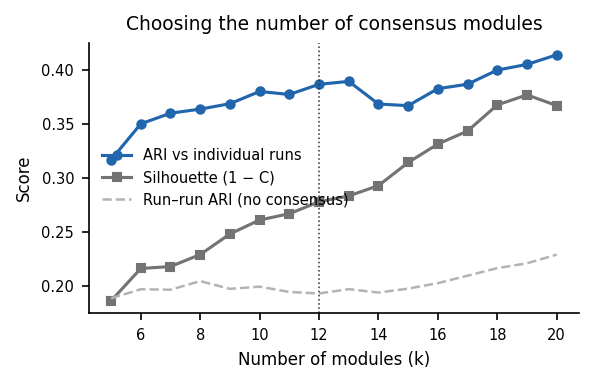

In [4]:
C_run = np.zeros((N_RUNS, P, P))
for i in range(N_RUNS):
    for k in K_RANGE:
        l = per_run_labels[k][i]
        C_run[i] += (l[:, None] == l[None, :])
C_run /= len(K_RANGE)
C = C_run.mean(0)

D_cons = 1.0 - C
np.fill_diagonal(D_cons, 0.0)

sel_rows = []
for k in K_FINAL_RANGE:
    lab = cluster_corr(C, k, LINKAGE_CONS)
    run_ari = [adjusted_rand_score(lab, cluster_corr(R[i], k, LINKAGE_RUN)) for i in range(N_RUNS)]
    sizes = np.bincount(lab)[1:]
    sel_rows.append({'k': k,
                     'ARI_vs_runs': np.mean(run_ari),
                     'run_run_ARI': ari_scan.set_index('k').loc[k, 'pairwise_ARI'],
                     'silhouette_consensus': silhouette_score(D_cons, lab, metric='precomputed'),
                     'n_singletons': int((sizes == 1).sum()),
                     'largest': int(sizes.max())})
sel_df = pd.DataFrame(sel_rows)
# Raw ARI_vs_runs keeps rising with k simply because individual runs also agree more at high k,
# so its maximum sits at the edge of the range. Instead pick the k where the consensus gains
# most over run-to-run agreement.
sel_df['consensus_gain'] = sel_df['ARI_vs_runs'] / sel_df['run_run_ARI']
K_FINAL = int(sel_df.loc[sel_df['consensus_gain'].idxmax(), 'k'])
print(sel_df.round(3).to_string(index=False))
print(f'\nSelected K_FINAL = {K_FINAL}')

fig, ax = plt.subplots(figsize=(4, 2.6))
ax.plot(sel_df['k'], sel_df['ARI_vs_runs'], marker='o', ms=4, lw=1.5, color='#2166ac', label='ARI vs individual runs')
ax.plot(sel_df['k'], sel_df['silhouette_consensus'], marker='s', ms=4, lw=1.5, color='0.45', label='Silhouette (1 − C)')
ax.plot(ari_scan['k'], ari_scan['pairwise_ARI'], ls='--', lw=1.2, color='0.7', label='Run–run ARI (no consensus)')
ax.axvline(K_FINAL, color='0.2', lw=0.75, ls=':')
ax.set_xlabel('Number of modules (k)')
ax.set_ylabel('Score')
ax.legend(frameon=False, loc='best')
ax.set_title('Choosing the number of consensus modules')
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_k_selection.svg', bbox_inches='tight')
plt.show()

In [5]:
def module_labels(source, k=K_FINAL):
    raw = cluster_corr(C, k, LINKAGE_CONS) if source == 'consensus' else cluster_corr(R_mean, k, 'ward')
    # Relabel modules M1..MK by decreasing size
    relab = {old: f'M{n+1}' for n, old in enumerate(pd.Series(raw).value_counts().index)}
    return pd.Series([relab[m] for m in raw], index=genes, name='module')

module_of = module_labels(MODULE_SOURCE)
MODULES = [f'M{n+1}' for n in range(K_FINAL)]
print(f'Module source: {MODULE_SOURCE}   K = {K_FINAL}')

# Per-gene confidence: mean co-assignment with the other members of its module
conf = {}
for g in genes:
    mates = [g2i[h] for h in module_of.index[module_of == module_of[g]] if h != g]
    conf[g] = C[g2i[g], mates].mean() if mates else np.nan

# Reference: Norman et al. perturbation-map groups (same cleaned table S6 groups as norman_figure Panel C)
GENE_GROUPS = {
    'MAP2K':                   ['MAP2K3', 'MAP2K6'],
    'Ig domain containing':    ['IGDCC3', 'PRTG'],
    'Tyrosine phosphatase':    ['PTPN12', 'PTPN9'],
    'MAP4K':                   ['MAP4K3', 'MAP4K5'],
    'Brachyury TF':            ['CSRNP1', 'SET', 'TBX2', 'TBX3'],
    'Kinesin':                 ['KIF18B', 'KIF2C'],
    'bLZ TF':                  ['CEBPA', 'CEBPB', 'CEBPE', 'CELF2', 'FOSB', 'OSR2'],
    'Regulation of apoptosis': ['EGR1', 'FOXO4', 'IER5L', 'IKZF3', 'MEIS1', 'PRDM1',
                                'RHOXF2B', 'SAMD1', 'SGK1', 'TP73'],
    'Homeobox TF':             ['CBFA2T3', 'CITED1', 'DLX2', 'MIDN', 'NIT1', 'SNAI1', 'TMSB4X'],
}
norman_group = pd.Series({g: grp for grp, gs in GENE_GROUPS.items() for g in gs if g in g2i})

module_df = pd.DataFrame({
    'module': module_of,
    'confidence': pd.Series(conf),
    'norman_group': norman_group.reindex(genes),
})
module_df.index.name = 'gene'
module_df.to_csv(OUT_DIR / 'consensus_modules.csv')

_ng = module_df.dropna(subset=['norman_group'])
print(f'ARI(consensus modules, Norman groups) on {len(_ng)} annotated genes: '
      f"{adjusted_rand_score(_ng['module'], _ng['norman_group']):.3f}")
_null = [adjusted_rand_score(np.random.default_rng(s).permutation(_ng['module'].values), _ng['norman_group'])
         for s in range(1000)]
print(f"  permutation p = {(np.sum(np.array(_null) >= adjusted_rand_score(_ng['module'], _ng['norman_group'])) + 1) / 1001:.4f}")

summary = (module_df.reset_index()
           .groupby('module')
           .agg(n=('gene', 'size'),
                mean_confidence=('confidence', 'mean'),
                genes=('gene', lambda s: ', '.join(sorted(s))),
                norman_groups=('norman_group', lambda s: '; '.join(f'{k}×{v}' for k, v in s.value_counts().items())))
           .reindex(MODULES))
pd.set_option('display.max_colwidth', 200)
summary

Module source: consensus   K = 12
ARI(consensus modules, Norman groups) on 36 annotated genes: 0.373


  permutation p = 0.0010


,n,mean_confidence,genes,norman_groups
module,,,,
M1,18,0.412745,"AHR, ARRDC3, ATL1, BPGM, C19orf26, CBL, CLDN6, DUSP9, FOXA1, FOXA3, HOXA13, HOXC13, JUN, LYL1, MAP4K3, MAP4K5, SGK1, ZBTB10",MAP4K×2; Regulation of apoptosis×1
M2,14,0.540385,"CKS1B, CNN1, FOXO4, GLB1L2, HK2, HNF4A, PTPN1, PTPN12, PTPN9, RHOXF2, RREB1, SAMD1, UBASH3B, ZBTB25",Regulation of apoptosis×2; Tyrosine phosphatase×2
M3,13,0.427564,"CBFA2T3, CEBPA, CEBPB, CEBPE, CELF2, COL1A1, COL2A1, FOSB, HES7, HOXB9, ISL2, MIDN, SPI1",bLZ TF×5; Homeobox TF×2
M4,11,0.391818,"KIAA1804, KIF18B, KIF2C, KMT2A, NCL, PLK4, PTPN13, STIL, TP73, TSC22D1, UBASH3A",Kinesin×2; Regulation of apoptosis×1
M5,10,0.433056,"CNNM4, EGR1, FEV, IER5L, IKZF3, LHX1, MEIS1, POU3F2, PRDM1, ZBTB1",Regulation of apoptosis×5
M6,8,0.456696,"CSRNP1, ELMSAN1, KLF1, MAML2, MAP2K3, MAP2K6, TBX2, ZC3HAV1",Brachyury TF×2; MAP2K×2
M7,8,0.346875,"ARID1A, CDKN1A, CDKN1B, CDKN1C, IRF1, S1PR2, SET, ZNF318",Brachyury TF×1
M8,6,0.415000,"BAK1, BCL2L11, ETS2, MAPK1, SLC4A1, TMSB4X",Homeobox TF×1
M9,6,0.490833,"DLX2, FOXF1, FOXL2, RUNX1T1, SNAI1, TBX3",Homeobox TF×2; Brachyury TF×1


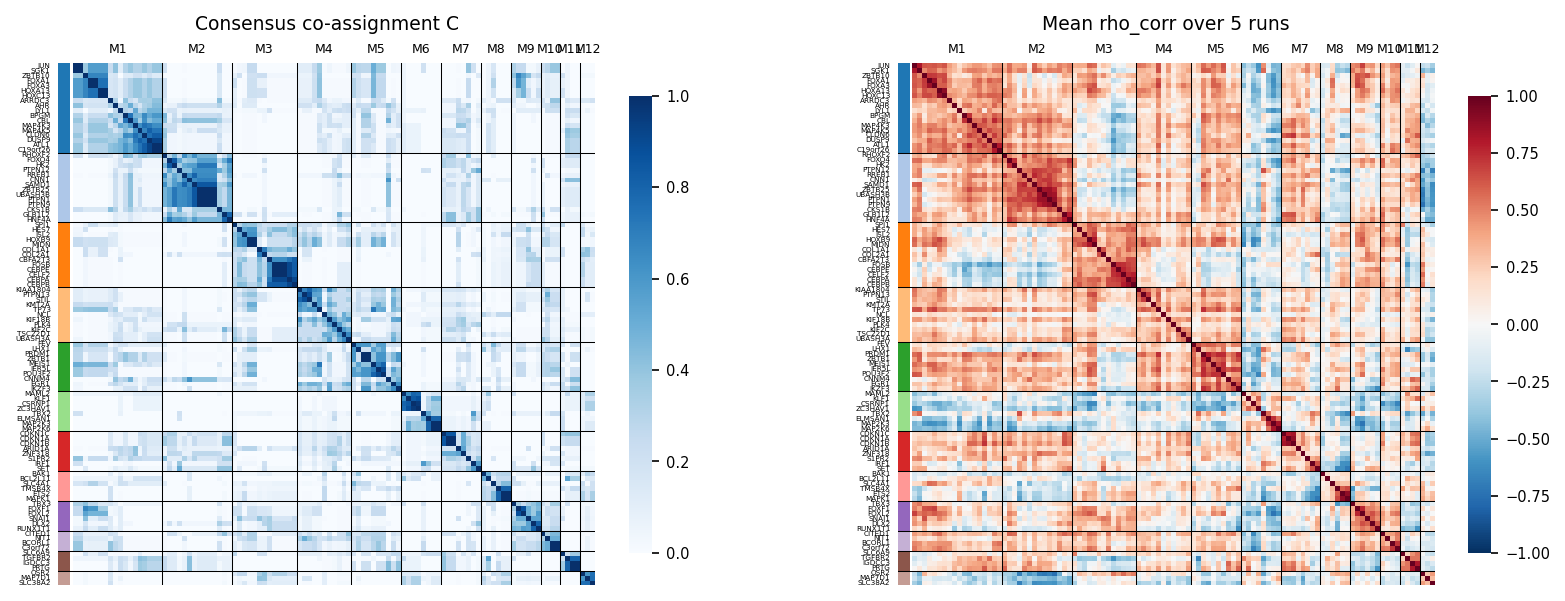

In [6]:
# Consensus matrix ordered by module (then by within-module hierarchical order)
_lk = linkage(squareform(D_cons, checks=False), method=LINKAGE_CONS)
_leaf_rank = {genes[i]: r for r, i in enumerate(leaves_list(_lk))}
order = sorted(genes, key=lambda g: (MODULES.index(module_of[g]), _leaf_rank[g]))
oi = [g2i[g] for g in order]

mod_colors = dict(zip(MODULES, sns.color_palette('tab20', K_FINAL)))
fig, axes = plt.subplots(1, 2, figsize=(13, 6.6), gridspec_kw={'wspace': 0.25})
for ax, M, title, cmap, vmin in [(axes[0], C, 'Consensus co-assignment C', 'Blues', 0),
                                 (axes[1], R_mean, 'Mean rho_corr over 5 runs', 'RdBu_r', -1)]:
    sns.heatmap(M[np.ix_(oi, oi)], ax=ax, cmap=cmap, vmin=vmin, vmax=1, square=True,
                xticklabels=False, yticklabels=order, cbar_kws={'shrink': 0.6})
    ax.tick_params(axis='y', labelsize=3.5, length=0)
    ax.set_title(title, pad=16)
    # module boundaries
    bounds = np.cumsum([sum(module_of == m) for m in MODULES])[:-1]
    for b in bounds:
        ax.axhline(b, color='k', lw=0.5); ax.axvline(b, color='k', lw=0.5)
    # module colour strip
    for n, g in enumerate(order):
        ax.add_patch(plt.Rectangle((-3, n), 2.5, 1, color=mod_colors[module_of[g]], clip_on=False, lw=0))
    ax.set_xlim(-3, P)
    starts = np.r_[0, bounds]
    for m, s, e in zip(MODULES, starts, np.r_[bounds, P]):
        ax.text((s + e) / 2, -1.5, m, ha='center', va='bottom', fontsize=6)
plt.savefig(OUT_DIR / 'consensus_modules_heatmap.svg', bbox_inches='tight')
plt.show()

## 4. Ground-truth interactions: pair-level features

The labels are Norman et al.'s ground-truth interaction classes from `genetic_interactions.csv`,
not SHERLOCK's predicted classes. *Synergy (similar phenotype)* and *synergy (dissimilar phenotype)*
are merged into a single **synergy** class. The held-out split is reproduced on the original
8 classes first, so it matches `norman_figure.ipynb`.

For each GT double perturbation A+B, the table records:

- `rho`: mean ρ(A, B) over runs, and `rho_sd`, its standard deviation across runs
- `coassign`: consensus co-assignment C(A, B)
- `same_module`: whether A and B fall in the same consensus module

In [7]:
def canon_pair(s):
    s = str(s)
    if '+' not in s:
        return s
    a, b = s.split('+', 1)
    return '+'.join(sorted([a.strip(), b.strip()]))

gi_labels = pd.read_csv(f'{paths.DATA_DIR}/norman/genetic_interactions.csv')
gi_labels['combination'] = gi_labels['combination'].apply(canon_pair)
gi_labels['genetic_interaction'] = gi_labels['genetic_interaction'].str.strip()

# Reproduce the held-out test split from norman_figure.ipynb exactly
random.seed(42)
val_combos = set()
for cls, grp in gi_labels.groupby('genetic_interaction'):
    val_combos.update(random.sample(list(grp['combination']), math.ceil(0.2 * len(grp))))

gi_labels['gi'] = gi_labels['genetic_interaction'].replace(MERGE_GI)
print(gi_labels['gi'].value_counts().reindex(GI_ORDER).to_string(), '\n')

rows = []
for comb, cls, cls_raw in zip(gi_labels['combination'], gi_labels['gi'], gi_labels['genetic_interaction']):
    a, b = comb.split('+')
    if a not in g2i or b not in g2i:
        continue
    ia, ib = g2i[a], g2i[b]
    rows.append({'combination': comb, 'a': a, 'b': b, 'gi': cls, 'gi_original': cls_raw,
                 'rho': R_mean[ia, ib], 'rho_sd': R[:, ia, ib].std(),
                 'coassign': C[ia, ib],
                 'module_a': module_of[a], 'module_b': module_of[b],
                 'same_module': module_of[a] == module_of[b],
                 'held_out': comb in val_combos})
pairs_df = pd.DataFrame(rows)
pairs_df.to_csv(OUT_DIR / 'gt_pair_module_features.csv', index=False)

dropped = sorted(set(gi_labels['combination']) - set(pairs_df['combination']))
print(f'GT pairs with both genes in rho_corr: {len(pairs_df)} / {len(gi_labels)}  (dropped: {dropped})')
print(f"Held-out (test) GT pairs: {pairs_df['held_out'].sum()}")

bg = {'rho': R_mean[TRI].mean(), 'coassign': C[TRI].mean(),
      'same_module': (module_of.values[TRI[0]] == module_of.values[TRI[1]]).mean()}
tab = (pairs_df.groupby('gi')
       .agg(n=('rho', 'size'), rho_mean=('rho', 'mean'), rho_median=('rho', 'median'),
            rho_sd_across_runs=('rho_sd', 'mean'), coassign_mean=('coassign', 'mean'),
            frac_same_module=('same_module', 'mean'))
       .reindex(GI_ORDER))
tab.loc['(all 5460 gene pairs)'] = [len(TRI[0]), bg['rho'], np.median(R_mean[TRI]), R.std(0)[TRI].mean(),
                                    bg['coassign'], bg['same_module']]
tab.round(3)

gi
approximately additive    16
epistasis                  9
neomorphic                13
potentiation               6
redundant                  8
suppression               12
synergy                   24 

GT pairs with both genes in rho_corr: 86 / 88  (dropped: ['CBARP+TGFBR2', 'RHOXF2B+SET'])
Held-out (test) GT pairs: 22


,n,rho_mean,rho_median,rho_sd_across_runs,coassign_mean,frac_same_module
gi,,,,,,
approximately additive,15.0,0.546,0.543,0.113,0.393,0.333
epistasis,9.0,-0.001,-0.046,0.152,0.190,0.222
neomorphic,12.0,-0.025,-0.005,0.095,0.056,0.083
potentiation,6.0,0.129,0.145,0.131,0.031,0.000
redundant,8.0,0.758,0.808,0.064,0.862,1.000
suppression,12.0,-0.126,-0.119,0.177,0.045,0.000
synergy,24.0,0.499,0.548,0.128,0.408,0.292
(all 5460 gene pairs),5460.0,0.118,0.135,0.140,0.107,0.096


## 5. Do modules / ρ separate interaction classes?

- **Omnibus test:** Kruskal–Wallis across the 7 classes.
- **Per class, one-vs-rest:** Mann–Whitney U, with AUROC = U / (n₁n₂). AUROC > 0.5 means the class
  has *higher* ρ or co-assignment than the other GT pairs. p-values are BH-adjusted.
- **Same module:** Fisher's exact test of the fraction of same-module pairs in each class against
  all other GT pairs.

In [8]:
def class_tests(df, col):
    out = []
    for cls in GI_ORDER:
        x = df.loc[df['gi'] == cls, col].values
        y = df.loc[df['gi'] != cls, col].values
        if len(x) == 0:
            continue
        u, p = mannwhitneyu(x, y, alternative='two-sided')
        out.append({'gi': cls, 'feature': col, 'n': len(x), 'AUROC': u / (len(x) * len(y)), 'p': p})
    out = pd.DataFrame(out)
    out['q'] = multipletests(out['p'], method='fdr_bh')[1]
    return out

kw = {col: kruskal(*[g[col].values for _, g in pairs_df.groupby('gi')]) for col in ['rho', 'coassign', 'rho_sd']}
for col, res in kw.items():
    print(f'Kruskal–Wallis {col:9s}: H = {res.statistic:6.2f}   p = {res.pvalue:.2e}')

fisher_rows = []
for cls in GI_ORDER:
    in_c = pairs_df['gi'] == cls
    t = [[(pairs_df.loc[in_c, 'same_module']).sum(), (~pairs_df.loc[in_c, 'same_module']).sum()],
         [(pairs_df.loc[~in_c, 'same_module']).sum(), (~pairs_df.loc[~in_c, 'same_module']).sum()]]
    orr, p = fisher_exact(t)
    fisher_rows.append({'gi': cls, 'same_module': t[0][0], 'n': in_c.sum(),
                        'frac_same': t[0][0] / in_c.sum(), 'odds_ratio': orr, 'p': p})
fisher_df = pd.DataFrame(fisher_rows)
fisher_df['q'] = multipletests(fisher_df['p'], method='fdr_bh')[1]

tests = pd.concat([class_tests(pairs_df, 'rho'), class_tests(pairs_df, 'coassign')])
tests_wide = tests.pivot(index='gi', columns='feature', values=['AUROC', 'q']).reindex(GI_ORDER)
tests_wide.columns = [f'{a}_{b}' for a, b in tests_wide.columns]
tests_wide = tests_wide.join(fisher_df.set_index('gi')[['frac_same', 'odds_ratio', 'q']].rename(
    columns={'q': 'q_same_module', 'odds_ratio': 'OR_same_module'}))
tests_wide.to_csv(OUT_DIR / 'gi_class_tests.csv')
tests_wide.round(4)

Kruskal–Wallis rho      : H =  55.71   p = 3.33e-10
Kruskal–Wallis coassign : H =  45.61   p = 3.54e-08
Kruskal–Wallis rho_sd   : H =  11.34   p = 7.84e-02


,AUROC_coassign,AUROC_rho,q_coassign,q_rho,frac_same,OR_same_module,q_same_module
gi,,,,,,,
approximately additive,0.6728,0.7211,0.0411,0.0105,0.3333,1.4722,0.7458
epistasis,0.3153,0.2612,0.0697,0.0232,0.2222,0.7619,1.0000
neomorphic,0.2523,0.2264,0.0136,0.0046,0.0833,0.2149,0.3255
potentiation,0.2125,0.3646,0.0263,0.2819,0.0000,0.0000,0.3255
redundant,0.9359,0.9231,0.0003,0.0001,1.0000,inf,0.0001
suppression,0.2370,0.1182,0.0119,0.0001,0.0000,0.0000,0.1080
synergy,0.6771,0.7103,0.0187,0.0046,0.2917,1.1838,0.9210


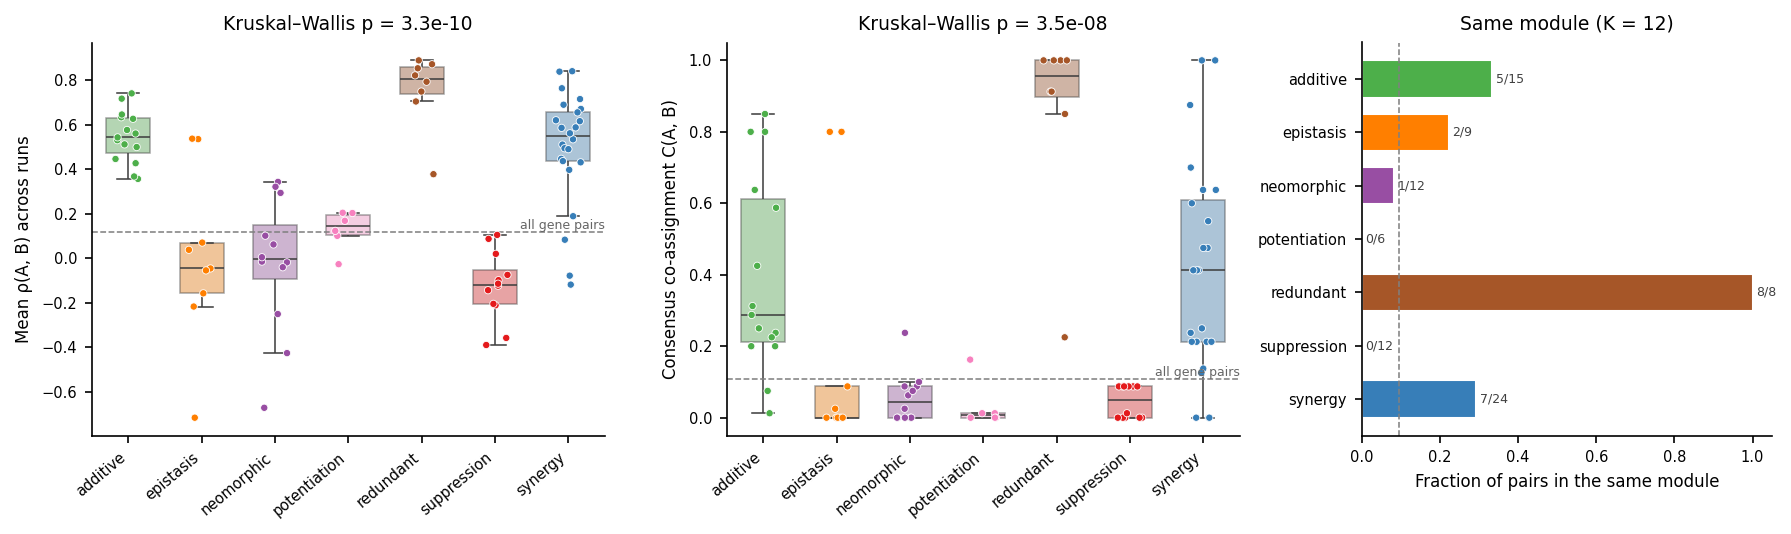

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={'width_ratios': [1, 1, 0.8]})
short = {c: c.replace('approximately additive', 'additive') for c in GI_ORDER}

for ax, col, ylabel, bgval in [(axes[0], 'rho', 'Mean ρ(A, B) across runs', bg['rho']),
                               (axes[1], 'coassign', 'Consensus co-assignment C(A, B)', bg['coassign'])]:
    sns.boxplot(data=pairs_df, x='gi', y=col, order=GI_ORDER, hue='gi', hue_order=GI_ORDER,
                palette=PALETTE_GI, width=0.6, fliersize=0, linewidth=0.75, ax=ax, legend=False,
                boxprops=dict(alpha=0.45))
    sns.stripplot(data=pairs_df, x='gi', y=col, order=GI_ORDER, hue='gi', hue_order=GI_ORDER,
                  palette=PALETTE_GI, size=3.5, jitter=0.18, edgecolor='white', linewidth=0.4,
                  ax=ax, legend=False)
    ax.axhline(bgval, color='0.5', ls='--', lw=0.75)
    ax.text(len(GI_ORDER) - 0.5, bgval, 'all gene pairs', ha='right', va='bottom', fontsize=6, color='0.4')
    ax.set_xticks(range(len(GI_ORDER)))
    ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Kruskal–Wallis p = {kw[col].pvalue:.1e}')

ax = axes[2]
fd = fisher_df.set_index('gi').reindex(GI_ORDER)
ax.barh(range(len(GI_ORDER)), fd['frac_same'], color=[PALETTE_GI[c] for c in GI_ORDER],
        height=0.7, edgecolor='white', linewidth=1)
for n, (f, k, tot) in enumerate(zip(fd['frac_same'], fd['same_module'], fd['n'])):
    ax.text(f + 0.01, n, f'{k}/{tot}', va='center', fontsize=6, color='0.25')
ax.axvline(bg['same_module'], color='0.5', ls='--', lw=0.75)
ax.set_yticks(range(len(GI_ORDER)))
ax.set_yticklabels([short[c] for c in GI_ORDER])
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel('Fraction of pairs in the same module')
ax.set_title(f'Same module (K = {K_FINAL})')
plt.tight_layout()
fig.savefig(OUT_DIR / 'gi_class_vs_modules.svg', bbox_inches='tight')
plt.show()

### 5b. Module-level interaction profiles

Do particular modules tend to take part in particular interaction types? Each GT pair contributes
one count to each module its genes belong to (a within-module pair counts once). Enrichment of a
class within a module's pairs is tested with a hypergeometric test against all GT pairs.

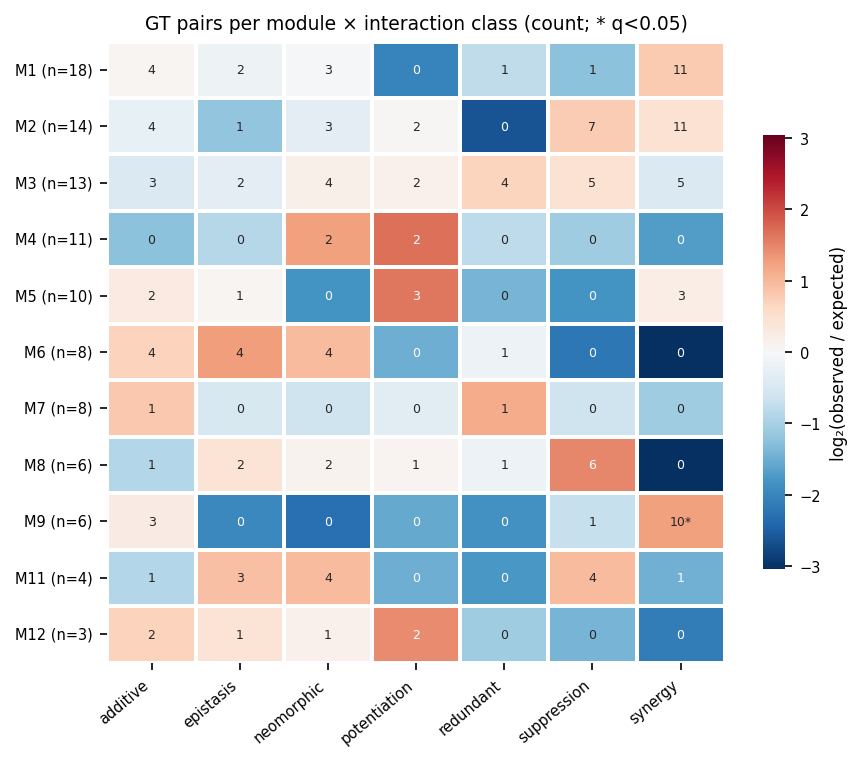

Significant module × class enrichments (q < 0.1):
module          gi  k  n_module_pairs  expected  log2_OE  p_enrich  q_enrich
    M9     synergy 10              14     3.907   1.2525    0.0003    0.0221
    M8 suppression  6              13     1.814   1.4901    0.0021    0.0877


In [10]:
long = []
for _, r in pairs_df.iterrows():
    for m in {r['module_a'], r['module_b']}:
        long.append({'module': m, 'gi': r['gi'], 'combination': r['combination']})
long = pd.DataFrame(long)
counts = pd.crosstab(long['module'], long['gi']).reindex(index=MODULES, columns=GI_ORDER, fill_value=0)

N_tot = len(pairs_df)
cls_tot = pairs_df['gi'].value_counts()
enr = []
for m in MODULES:
    n_m = counts.loc[m].sum()
    for c in GI_ORDER:
        k = counts.loc[m, c]
        exp = n_m * cls_tot.get(c, 0) / N_tot
        p = hypergeom.sf(k - 1, N_tot, cls_tot.get(c, 0), n_m) if n_m else 1.0
        enr.append({'module': m, 'gi': c, 'k': k, 'n_module_pairs': n_m, 'expected': exp,
                    'log2_OE': np.log2((k + 0.5) / (exp + 0.5)), 'p_enrich': p})
enr = pd.DataFrame(enr)
enr['q_enrich'] = multipletests(enr['p_enrich'], method='fdr_bh')[1]
enr.to_csv(OUT_DIR / 'module_gi_enrichment.csv', index=False)

keep_mods = [m for m in MODULES if counts.loc[m].sum() > 0]
L = enr.pivot(index='module', columns='gi', values='log2_OE').reindex(index=keep_mods, columns=GI_ORDER)
Q = enr.pivot(index='module', columns='gi', values='q_enrich').reindex(index=keep_mods, columns=GI_ORDER)
annot = counts.loc[keep_mods].astype(str) + np.where(Q < 0.05, '*', '')

fig, ax = plt.subplots(figsize=(6, 0.32 * len(keep_mods) + 1.6))
lim = np.nanmax(np.abs(L.values))
sns.heatmap(L, cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, annot=annot, fmt='', annot_kws={'fontsize': 6},
            linewidths=1, linecolor='white', cbar_kws={'label': 'log₂(observed / expected)', 'shrink': 0.7}, ax=ax)
ax.set_yticklabels([f"{m} (n={int((module_of == m).sum())})" for m in keep_mods], rotation=0)
ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right')
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('GT pairs per module × interaction class (count; * q<0.05)')
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_gi_enrichment.svg', bbox_inches='tight')
plt.show()

print('Significant module × class enrichments (q < 0.1):')
print(enr[enr['q_enrich'] < 0.1].sort_values('q_enrich').round(4).to_string(index=False))

### 5c. Module × module interaction map

Does the *pair* of modules predict the interaction? For example, M_i × M_j pairs could tend to be
neomorphic, while pairs inside M_i tend to be synergistic, additive or redundant.

Each GT pair A+B is assigned an unordered module pair: `Mi` if both genes are in the same module,
otherwise `Mi×Mj`.

- **Global association:** χ² statistic of the module-pair × class table, compared against
  permutations of the class labels. The χ² value itself is only a test statistic, because most cells
  are sparse. Two nulls are used:
  1. **free:** labels shuffled across all GT pairs;
  2. **stratified:** labels shuffled only within strata of (same module vs. different module) ×
     (ρ quartile). This asks whether the *specific* modules matter beyond "same module / high ρ".
  3. **random gene modules:** class labels fixed, genes reassigned to random modules of the same
     sizes. This respects the fact that GT pairs share genes (e.g. TGFBR2, PTPN12 and CEBPE each
     appear in many pairs), and asks whether the learned modules beat arbitrary gene groupings.
- **Per module pair:** hypergeometric enrichment of each class among that module pair's GT pairs
  (tested for module pairs with ≥ 2 GT pairs), BH-adjusted.

Module-pair × class: chi2 = 348.2 over 36 module pairs
  free permutation p       = 0.0002
  stratified (same-module × rho quartile) p = 0.0002
  gene-shuffled modules (same sizes) p       = 0.0020


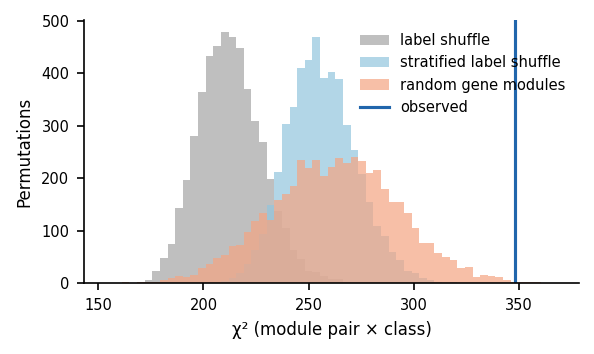

In [11]:
def module_pair_of(df, mod):
    ma = df['a'].map(mod).values
    mb = df['b'].map(mod).values
    return np.array([a if a == b else '×'.join(sorted([a, b], key=lambda m: int(m[1:])))
                     for a, b in zip(ma, mb)])

def _chi2_stat(mp_codes, y_codes, n_mp, n_cls):
    O = np.bincount(mp_codes * n_cls + y_codes, minlength=n_mp * n_cls).reshape(n_mp, n_cls).astype(float)
    E = O.sum(1, keepdims=True) * O.sum(0, keepdims=True) / O.sum()
    m = E > 0
    return ((O[m] - E[m]) ** 2 / E[m]).sum()

def module_pair_association(df, mod, n_perm=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    mp = module_pair_of(df, mod)
    mp_codes = pd.factorize(mp)[0]
    y_codes = pd.Categorical(df['gi'], categories=GI_ORDER).codes
    n_mp, n_cls = mp_codes.max() + 1, len(GI_ORDER)
    obs_stat = _chi2_stat(mp_codes, y_codes, n_mp, n_cls)

    same = df['a'].map(mod).values == df['b'].map(mod).values
    rho_q = pd.qcut(df['rho'], 4, labels=False).values
    strata = [np.where((same == s) & (rho_q == q))[0] for s in (False, True) for q in range(4)]
    strata = [s for s in strata if len(s) > 1]

    null_free, null_strat, null_gene = np.empty(n_perm), np.empty(n_perm), np.empty(n_perm)
    for b in range(n_perm):
        null_free[b] = _chi2_stat(mp_codes, rng.permutation(y_codes), n_mp, n_cls)
        y_s = y_codes.copy()
        for s in strata:
            y_s[s] = y_codes[rng.permutation(s)]
        null_strat[b] = _chi2_stat(mp_codes, y_s, n_mp, n_cls)
        # Gene-level null: random gene groupings with the same module sizes, real labels
        mod_rand = pd.Series(rng.permutation(mod.values), index=mod.index)
        rc = pd.factorize(module_pair_of(df, mod_rand))[0]
        null_gene[b] = _chi2_stat(rc, y_codes, rc.max() + 1, n_cls)
    return {'chi2': obs_stat, 'n_module_pairs': n_mp,
            'p_free': (np.sum(null_free >= obs_stat) + 1) / (n_perm + 1),
            'p_stratified': (np.sum(null_strat >= obs_stat) + 1) / (n_perm + 1),
            'p_gene_shuffle': (np.sum(null_gene >= obs_stat) + 1) / (n_perm + 1),
            'null_free': null_free, 'null_strat': null_strat, 'null_gene': null_gene}

pairs_df['module_pair'] = module_pair_of(pairs_df, module_of)
assoc = module_pair_association(pairs_df, module_of)
print(f"Module-pair × class: chi2 = {assoc['chi2']:.1f} over {assoc['n_module_pairs']} module pairs")
print(f"  free permutation p       = {assoc['p_free']:.4f}")
print(f"  stratified (same-module × rho quartile) p = {assoc['p_stratified']:.4f}")
print(f"  gene-shuffled modules (same sizes) p       = {assoc['p_gene_shuffle']:.4f}")

fig, ax = plt.subplots(figsize=(4, 2.4))
_all = np.r_[assoc['null_free'], assoc['null_strat'], assoc['null_gene'], assoc['chi2']]
bins = np.linspace(_all.min(), _all.max() * 1.02, 60)
ax.hist(assoc['null_free'], bins=bins, color='0.75', label='label shuffle')
ax.hist(assoc['null_strat'], bins=bins, color='#92c5de', alpha=0.7, label='stratified label shuffle')
ax.hist(assoc['null_gene'], bins=bins, color='#f4a582', alpha=0.7, label='random gene modules')
ax.axvline(assoc['chi2'], color='#2166ac', lw=1.5, label='observed')
ax.set_xlabel('χ² (module pair × class)'); ax.set_ylabel('Permutations')
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_pair_permutation.svg', bbox_inches='tight')
plt.show()

In [12]:
# Composition and enrichment per module pair
N_tot = len(pairs_df)
cls_tot = pairs_df['gi'].value_counts()
mp_counts = (pairs_df.groupby(['module_pair', 'gi']).size().unstack(fill_value=0)
             .reindex(columns=GI_ORDER, fill_value=0))
mp_counts['n'] = mp_counts[GI_ORDER].sum(1)

mp_enr = []
for mp_name, row in mp_counts[mp_counts['n'] >= 2].iterrows():
    for c in GI_ORDER:
        if row[c] == 0:
            continue
        mp_enr.append({'module_pair': mp_name, 'within': '×' not in mp_name, 'gi': c,
                       'k': int(row[c]), 'n': int(row['n']),
                       'frac': row[c] / row['n'], 'bg_frac': cls_tot[c] / N_tot,
                       'p': hypergeom.sf(row[c] - 1, N_tot, cls_tot[c], row['n'])})
mp_enr = pd.DataFrame(mp_enr)
mp_enr['q'] = multipletests(mp_enr['p'], method='fdr_bh')[1]
mp_enr = mp_enr.sort_values('p')
mp_enr.to_csv(OUT_DIR / 'module_pair_gi_enrichment.csv', index=False)

def _pairs_text(mp_name, c):
    s = pairs_df[(pairs_df['module_pair'] == mp_name) & (pairs_df['gi'] == c)]['combination']
    return ', '.join(s)

top = mp_enr[mp_enr['p'] < 0.05].copy()
top['pairs'] = [_pairs_text(m, c) for m, c in zip(top['module_pair'], top['gi'])]
print('Module pairs enriched for an interaction class (nominal p < 0.05):')
top.round(4)

Module pairs enriched for an interaction class (nominal p < 0.05):


,module_pair,within,gi,k,n,frac,bg_frac,p,q,pairs
25,M3,True,redundant,4,4,1.0000,0.0930,0.0000,0.0014,"CEBPA+CEBPB, CEBPA+CEBPE, CEBPE+SPI1, CEBPE+FOSB"
20,M2×M3,False,suppression,4,5,0.8000,0.1395,0.0011,0.0226,"CEBPB+PTPN12, CEBPE+CNN1, CEBPE+PTPN12, FOSB+UBASH3B"
40,M8×M11,False,suppression,4,6,0.6667,0.1395,0.0030,0.0416,"ETS2+IGDCC3, ETS2+PRTG, IGDCC3+MAPK1, MAPK1+PRTG"
21,M2×M4,False,potentiation,2,2,1.0000,0.0698,0.0041,0.0431,"CNN1+UBASH3A, PTPN12+UBASH3A"
0,M11,True,epistasis,2,2,1.0000,0.1047,0.0098,0.0769,"IGDCC3+TGFBR2, PRTG+TGFBR2"
27,M3×M5,False,potentiation,2,3,0.6667,0.0698,0.0119,0.0769,"CBFA2T3+FEV, FEV+ISL2"
14,M2,True,synergy,5,7,0.7143,0.2791,0.0166,0.0769,"CNN1+UBASH3B, PTPN12+UBASH3B, PTPN9+UBASH3B, UBASH3B+ZBTB25, PTPN12+ZBTB25"
22,M2×M8,False,suppression,2,2,1.0000,0.1395,0.0181,0.0769,"CNN1+MAPK1, CNN1+ETS2"
30,M3×M6,False,neomorphic,3,5,0.6000,0.1395,0.0181,0.0769,"MAP2K6+SPI1, CEBPE+KLF1, CEBPE+ZC3HAV1"
12,M1×M9,False,synergy,4,5,0.8000,0.2791,0.0201,0.0769,"FOXA3+FOXL2, DUSP9+SNAI1, FOXA1+FOXF1, FOXA1+FOXL2"


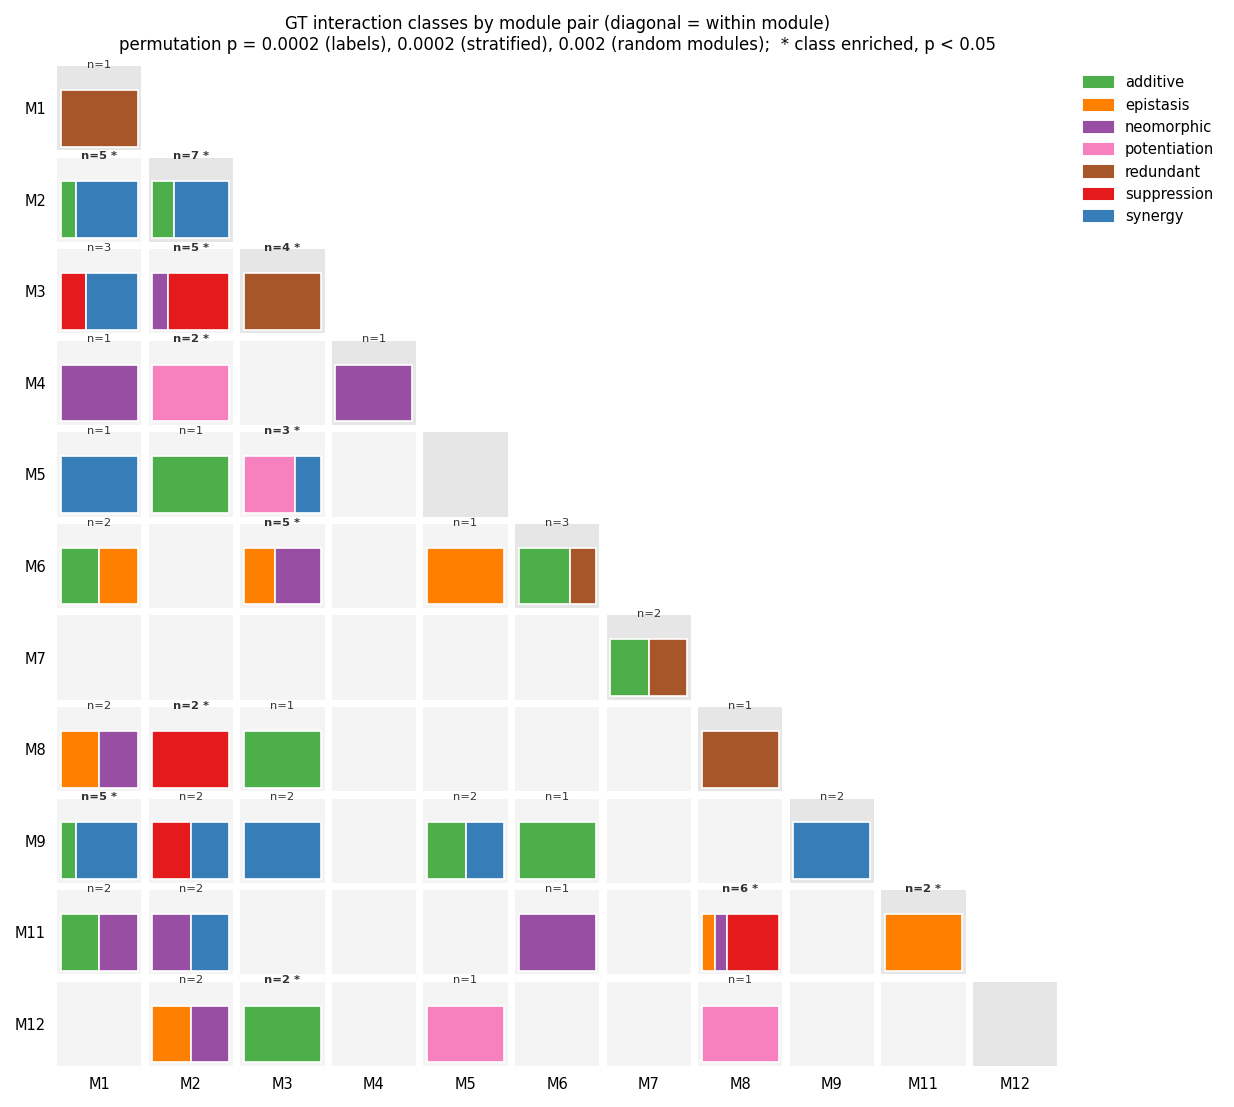

In [13]:
# Module × module map: each cell is a stacked bar of GT interaction classes for that module pair
mods_used = [m for m in MODULES if (pairs_df['module_a'].eq(m) | pairs_df['module_b'].eq(m)).any()]
nM = len(mods_used)
sig_cells = set(mp_enr.loc[mp_enr['p'] < 0.05, 'module_pair'])

fig, ax = plt.subplots(figsize=(0.62 * nM + 2.2, 0.62 * nM + 0.6))
for i, mi in enumerate(mods_used):
    for j, mj in enumerate(mods_used):
        if j > i:
            continue
        name = mi if i == j else '×'.join(sorted([mi, mj], key=lambda m: int(m[1:])))
        x0, y0 = j, i
        ax.add_patch(plt.Rectangle((x0 + 0.04, y0 + 0.04), 0.92, 0.92, fc='#f4f4f4' if i != j else '#e6e6e6',
                                   ec='none'))
        if name not in mp_counts.index:
            continue
        row = mp_counts.loc[name]
        left = x0 + 0.08
        width_tot = 0.84
        for c in GI_ORDER:
            if row[c] == 0:
                continue
            w = width_tot * row[c] / row['n']
            ax.add_patch(plt.Rectangle((left, y0 + 0.30), w, 0.62, fc=PALETTE_GI[c], ec='white', lw=0.8))
            left += w
        ax.text(x0 + 0.5, y0 + 0.08, f"n={int(row['n'])}" + (' *' if name in sig_cells else ''),
                ha='center', va='bottom', fontsize=5.5, color='0.2',
                fontweight='bold' if name in sig_cells else 'normal')
ax.set_xlim(0, nM); ax.set_ylim(nM, 0)
ax.set_xticks(np.arange(nM) + 0.5); ax.set_xticklabels(mods_used)
ax.set_yticks(np.arange(nM) + 0.5); ax.set_yticklabels(mods_used)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_aspect('equal')
ax.legend(handles=[mpl.patches.Patch(color=PALETTE_GI[c], label=short[c]) for c in GI_ORDER],
          frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title(f"GT interaction classes by module pair (diagonal = within module)\n"
             f"permutation p = {assoc['p_free']:.3g} (labels), {assoc['p_stratified']:.3g} (stratified), "
             f"{assoc['p_gene_shuffle']:.3g} (random modules);  "
             f"* class enriched, p < 0.05", fontsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_pair_gi_map.svg', bbox_inches='tight')
plt.show()

In [14]:
# Readable profile: every module pair with >= 2 GT pairs, its class mix, and the pairs themselves
def _mix(row):
    return ', '.join(f'{short[c]} {int(row[c])}' for c in GI_ORDER if row[c] > 0)

profile = mp_counts[mp_counts['n'] >= 2].copy()
profile['within'] = ['×' not in m for m in profile.index]
profile['class_mix'] = profile.apply(_mix, axis=1)
profile['mean_rho'] = pairs_df.groupby('module_pair')['rho'].mean().reindex(profile.index)
profile['pairs'] = [', '.join(f"{c} ({short[g]})" for c, g in
                              pairs_df.loc[pairs_df['module_pair'] == m, ['combination', 'gi']].values)
                    for m in profile.index]
profile = profile.sort_values(['within', 'n'], ascending=[False, False])
profile.to_csv(OUT_DIR / 'module_pair_profiles.csv')
profile[['within', 'n', 'mean_rho', 'class_mix', 'pairs']].round(3)

gi,within,n,mean_rho,class_mix,pairs
module_pair,,,,,
M2,True,7,0.729,"additive 2, synergy 5","PTPN12+SAMD1 (additive), SAMD1+UBASH3B (additive), CNN1+UBASH3B (synergy), PTPN12+UBASH3B (synergy), PTPN9+UBASH3B (synergy), UBASH3B+ZBTB25 (synergy), PTPN12+ZBTB25 (synergy)"
M3,True,4,0.676,redundant 4,"CEBPA+CEBPB (redundant), CEBPA+CEBPE (redundant), CEBPE+SPI1 (redundant), CEBPE+FOSB (redundant)"
M6,True,3,0.702,"additive 2, redundant 1","ELMSAN1+MAP2K3 (additive), ELMSAN1+MAP2K6 (additive), MAP2K3+MAP2K6 (redundant)"
M11,True,2,0.536,epistasis 2,"IGDCC3+TGFBR2 (epistasis), PRTG+TGFBR2 (epistasis)"
M7,True,2,0.714,"additive 1, redundant 1","IRF1+SET (additive), CDKN1A+CDKN1C (redundant)"
M9,True,2,0.675,synergy 2,"FOXF1+FOXL2 (synergy), DLX2+SNAI1 (synergy)"
M8×M11,False,6,0.005,"epistasis 1, neomorphic 1, suppression 4","ETS2+TGFBR2 (neomorphic), MAPK1+TGFBR2 (epistasis), ETS2+IGDCC3 (suppression), ETS2+PRTG (suppression), IGDCC3+MAPK1 (suppression), MAPK1+PRTG (suppression)"
M1×M2,False,5,0.474,"additive 1, synergy 4","BPGM+SAMD1 (additive), CBL+CNN1 (synergy), CBL+PTPN12 (synergy), CBL+PTPN9 (synergy), CBL+UBASH3B (synergy)"
M1×M9,False,5,0.480,"additive 1, synergy 4","SNAI1+ZBTB10 (additive), FOXA3+FOXL2 (synergy), DUSP9+SNAI1 (synergy), FOXA1+FOXF1 (synergy), FOXA1+FOXL2 (synergy)"


### 5d. Module definition: consensus co-assignment vs. expected ρ

Pair-level results above already use the expected ρ (the mean over runs). This section tests whether
modules should instead come from clustering the expected ρ directly (Ward, same K), rather than from
the consensus co-assignment matrix. The comparison covers agreement with individual runs and the
strength of the module-pair ↔ interaction association.

In [15]:
cmp_rows = {}
for src in ['consensus', 'mean_rho']:
    mod = module_labels(src)
    raw = mod.map(lambda m: int(m[1:])).values
    run_ari = np.mean([adjusted_rand_score(raw, cluster_corr(R[i], K_FINAL, LINKAGE_RUN)) for i in range(N_RUNS)])
    a = module_pair_association(pairs_df, mod, n_perm=2000, seed=1)
    same = pairs_df['a'].map(mod).values == pairs_df['b'].map(mod).values
    _ng2 = norman_group.dropna()
    cmp_rows[src] = {
        'ARI_vs_individual_runs': run_ari,
        'ARI_vs_Norman_groups': adjusted_rand_score(mod[_ng2.index], _ng2),
        'module_sizes': ' '.join(map(str, mod.value_counts().values)),
        'GT_same_module_frac': same.mean(),
        'redundant_same_module': f"{same[pairs_df['gi'] == 'redundant'].sum()}/{(pairs_df['gi'] == 'redundant').sum()}",
        'module_pair_chi2': a['chi2'],
        'p_free': a['p_free'],
        'p_stratified': a['p_stratified'],
        'p_gene_shuffle': a['p_gene_shuffle'],
    }
print(f"ARI between the two module definitions: "
      f"{adjusted_rand_score(module_labels('consensus'), module_labels('mean_rho')):.3f}")
pd.DataFrame(cmp_rows)

ARI between the two module definitions: 0.339


,consensus,mean_rho
ARI_vs_individual_runs,0.386874,0.269991
ARI_vs_Norman_groups,0.372818,0.448645
module_sizes,18 14 13 11 10 8 8 6 6 4 4 3,19 14 11 11 10 10 6 6 5 5 5 3
GT_same_module_frac,0.267442,0.267442
redundant_same_module,8/8,7/8
module_pair_chi2,348.193069,352.580093
p_free,0.0005,0.0005
p_stratified,0.0005,0.0005
p_gene_shuffle,0.002999,0.002999


## 6. Robustness

**(a) Per run.** Is the ρ ↔ interaction relationship present in every individual run, or only in
the average?

**(b) Held-out combos only.** The combos in `val_combos` were never seen in training, so their ρ
cannot have been shaped by the double-perturbation cells themselves.

**(c) Observed-effect control.** Norman's classes are partly defined by how similar the two single
phenotypes are (e.g. *redundant*, *synergy (similar phenotype)*). The test here is whether model
ρ carries information beyond the correlation of the observed single-perturbation expression effects.

In [16]:
per_run = []
for i in range(N_RUNS):
    tmp = pairs_df[['combination', 'gi', 'a', 'b']].copy()
    tmp['rho'] = [R[i, g2i[a], g2i[b]] for a, b in zip(tmp['a'], tmp['b'])]
    tmp['coassign'] = [C_run[i, g2i[a], g2i[b]] for a, b in zip(tmp['a'], tmp['b'])]
    row = {'run': i + 1,
           'KW_p_rho': kruskal(*[g['rho'].values for _, g in tmp.groupby('gi')]).pvalue,
           'KW_p_coassign': kruskal(*[g['coassign'].values for _, g in tmp.groupby('gi')]).pvalue}
    for _, t in class_tests(tmp, 'rho').iterrows():
        row[f"AUROC_rho | {short[t['gi']]}"] = t['AUROC']
    per_run.append(row)
per_run_df = pd.DataFrame(per_run).set_index('run')
per_run_df.to_csv(OUT_DIR / 'per_run_gi_tests.csv')
per_run_df.T.round(4)

run,1,2,3,4,5
KW_p_rho,0.0000,0.0000,0.0000,0.0000,0.0000
KW_p_coassign,0.0001,0.0000,0.0000,0.0085,0.0000
AUROC_rho | additive,0.6977,0.6883,0.7070,0.7296,0.7117
AUROC_rho | epistasis,0.2785,0.2237,0.3059,0.2915,0.3304
AUROC_rho | neomorphic,0.2387,0.2658,0.2297,0.2106,0.2207
AUROC_rho | potentiation,0.3375,0.4104,0.2542,0.3583,0.3333
AUROC_rho | redundant,0.9311,0.9295,0.8782,0.8590,0.8942
AUROC_rho | suppression,0.1712,0.0833,0.1565,0.1340,0.1779
AUROC_rho | synergy,0.6855,0.7312,0.7292,0.7191,0.6747


In [17]:
held = pairs_df[pairs_df['held_out']]
print(f'Held-out GT pairs: n = {len(held)}')
print(f"  Kruskal–Wallis rho:      p = {kruskal(*[g['rho'].values for _, g in held.groupby('gi')]).pvalue:.2e}")
print(f"  Kruskal–Wallis coassign: p = {kruskal(*[g['coassign'].values for _, g in held.groupby('gi')]).pvalue:.2e}")
_cm = pairs_df.groupby(['held_out', 'gi'])['rho'].mean().unstack(0).reindex(GI_ORDER)
print(f"  Class-mean rho, train vs held-out pairs: Spearman r = {spearmanr(_cm[False], _cm[True])[0]:.3f}")
print(_cm.rename(columns={False: 'train pairs', True: 'held-out pairs'}).round(3).to_string())
held[['combination', 'gi', 'rho', 'coassign', 'same_module', 'module_a', 'module_b']] \
    .sort_values(['gi', 'rho']).round(3)

Held-out GT pairs: n = 22
  Kruskal–Wallis rho:      p = 4.51e-02
  Kruskal–Wallis coassign: p = 1.09e-01
  Class-mean rho, train vs held-out pairs: Spearman r = 0.857
held_out                train pairs  held-out pairs
gi                                                 
approximately additive        0.565           0.493
epistasis                    -0.048           0.160
neomorphic                    0.056          -0.269
potentiation                  0.111           0.164
redundant                     0.811           0.600
suppression                  -0.102          -0.199
synergy                       0.493           0.515


,combination,gi,rho,coassign,same_module,module_a,module_b
30,DUSP9+PRTG,approximately additive,0.367,0.288,False,M1,M11
27,BPGM+SAMD1,approximately additive,0.446,0.238,False,M1,M2
31,FOSB+OSR2,approximately additive,0.531,0.312,False,M3,M12
37,SAMD1+UBASH3B,approximately additive,0.627,0.850,True,M2,M2
20,CEBPA+ZC3HAV1,epistasis,-0.217,0.000,False,M3,M6
15,PRTG+TGFBR2,epistasis,0.537,0.800,True,M11,M11
10,OSR2+PTPN12,neomorphic,-0.673,0.000,False,M12,M2
2,MAP2K6+SPI1,neomorphic,-0.427,0.025,False,M6,M3
1,KLF1+TGFBR2,neomorphic,0.294,0.062,False,M6,M11
25,FEV+MAP7D1,potentiation,0.123,0.000,False,M5,M12


In [18]:
# Observed single-perturbation effects (same preprocessing as norman_figure.ipynb)
import scanpy as sc
import sherlock as slk

data = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(data, pert_key='perturbation_name', ntc_label='control',
                        treatment_key=None, inplace=True)
_mean_expr = np.asarray(data.X.mean(axis=0)).ravel()
data = data[:, (_mean_expr > 0.5) | data.var_names.isin(genes)].copy()
slk.pp.treat_effect(data, label_col='pert', control_label='NTC', method='perturbseq',
                    inplace=True, key='treat_effect')
te = data.uns['treat_effect'].to_df()

# Exclude the 105 CRISPRa target genes so a target's own induction does not drive the correlation
readout = [g for g in te.columns if g not in g2i]
E = te.loc[genes, readout].values
O = np.corrcoef(E)
print(f'Observed single-effect correlation over {len(readout)} readout genes')
print(f'Spearman(model rho, observed corr) over all gene pairs: {spearmanr(R_mean[TRI], O[TRI])[0]:.3f}')
del data

  0%|          | 0/236 [00:00<?, ?it/s]

  2%|▏         | 4/236 [00:00<00:06, 34.80it/s]

  4%|▍         | 9/236 [00:00<00:05, 41.75it/s]

  6%|▌         | 14/236 [00:00<00:05, 38.56it/s]

  8%|▊         | 20/236 [00:00<00:05, 42.59it/s]

...

 92%|█████████▏| 216/236 [00:04<00:00, 60.24it/s]

 94%|█████████▍| 223/236 [00:04<00:00, 62.37it/s]

 98%|█████████▊| 231/236 [00:04<00:00, 65.58it/s]

100%|██████████| 236/236 [00:04<00:00, 49.45it/s]

Observed single-effect correlation over 3168 readout genes
Spearman(model rho, observed corr) over all gene pairs: 0.790


In [19]:
import statsmodels.api as sm

pairs_df['obs_corr'] = [O[g2i[a], g2i[b]] for a, b in zip(pairs_df['a'], pairs_df['b'])]

# Residual of model rho after a linear fit on observed correlation (fit over ALL gene pairs,
# so the GT labels play no part in the fit)
fit = sm.OLS(R_mean[TRI], sm.add_constant(O[TRI])).fit()
pairs_df['rho_resid'] = pairs_df['rho'] - fit.predict(sm.add_constant(pairs_df['obs_corr'].values, has_constant='add'))
print(f'rho ~ obs_corr over all pairs: R² = {fit.rsquared:.3f}')

for col in ['obs_corr', 'rho', 'rho_resid', 'coassign']:
    print(f"Kruskal–Wallis {col:9s}: p = {kruskal(*[g[col].values for _, g in pairs_df.groupby('gi')]).pvalue:.2e}")

cmp_df = pd.concat([class_tests(pairs_df, c) for c in ['obs_corr', 'rho', 'rho_resid']]) \
    .pivot(index='gi', columns='feature', values='AUROC').reindex(GI_ORDER)[['obs_corr', 'rho', 'rho_resid']]
cmp_df.columns = ['AUROC observed corr', 'AUROC model rho', 'AUROC rho residual']

# Likelihood-ratio test: does adding model rho to observed corr improve a multinomial model of GI class?
y = pd.Categorical(pairs_df['gi'], categories=GI_ORDER).codes
X0 = sm.add_constant(pairs_df[['obs_corr']].values)
X1 = sm.add_constant(pairs_df[['obs_corr', 'rho']].values)
m0 = sm.MNLogit(y, X0).fit(disp=0, maxiter=500)
m1 = sm.MNLogit(y, X1).fit(disp=0, maxiter=500)
lr = 2 * (m1.llf - m0.llf)
from scipy.stats import chi2
print(f'\nMultinomial LRT (obs_corr + rho vs obs_corr): LR = {lr:.2f}, '
      f'df = {len(GI_ORDER) - 1}, p = {chi2.sf(lr, len(GI_ORDER) - 1):.3g}')
cmp_df.to_csv(OUT_DIR / 'gi_auroc_observed_vs_model.csv')
cmp_df.round(3)

rho ~ obs_corr over all pairs: R² = 0.604
Kruskal–Wallis obs_corr : p = 6.46e-12
Kruskal–Wallis rho      : p = 3.33e-10
Kruskal–Wallis rho_resid: p = 8.79e-03
Kruskal–Wallis coassign : p = 3.54e-08



Multinomial LRT (obs_corr + rho vs obs_corr): LR = 11.63, df = 6, p = 0.0708


,AUROC observed corr,AUROC model rho,AUROC rho residual
gi,,,
approximately additive,0.608,0.721,0.700
epistasis,0.154,0.261,0.577
neomorphic,0.211,0.226,0.398
potentiation,0.335,0.365,0.342
redundant,0.981,0.923,0.720
suppression,0.180,0.118,0.277
synergy,0.798,0.710,0.474


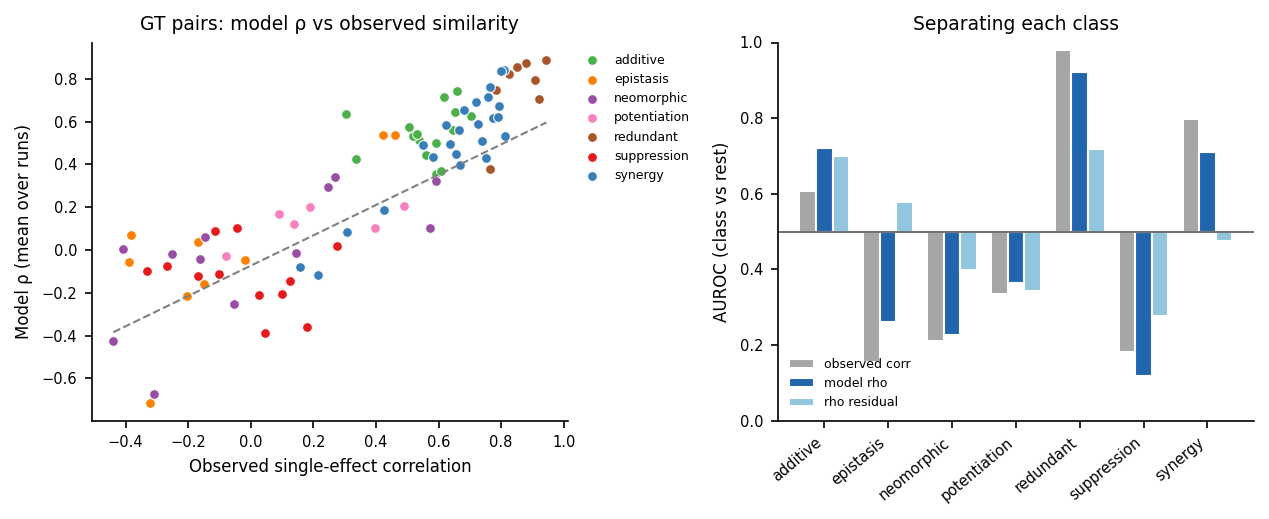

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5))
ax = axes[0]
for c in GI_ORDER:
    s = pairs_df[pairs_df['gi'] == c]
    ax.scatter(s['obs_corr'], s['rho'], s=22, color=PALETTE_GI[c], edgecolor='white', linewidth=0.5, label=short[c])
xs = np.linspace(pairs_df['obs_corr'].min(), pairs_df['obs_corr'].max(), 50)
ax.plot(xs, fit.params[0] + fit.params[1] * xs, color='0.5', lw=1, ls='--')
ax.set_xlabel('Observed single-effect correlation')
ax.set_ylabel('Model ρ (mean over runs)')
ax.set_title('GT pairs: model ρ vs observed similarity')
ax.legend(frameon=False, fontsize=6, bbox_to_anchor=(1.0, 1.0), loc='upper left')

ax = axes[1]
x = np.arange(len(GI_ORDER)); w = 0.26
for n, (col, clr) in enumerate(zip(cmp_df.columns, ['0.65', '#2166ac', '#92c5de'])):
    ax.bar(x + (n - 1) * w, cmp_df[col] - 0.5, width=w, bottom=0.5, color=clr, label=col.replace('AUROC ', ''),
           edgecolor='white', linewidth=1)
ax.axhline(0.5, color='0.3', lw=0.75)
ax.set_xticks(x); ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('AUROC (class vs rest)')
ax.legend(frameon=False, fontsize=6, loc='lower left')
ax.set_title('Separating each class')
plt.tight_layout()
fig.savefig(OUT_DIR / 'gi_observed_vs_model_rho.svg', bbox_inches='tight')
plt.show()

# Part II — Can the modules themselves indicate interaction type? (label-free)

Everything in this part is computed **without the interaction labels and without `get_gi`**.
Modules are described only by what the 5 trained models learned about their member perturbations:

| Source | Quantity | Notes |
|---|---|---|
| Decoder | **D** (P × G): signed counterfactual effect of each single perturbation, i.e. mean log-expression change when its shift is applied to NTC backgrounds | gene-aligned, so it can be averaged across runs |
| Decoder | **EV** (P × G) = D² / Var(NTC), the model's explained-variance matrix | same definition as `_counterfactual_effect_size` |
| Latent | **S** = A ⊙ W, the latent shift; **W**, the gate | latent axes are not aligned across runs, so only rotation- and permutation-invariant pair quantities are used |
| Combination head | parent scales c_a, c_b and synergy vector syn(ρ_a, ρ_b) | can be evaluated for *any* gene pair, including combos never measured |

For every gene pair (a, b), run-invariant descriptors are computed per run and averaged:

- **concordance** = cos(D_a, D_b): do the two perturbations push genes the same way?
- **target_overlap** = cos(EV_a, EV_b): do they act on the same genes, regardless of direction?
- **sign_conflict**: the share of jointly-affected variance, Σ min(EV_a, EV_b), where the two push in opposite directions
- **latent_cos** = cos(S_a, S_b); **gate_jaccard**: overlap of active latent gates
- **mag_asym** = |log‖D_a‖ − log‖D_b‖| (one parent dominates); **mag_mean**: overall strength
- **c_mean**, **c_diff**: mean and asymmetry of the combination head's parent scales
- **syn_rel_norm** = ‖syn‖ / ‖S_a + S_b‖; **syn_cos_add** = cos(syn, S_a + S_b), i.e. whether the
  synergy term amplifies (+), opposes (−) or is orthogonal (≈ 0) to the additive shift

**Module-pair descriptors** average these over all gene pairs between (or within) two modules,
*excluding the 131 combos measured in the experiment*. They therefore reflect only pairs the model
never saw as double perturbations. Ground-truth classes are overlaid only after grouping.

In [21]:
# ── Extract per-run model quantities (cached) ────────────────────────────
FEAT_DIR = OUT_DIR / 'model_features'
FEAT_DIR.mkdir(parents=True, exist_ok=True)
N_NTC_BG = 1024
MODEL_DIR = FIG_DIR / 'models'

if not all((FEAT_DIR / f'run_{k}.npz').exists() for k in range(1, N_RUNS + 1)):
    import torch
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    _d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
    _d.X = _d.layers['counts'].copy()
    slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
    _lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
    _ntc = slk.configs.get_config('ntc_label')
    _keep = (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))   # norman_figure gene filter
    _d = _d[:, _keep].copy()
    _idx = np.random.default_rng(0).choice(np.where(_lab == _ntc)[0], N_NTC_BG, replace=False)
    x_ntc = torch.tensor(_d.X[_idx].toarray(), dtype=torch.float32, device=DEVICE)
    iu = np.triu_indices(P, 1)
    for run in range(1, N_RUNS + 1):
        m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
        assert m.perturbs == P
        with torch.no_grad():
            shifts = m._get_all_pert_shifts(DEVICE)[1:]          # (P, 4, d): A*W, W, q_rho, 0
            S_, W_, q_ = shifts[:, 0], shifts[:, 1], shifts[:, 2]
            u = m._abduct_ntc(x_ntc)
            mu0 = torch.log1p(m._decode_to_expr(u, 1.0) * 1e4)
            var_total = torch.log1p(x_ntc / x_ntc.sum(1, keepdim=True) * 1e4).var(0)
            D_ = torch.zeros(P, x_ntc.shape[1], device=DEVICE)
            for i in range(P):
                D_[i] = (torch.log1p(m._decode_to_expr(u + S_[i], 1.0) * 1e4) - mu0).mean(0)
            EV_ = D_.pow(2) / (var_total + 1e-8)
            ia = torch.tensor(iu[0], device=DEVICE); ib = torch.tensor(iu[1], device=DEVICE)
            c_a, c_b = m._parent_scales_from_rho(q_[ia], q_[ib])
            syn = m._synergy_shift_from_rho(q_[ia], q_[ib])
            add = S_[ia] + S_[ib]
            _cos = lambda x, y: (x * y).sum(1) / (x.norm(dim=1) * y.norm(dim=1) + 1e-8)
            head = {k: v.cpu().numpy() for k, v in dict(
                c_a=c_a.squeeze(-1), c_b=c_b.squeeze(-1),
                syn_rel_norm=syn.norm(dim=1) / (add.norm(dim=1) + 1e-8),
                syn_cos_add=_cos(syn, add)).items()}
        np.savez_compressed(FEAT_DIR / f'run_{run}.npz', genes=np.array(genes), var_names=np.array(_d.var_names),
                            S=S_.cpu().numpy(), W=W_.cpu().numpy(), D=D_.cpu().numpy(), EV=EV_.cpu().numpy(),
                            pair_i=iu[0], pair_j=iu[1], **head)
        del m
    del _d

feat_runs = [np.load(FEAT_DIR / f'run_{k}.npz', allow_pickle=True) for k in range(1, N_RUNS + 1)]
assert list(feat_runs[0]['genes']) == genes
var_names = np.array(feat_runs[0]['var_names'])
D_runs  = np.stack([r['D'] for r in feat_runs])      # (runs, P, G)
EV_runs = np.stack([r['EV'] for r in feat_runs])
IU = (feat_runs[0]['pair_i'], feat_runs[0]['pair_j'])
_prof_r = np.mean([np.mean([np.corrcoef(D_runs[i, p], D_runs[j, p])[0, 1] for p in range(P)]) for i, j in pairs])
print(f'D: {D_runs.shape}   mean cross-run correlation of a perturbation\'s effect profile = {_prof_r:.3f}')

D: (5, 105, 3270)   mean cross-run correlation of a perturbation's effect profile = 0.913


In [22]:
# ── Run-invariant gene-pair descriptors ─────────────────────────────────
def _cos_mat(X):
    n = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return n @ n.T

def _sign_conflict(D, EV):
    out = np.empty(len(IU[0]))
    sg = np.sign(D)
    for s in range(0, len(IU[0]), 500):
        a, b = IU[0][s:s + 500], IU[1][s:s + 500]
        mn = np.minimum(EV[a], EV[b])
        out[s:s + 500] = (mn * (sg[a] != sg[b])).sum(1) / (mn.sum(1) + 1e-12)
    return out

def _jaccard(W, thr=0.5):
    B = (W > thr).astype(float)
    inter = B @ B.T
    s = B.sum(1)
    return inter / (s[:, None] + s[None] - inter + 1e-8)

lognorm_D = np.log(np.linalg.norm(D_runs, axis=2) + 1e-8)   # (runs, P)
per_run_feat = {
    'concordance':    [_cos_mat(D_runs[k])[IU] for k in range(N_RUNS)],
    'target_overlap': [_cos_mat(EV_runs[k])[IU] for k in range(N_RUNS)],
    'sign_conflict':  [_sign_conflict(D_runs[k], EV_runs[k]) for k in range(N_RUNS)],
    'latent_cos':     [_cos_mat(r['S'])[IU] for r in feat_runs],
    'gate_jaccard':   [_jaccard(r['W'])[IU] for r in feat_runs],
    'mag_asym':       [np.abs(lognorm_D[k, IU[0]] - lognorm_D[k, IU[1]]) for k in range(N_RUNS)],
    'mag_mean':       [(lognorm_D[k, IU[0]] + lognorm_D[k, IU[1]]) / 2 for k in range(N_RUNS)],
    'c_mean':         [(r['c_a'] + r['c_b']) / 2 for r in feat_runs],
    'c_diff':         [np.abs(r['c_a'] - r['c_b']) for r in feat_runs],
    'syn_rel_norm':   [r['syn_rel_norm'] for r in feat_runs],
    'syn_cos_add':    [r['syn_cos_add'] for r in feat_runs],
}
DESC = list(per_run_feat)
stability = pd.Series({f: np.mean([spearmanr(v[i], v[j])[0] for i, j in pairs]) for f, v in per_run_feat.items()},
                      name='cross-run Spearman')

gp = pd.DataFrame({f: np.mean(v, 0) for f, v in per_run_feat.items()})
gp['a'] = [genes[i] for i in IU[0]]
gp['b'] = [genes[j] for j in IU[1]]
gp['combination'] = [canon_pair(f'{a}+{b}') for a, b in zip(gp['a'], gp['b'])]
_measured = {canon_pair(l) for l in labels if '+' in l}
gp['measured_combo'] = gp['combination'].isin(_measured)
gp['module_pair'] = module_pair_of(gp, module_of)

# Descriptors used for label-free grouping: reproducible across runs (Spearman >= 0.5), and
# latent_cos dropped because it largely duplicates concordance (it is still shown in tables).
CLUSTER_DESC = [f for f in DESC if stability[f] >= 0.5 and f != 'latent_cos']
print(f"{len(gp)} gene pairs; {gp['measured_combo'].sum()} are measured combos (excluded from module-pair averages)")
print('Descriptors used for grouping:', CLUSTER_DESC)
pd.DataFrame({'cross-run Spearman': stability,
              'corr with concordance': gp[DESC].corr(method='spearman')['concordance']}).round(2)

5460 gene pairs; 131 are measured combos (excluded from module-pair averages)
Descriptors used for grouping: ['concordance', 'sign_conflict', 'mag_asym', 'mag_mean', 'c_mean', 'c_diff', 'syn_rel_norm', 'syn_cos_add']


,cross-run Spearman,corr with concordance
concordance,0.90,1.00
target_overlap,0.32,0.25
sign_conflict,0.80,-0.83
latent_cos,0.84,0.86
gate_jaccard,0.38,0.25
mag_asym,0.91,-0.12
mag_mean,0.97,0.27
c_mean,0.76,0.02
c_diff,0.56,-0.14
syn_rel_norm,0.73,-0.26


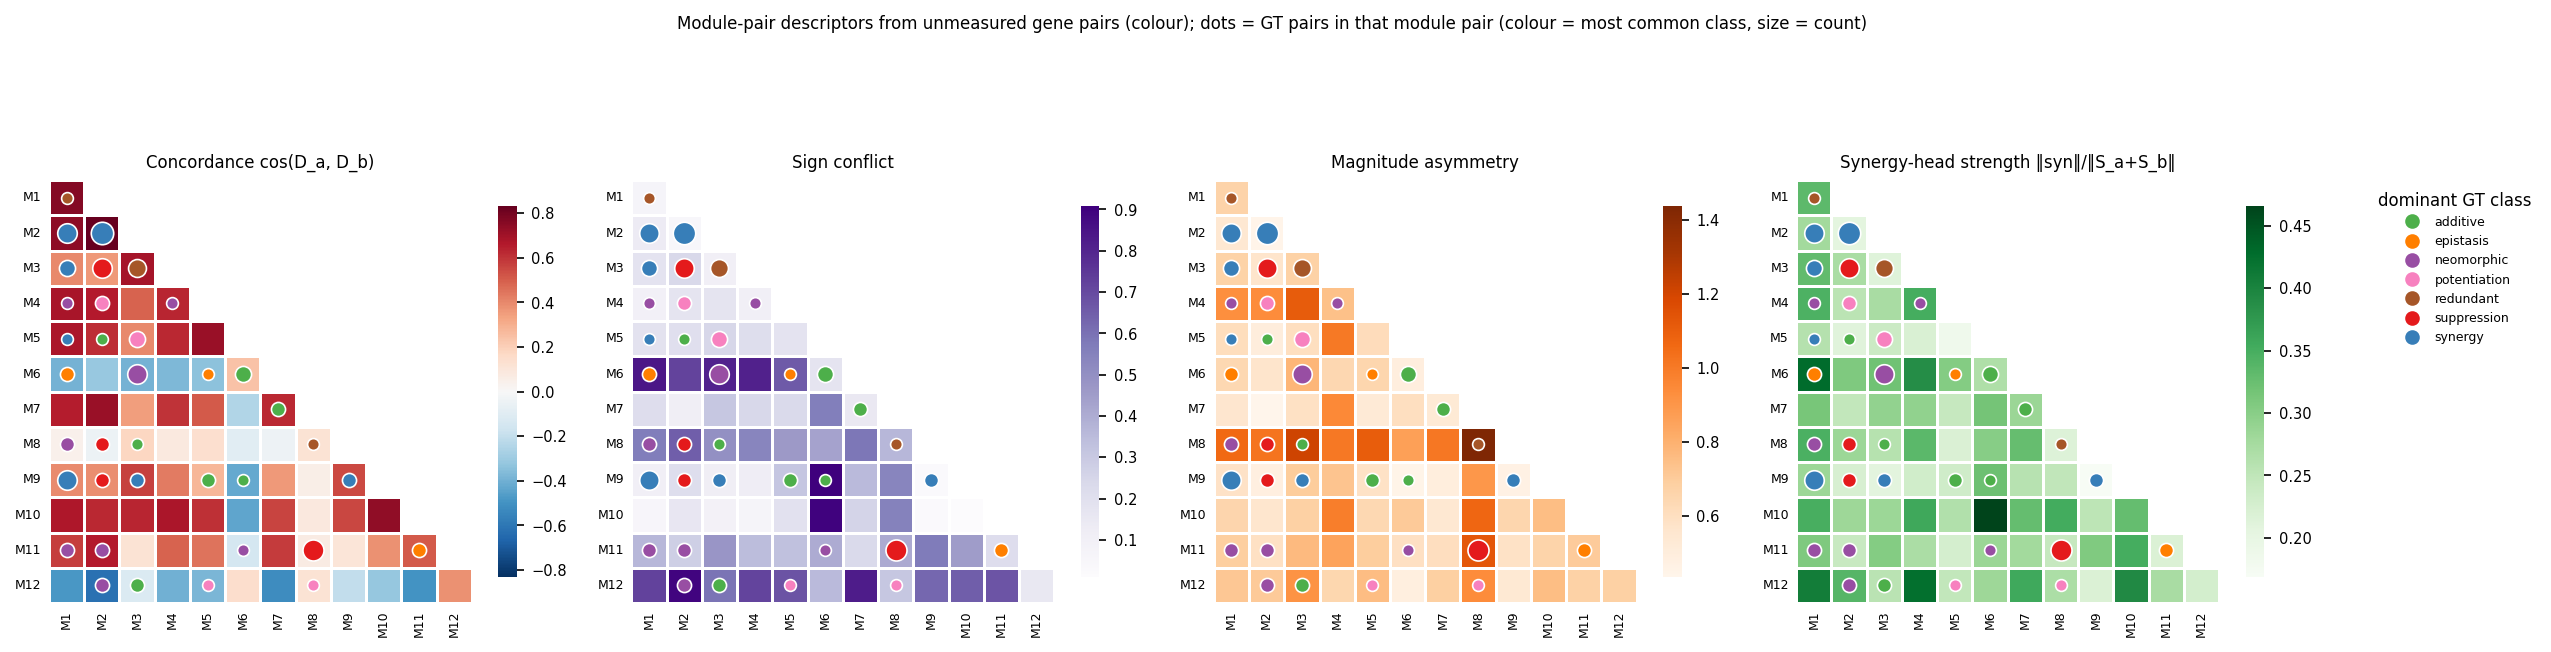

In [23]:
# ── Module-pair descriptors (unmeasured gene pairs only) ─────────────────
mp_desc = gp[~gp['measured_combo']].groupby('module_pair')[DESC].mean()
mp_desc['n_gene_pairs'] = gp[~gp['measured_combo']].groupby('module_pair').size()

def _mp_name(mi, mj):
    return mi if mi == mj else '×'.join(sorted([mi, mj], key=lambda m: int(m[1:])))

def mp_matrix(col):
    M = np.full((K_FINAL, K_FINAL), np.nan)
    for i, mi in enumerate(MODULES):
        for j, mj in enumerate(MODULES):
            name = _mp_name(mi, mj)
            if name in mp_desc.index:
                M[i, j] = mp_desc.loc[name, col]
    return M

# GT overlay per module pair: dominant class and count (for plotting only)
gt_dom = (pairs_df.groupby('module_pair')['gi']
          .agg(n='size', dominant=lambda s: s.value_counts().index[0],
               dom_frac=lambda s: s.value_counts().iloc[0] / len(s)))

PANELS = [('concordance', 'Concordance cos(D_a, D_b)', 'RdBu_r', True),
          ('sign_conflict', 'Sign conflict', 'Purples', False),
          ('mag_asym', 'Magnitude asymmetry', 'Oranges', False),
          ('syn_rel_norm', 'Synergy-head strength ‖syn‖/‖S_a+S_b‖', 'Greens', False)]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for ax, (col, title, cmap, diverging) in zip(axes, PANELS):
    M = mp_matrix(col)
    mask = np.triu(np.ones_like(M, dtype=bool), k=1)
    kw = dict(center=0, vmin=-np.nanmax(np.abs(M)), vmax=np.nanmax(np.abs(M))) if diverging else {}
    sns.heatmap(M, mask=mask, cmap=cmap, square=True, ax=ax, xticklabels=MODULES, yticklabels=MODULES,
                cbar_kws={'shrink': 0.6}, linewidths=0.5, linecolor='white', **kw)
    for i, mi in enumerate(MODULES):
        for j, mj in enumerate(MODULES[:i + 1]):
            name = _mp_name(mi, mj)
            if name in gt_dom.index:
                r = gt_dom.loc[name]
                ax.scatter(j + 0.5, i + 0.5, s=18 + 14 * r['n'], color=PALETTE_GI[r['dominant']],
                           edgecolor='white', linewidth=0.8, zorder=3)
    ax.set_title(title, fontsize=8)
    ax.tick_params(labelsize=6, length=0)
axes[-1].legend(handles=[Line2D([], [], marker='o', ls='', color=PALETTE_GI[c], label=short[c]) for c in GI_ORDER],
                frameon=False, bbox_to_anchor=(1.35, 1), loc='upper left', fontsize=6, title='dominant GT class')
fig.suptitle('Module-pair descriptors from unmeasured gene pairs (colour); dots = GT pairs in that module pair '
             '(colour = most common class, size = count)', fontsize=8, y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_pair_descriptor_maps.svg', bbox_inches='tight')
plt.show()

### 7b. What does each module do? (EV / effect programs)

Each module's mean signed effect D, averaged over its genes and the 5 runs, is shown on the most
variable readout genes. The CRISPRa targets themselves are excluded. Genes are grouped into
programs by clustering their module profiles. This shows *why* two modules are concordant or
conflicting.

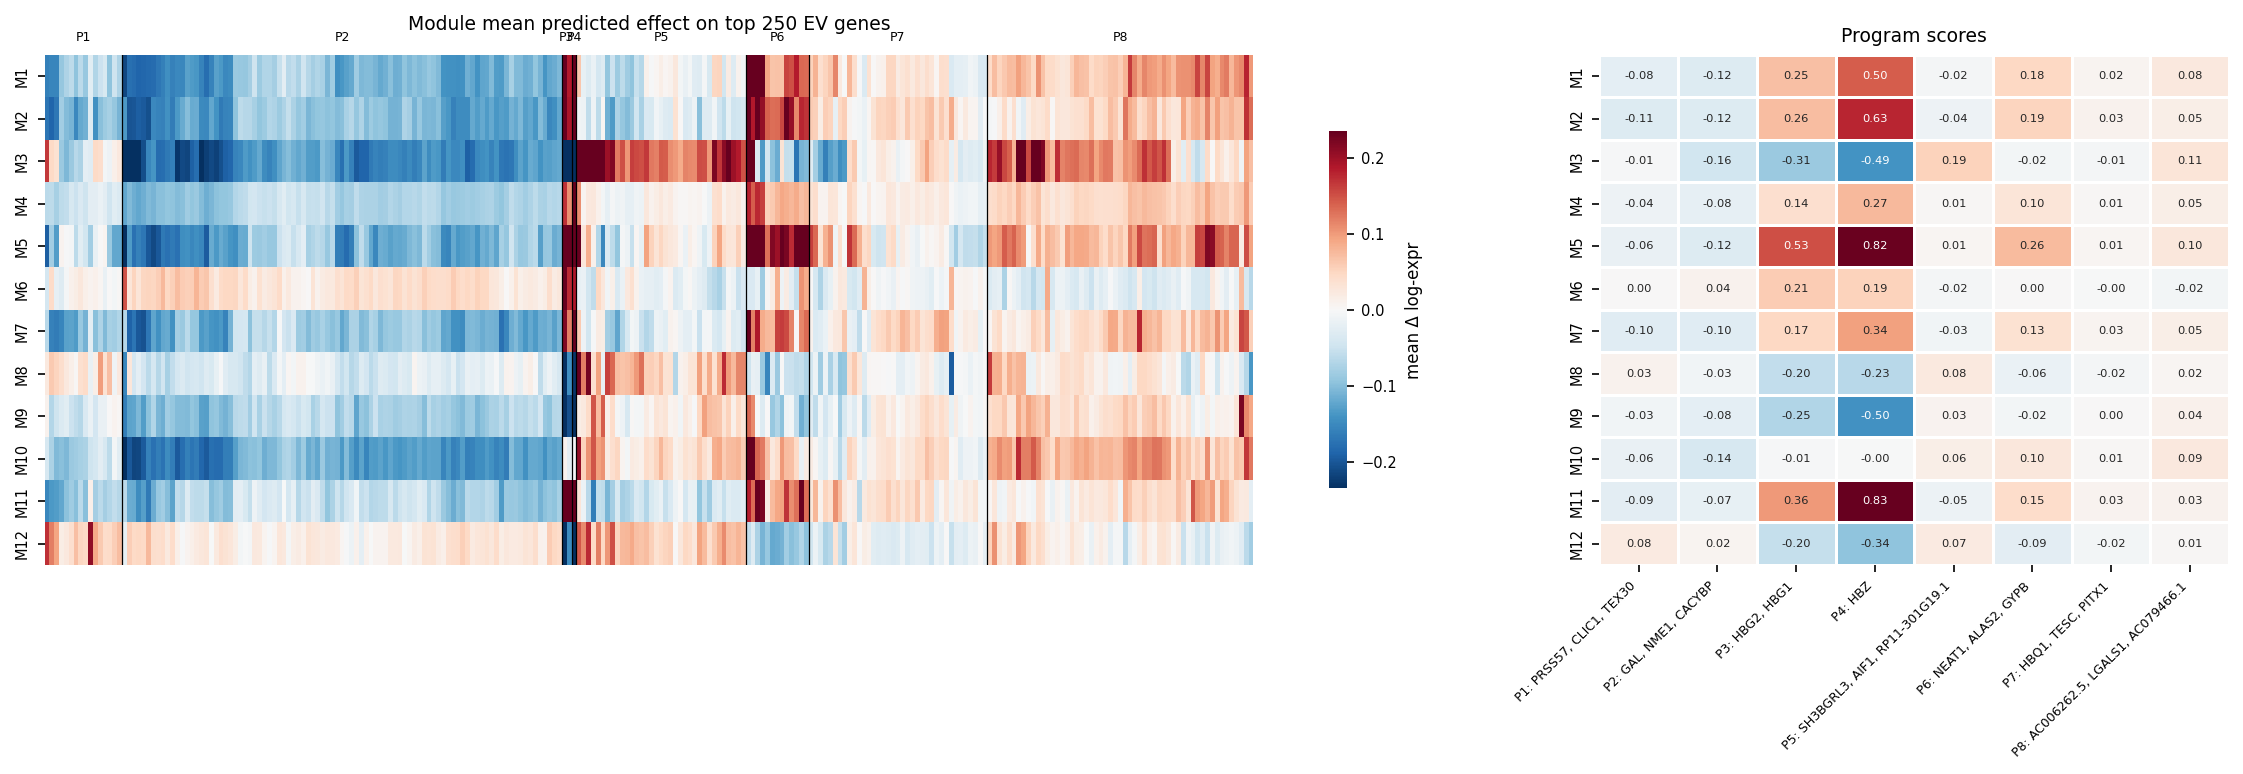

In [24]:
readout_mask = ~np.isin(var_names, genes)
D_mean = D_runs.mean(0)[:, readout_mask]          # (P, G_readout), run-averaged
EV_mean = EV_runs.mean(0)[:, readout_mask]
rnames = var_names[readout_mask]
mod_D = pd.DataFrame({m: D_mean[[g2i[g] for g in module_of.index[module_of == m]]].mean(0) for m in MODULES},
                     index=rnames).T                              # (K, G)
mod_EV = pd.DataFrame({m: EV_mean[[g2i[g] for g in module_of.index[module_of == m]]].mean(0) for m in MODULES},
                      index=rnames).T

N_TOP_GENES, N_PROGRAMS = 250, 8
top_genes = mod_EV.max(0).sort_values(ascending=False).index[:N_TOP_GENES]
X = mod_D[top_genes]
g_link = linkage(X.T.values, method='ward')
prog = pd.Series(fcluster(g_link, N_PROGRAMS, 'maxclust'), index=top_genes, name='program')
# Name each program by its three genes with the largest mean |effect|
prog_names = {}
for k in sorted(prog.unique()):
    gk = prog.index[prog == k]
    prog_names[k] = f'P{k}: ' + ', '.join(X[gk].abs().mean(0).sort_values(ascending=False).index[:3])
gene_order = [g for g in top_genes[leaves_list(g_link)]]
gene_order = sorted(gene_order, key=lambda g: (prog[g], gene_order.index(g)))

prog_score = pd.DataFrame({prog_names[k]: X[prog.index[prog == k]].mean(1) for k in sorted(prog.unique())})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios': [2.4, 1]})
lim = np.nanpercentile(np.abs(X.values), 98)
sns.heatmap(X[gene_order], cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, ax=axes[0],
            xticklabels=False, yticklabels=True, cbar_kws={'label': 'mean Δ log-expr', 'shrink': 0.7})
bounds = np.cumsum(prog[gene_order].value_counts(sort=False).reindex(sorted(prog.unique())).values)[:-1]
for b in bounds:
    axes[0].axvline(b, color='k', lw=0.6)
starts = np.r_[0, bounds]; ends = np.r_[bounds, len(gene_order)]
for k, s, e in zip(sorted(prog.unique()), starts, ends):
    axes[0].text((s + e) / 2, -0.25, f'P{k}', ha='center', va='bottom', fontsize=6)
axes[0].set_title(f'Module mean predicted effect on top {N_TOP_GENES} EV genes', pad=12)
lim2 = np.abs(prog_score.values).max()
sns.heatmap(prog_score, cmap='RdBu_r', center=0, vmin=-lim2, vmax=lim2, ax=axes[1], annot=True, fmt='.2f',
            annot_kws={'fontsize': 5.5}, cbar=False, linewidths=0.5, linecolor='white')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axes[1].set_title('Program scores')
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_effect_programs.svg', bbox_inches='tight')
plt.show()
mod_D.to_csv(OUT_DIR / 'module_mean_effect.csv')
prog.rename(index=str).map(prog_names).to_csv(OUT_DIR / 'effect_programs.csv')

/opt/conda/envs/perturb/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


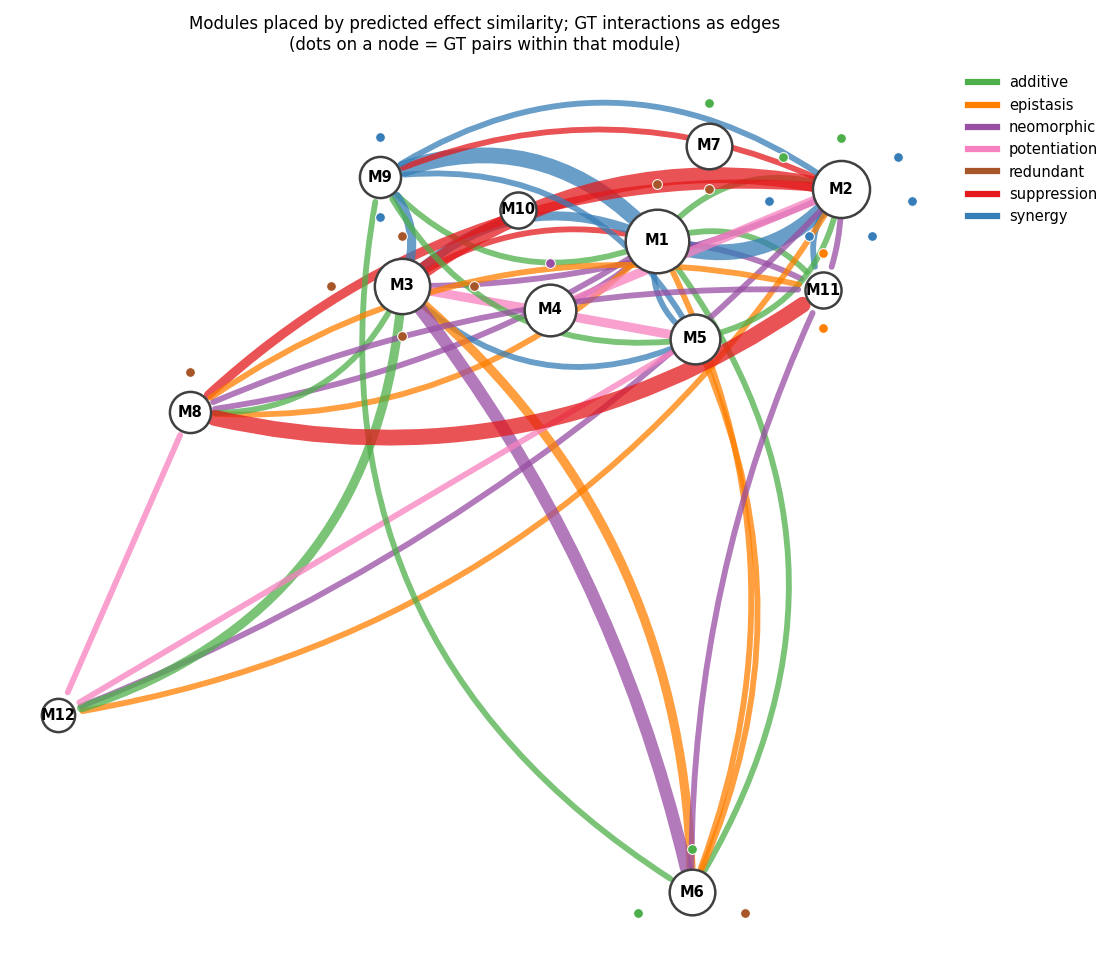

In [25]:
# Module network: nodes placed by similarity of module effect profiles (MDS on 1 − cosine of mod_D);
# edges are GT pairs coloured by class (one arc per class, width ∝ count). Within-module GT pairs are dots on the node.
from sklearn.manifold import MDS
Dm = 1 - _cos_mat(mod_D.values)
np.fill_diagonal(Dm, 0)
xy = MDS(n_components=2, dissimilarity='precomputed', random_state=0, normalized_stress='auto').fit_transform(Dm)
# light repulsion so overlapping nodes stay legible (keeps the MDS arrangement)
xy = (xy - xy.mean(0)) / xy.std()
for _ in range(300):
    diff = xy[:, None] - xy[None]
    dist = np.linalg.norm(diff, axis=2) + np.eye(len(xy))
    push = np.clip(0.55 - dist, 0, None)[..., None] * diff / dist[..., None]
    xy = xy + 0.1 * push.sum(1)
pos = dict(zip(MODULES, xy))
size = module_of.value_counts()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
rads = np.linspace(-0.35, 0.35, len(GI_ORDER))
for (mp_name, cls), n in pairs_df.groupby(['module_pair', 'gi']).size().items():
    if '×' not in mp_name:
        continue
    mi, mj = mp_name.split('×')
    ax.annotate('', xy=pos[mj], xytext=pos[mi],
                arrowprops=dict(arrowstyle='-', color=PALETTE_GI[cls], lw=1.2 + 1.6 * n, alpha=0.75,
                                connectionstyle=f'arc3,rad={rads[GI_ORDER.index(cls)]}', shrinkA=12, shrinkB=12))
for m in MODULES:
    x, y = pos[m]
    ax.scatter(x, y, s=120 + 45 * size[m], color='white', edgecolor='0.25', lw=1.2, zorder=4)
    ax.text(x, y, m, ha='center', va='center', fontsize=7, fontweight='bold', zorder=5)
    within = pairs_df[(pairs_df['module_pair'] == m)]['gi'].value_counts()
    k_tot = within.sum()
    if k_tot:
        ang = np.linspace(0, 2 * np.pi, k_tot, endpoint=False) + np.pi / 2
        cls_list = [c for c in GI_ORDER for _ in range(within.get(c, 0))]
        r = 0.09 + 0.004 * size[m]
        for a_, c in zip(ang, cls_list):
            ax.scatter(x + r * np.cos(a_) * 1.9, y + r * np.sin(a_) * 1.9, s=22, color=PALETTE_GI[c],
                       edgecolor='white', lw=0.5, zorder=6)
ax.legend(handles=[Line2D([], [], color=PALETTE_GI[c], lw=3, label=short[c]) for c in GI_ORDER],
          frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title('Modules placed by predicted effect similarity; GT interactions as edges\n'
             '(dots on a node = GT pairs within that module)', fontsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_interaction_network.svg', bbox_inches='tight')
plt.show()

## 8. Label-free interaction regimes

All module pairs (within and between modules) are clustered on the z-scored module-pair descriptors
with Ward linkage. The number of regimes is picked by silhouette, again without labels. Only after
that are the GT pairs mapped onto their module pair's regime.

In [26]:
Zmp = mp_desc[CLUSTER_DESC]
Zmp = (Zmp - Zmp.mean()) / Zmp.std()
mp_link = linkage(Zmp.values, method='ward')
sil = {k: silhouette_score(Zmp.values, fcluster(mp_link, k, 'maxclust')) for k in range(3, 9)}
N_REGIMES = max(sil, key=sil.get)
regime = pd.Series(fcluster(mp_link, N_REGIMES, 'maxclust'), index=Zmp.index, name='regime')
# order regimes by mean concordance (high -> low) for readability
_ord = mp_desc.groupby(regime)['concordance'].mean().sort_values(ascending=False).index
regime = regime.map({old: f'R{n + 1}' for n, old in enumerate(_ord)})
REGIMES = [f'R{n + 1}' for n in range(N_REGIMES)]
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()}, '→', N_REGIMES, 'regimes')

regime_profile = mp_desc[DESC].groupby(regime).mean().reindex(REGIMES)
regime_profile.insert(0, 'n_module_pairs', regime.value_counts().reindex(REGIMES))
regime_profile.insert(1, 'module_pairs', [', '.join(sorted(regime.index[regime == r], key=lambda s: [int(x[1:]) for x in s.split('×')])) for r in REGIMES])
pairs_df['regime'] = pairs_df['module_pair'].map(regime)
regime_profile.round(2)

silhouette by k: {3: 0.257, 4: 0.276, 5: 0.287, 6: 0.227, 7: 0.214, 8: 0.217} → 5 regimes


,n_module_pairs,module_pairs,concordance,target_overlap,sign_conflict,latent_cos,gate_jaccard,mag_asym,mag_mean,c_mean,c_diff,syn_rel_norm,syn_cos_add
regime,,,,,,,,,,,,,
R1,7,"M1×M4, M2×M4, M3×M4, M4, M4×M5, M4×M7, M4×M10",0.62,0.61,0.15,0.43,0.39,0.95,0.66,0.93,0.04,0.30,0.46
R2,32,"M1, M1×M2, M1×M3, M1×M5, M1×M7, M1×M9, M1×M10, M1×M11, M2, M2×M3, M2×M5, M2×M7, M2×M10, M2×M11, M3, M3×M5, M3×M7, M3×M9, M3×M10, M3×M11, M5, M5×M7, M5×M9, M5×M10, M5×M11, M7, M7×M9, M7×M10, M7×M11...",0.56,0.56,0.20,0.28,0.50,0.61,1.03,0.86,0.06,0.27,0.43
R3,11,"M2×M9, M4×M9, M4×M11, M6, M6×M11, M6×M12, M9, M9×M11, M9×M12, M11, M12",0.26,0.61,0.29,0.16,0.47,0.60,0.66,0.90,0.04,0.25,0.21
R4,12,"M1×M8, M2×M8, M3×M8, M4×M8, M5×M8, M6×M8, M7×M8, M8, M8×M9, M8×M10, M8×M11, M8×M12",0.06,0.52,0.49,0.03,0.44,1.06,0.53,0.85,0.06,0.28,0.41
R5,16,"M1×M6, M1×M12, M2×M6, M2×M12, M3×M6, M3×M12, M4×M6, M4×M12, M5×M6, M5×M12, M6×M7, M6×M9, M6×M10, M7×M12, M10×M12, M11×M12",-0.39,0.50,0.75,-0.23,0.46,0.68,0.76,0.90,0.05,0.35,0.28


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


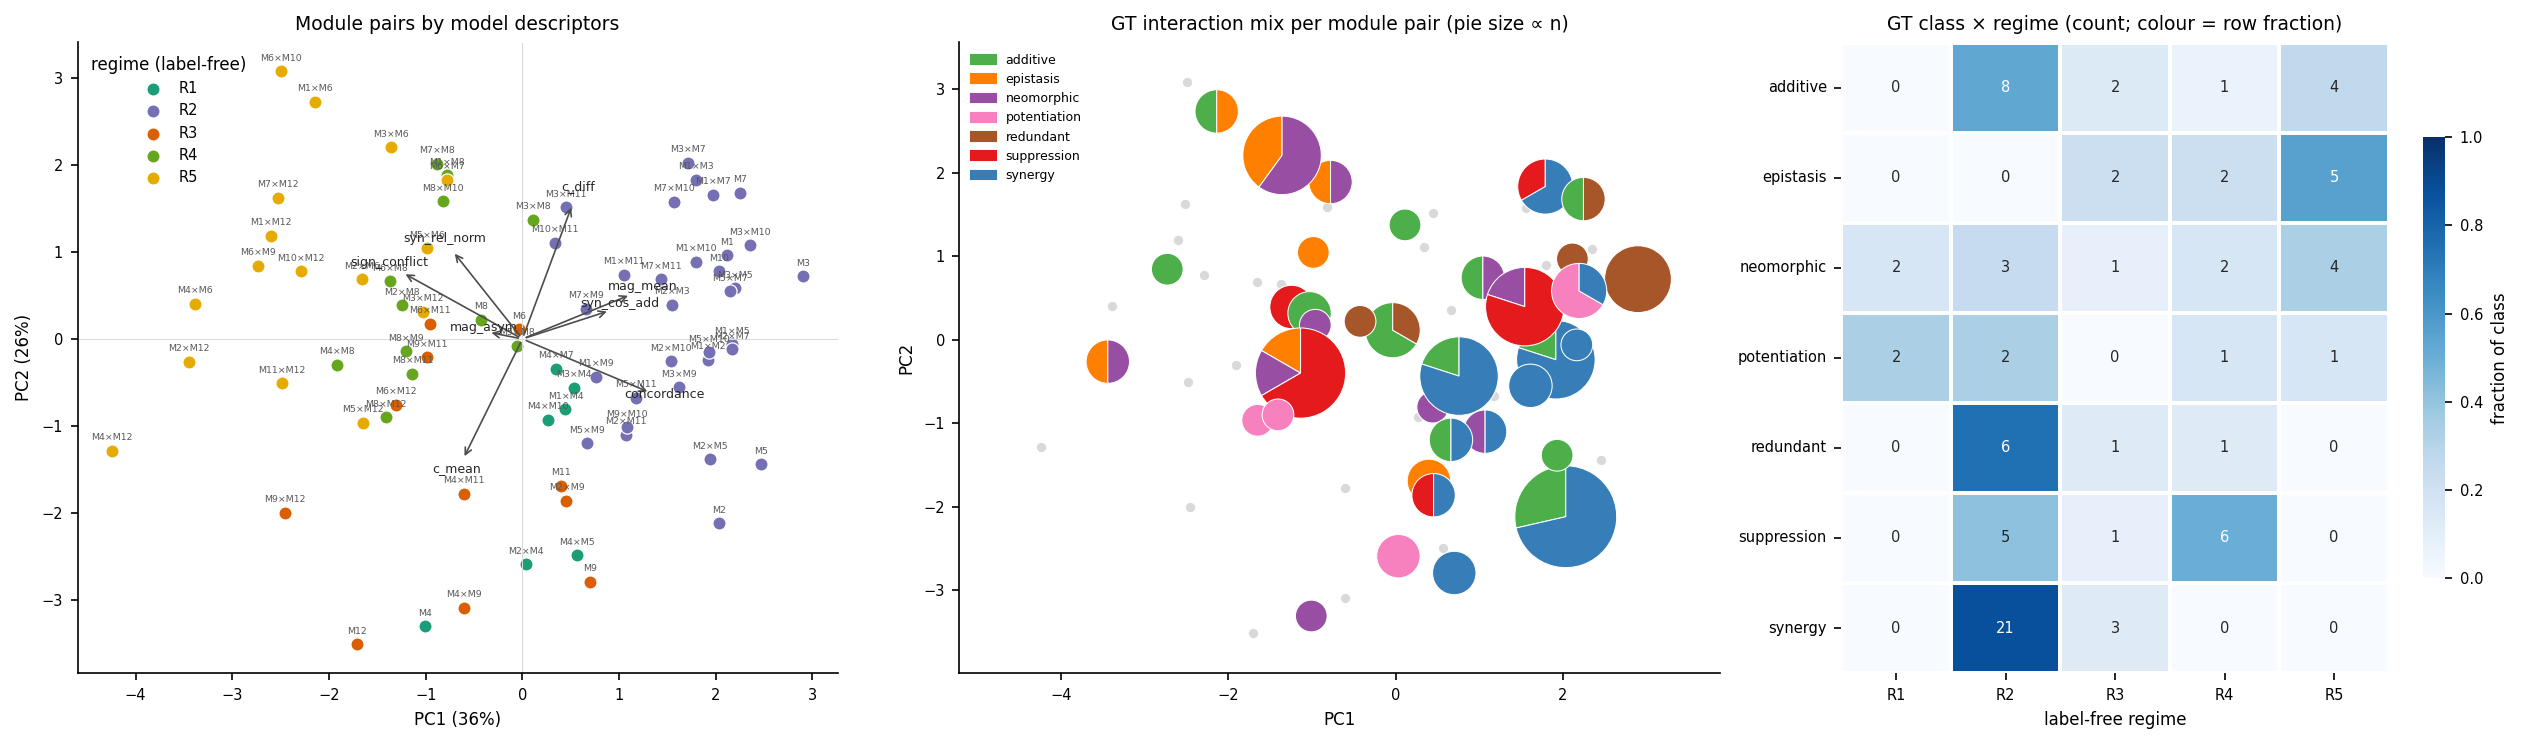

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(Zmp.values)
pc = pd.DataFrame(pca.transform(Zmp.values), index=Zmp.index, columns=['PC1', 'PC2'])
REG_COLORS = dict(zip(REGIMES, ['#1b9e77', '#7570b3', '#d95f02', '#66a61e', '#e6ab02', '#a6761d', '#666666', '#e7298a'][:N_REGIMES]))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={'width_ratios': [1, 1, 0.9]})
ax = axes[0]
for r in REGIMES:
    s = pc[regime == r]
    ax.scatter(s['PC1'], s['PC2'], s=40, color=REG_COLORS[r], edgecolor='white', lw=0.6, label=r)
for name, (x, y) in pc.iterrows():
    ax.text(x, y + 0.12, name, fontsize=4.5, ha='center', color='0.35')
load = pca.components_.T * 2.6
for f, (lx, ly) in zip(CLUSTER_DESC, load):
    ax.annotate('', xy=(lx, ly), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='0.3', lw=0.8))
    ax.text(lx * 1.1, ly * 1.1, f, fontsize=6, color='0.15', ha='center')
ax.axhline(0, color='0.85', lw=0.5); ax.axvline(0, color='0.85', lw=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})'); ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.legend(frameon=False, title='regime (label-free)')
ax.set_title('Module pairs by model descriptors')

# Same coordinates; module pairs with GT pairs drawn as pies of their GT class mix
ax = axes[1]
ax.scatter(pc['PC1'], pc['PC2'], s=12, color='0.85', zorder=1)
for name, row in mp_counts.iterrows():
    if name not in pc.index:
        continue
    x0, y0 = pc.loc[name]
    radius = 0.12 + 0.07 * row['n']
    start = 90
    for c in GI_ORDER:
        if row[c] == 0:
            continue
        ext = 360 * row[c] / row['n']
        ax.add_patch(mpl.patches.Wedge((x0, y0), radius, start, start + ext, fc=PALETTE_GI[c], ec='white', lw=0.5, zorder=3))
        start += ext
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlim(axes[0].get_xlim()); ax.set_ylim(axes[0].get_ylim())
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(handles=[mpl.patches.Patch(color=PALETTE_GI[c], label=short[c]) for c in GI_ORDER], frameon=False,
          fontsize=6, loc='best')
ax.set_title('GT interaction mix per module pair (pie size ∝ n)')

# Where does each GT class fall among the label-free regimes?
ax = axes[2]
ct = pd.crosstab(pairs_df['gi'], pairs_df['regime']).reindex(index=GI_ORDER, columns=REGIMES, fill_value=0)
frac = ct.div(ct.sum(1), axis=0)
sns.heatmap(frac, cmap='Blues', vmin=0, vmax=1, annot=ct, fmt='d', annot_kws={'fontsize': 7},
            linewidths=1, linecolor='white', cbar_kws={'label': 'fraction of class', 'shrink': 0.7}, ax=ax)
ax.set_yticklabels([short[c] for c in GI_ORDER], rotation=0)
ax.set_xlabel('label-free regime'); ax.set_ylabel('')
ax.set_title('GT class × regime (count; colour = row fraction)')
plt.tight_layout()
fig.savefig(OUT_DIR / 'label_free_regimes.svg', bbox_inches='tight')
plt.show()

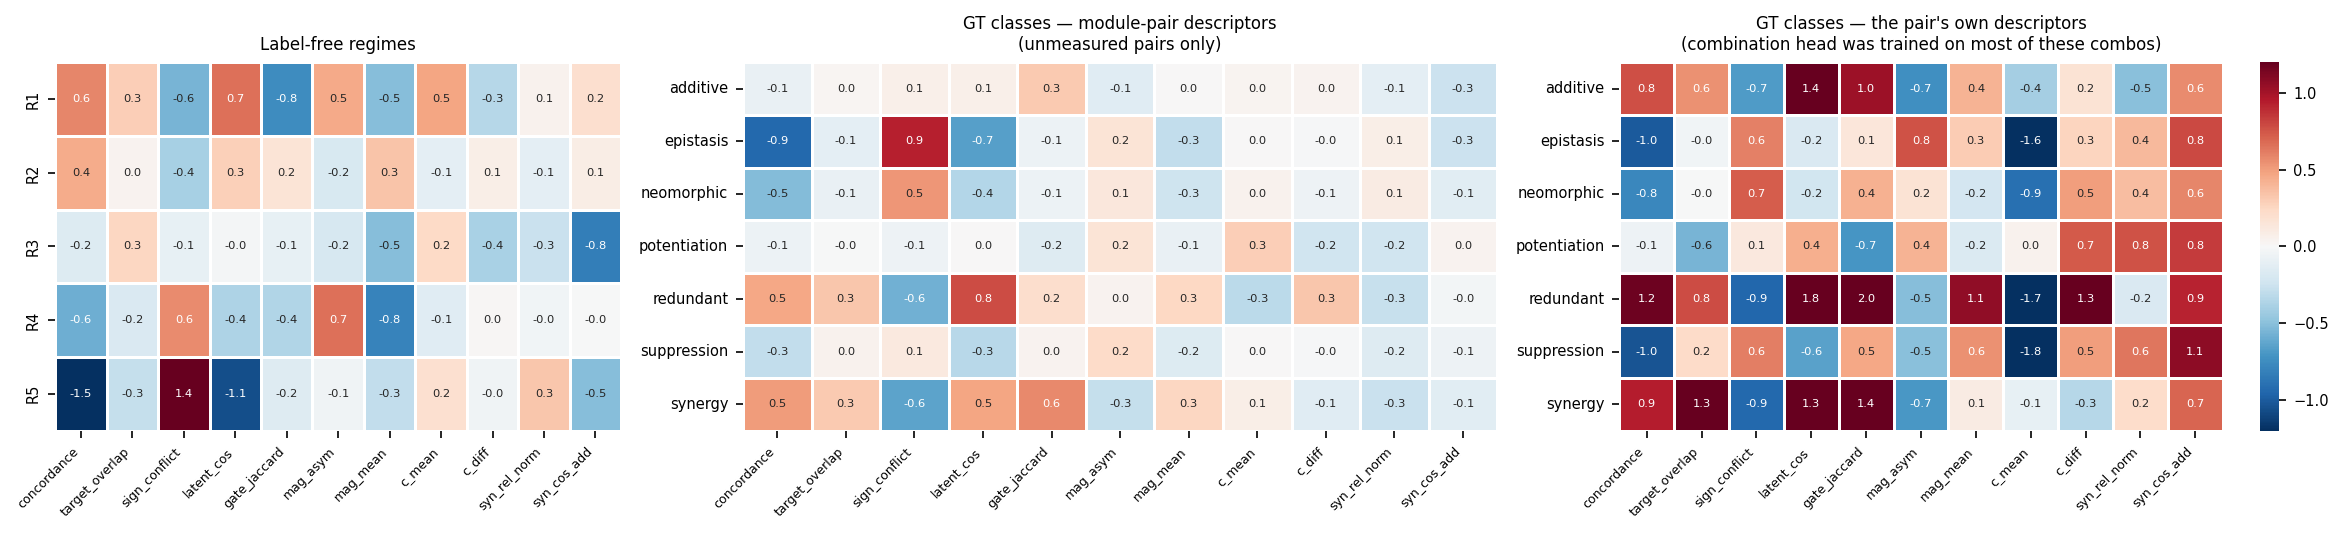

In [28]:
# Descriptor fingerprints: regimes (label-free) vs GT classes (labels only used to average)
def _z(df):
    return (df - gp[DESC].mean()) / gp[DESC].std()

fp_regime = _z(regime_profile[DESC])
fp_class_mp = _z(pairs_df.join(mp_desc[DESC], on='module_pair').groupby('gi')[DESC].mean().reindex(GI_ORDER))
fp_class_own = _z(pairs_df.join(gp.set_index('combination')[DESC], on='combination')
                  .groupby('gi')[DESC].mean().reindex(GI_ORDER))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6), gridspec_kw={'width_ratios': [0.75, 1, 1]})
lim = 1.2
for ax, M, title in [(axes[0], fp_regime, 'Label-free regimes'),
                     (axes[1], fp_class_mp, 'GT classes — module-pair descriptors\n(unmeasured pairs only)'),
                     (axes[2], fp_class_own, "GT classes — the pair's own descriptors\n(combination head was trained on most of these combos)")]:
    sns.heatmap(M, cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, annot=True, fmt='.1f', annot_kws={'fontsize': 5.5},
                linewidths=0.5, linecolor='white', cbar=ax is axes[2], ax=ax,
                yticklabels=[short.get(i, i) for i in M.index])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
    ax.set_title(title, fontsize=8)
    ax.set_ylabel('')
plt.tight_layout()
fig.savefig(OUT_DIR / 'descriptor_fingerprints.svg', bbox_inches='tight')
plt.show()
regime_profile.to_csv(OUT_DIR / 'label_free_regimes.csv')

## 9. ρ and W together: *which* latent factors vs. *which direction*

ρ measures whether two perturbations move the latent state the same way. The gate **W** says *which*
latent factors each one uses at all. Two perturbations can share factors but push them oppositely,
or use disjoint factors and barely interact. Splitting a pair into those two questions gives:

- **gate_overlap** = Jaccard of the active gate sets (W > 0.5) — do they use the same factors?
- **shared_cos** = cos(S_a, S_b) restricted to jointly-active factors — on the factors they share,
  do they push the same way?
- **private_frac** = mean share of each shift's energy sitting on factors the *partner* does not use
  — how much of each perturbation acts on its own private factors.

Gate overlap is nearly independent of ρ (Spearman ≈ 0.2), so W is a genuinely new axis, whereas
shared_cos mostly re-expresses ρ (≈ 0.86).

In [29]:
GATE_THR = 0.5

def gate_features(r):
    W, Sm = r['W'], r['S']
    ia, ib = IU
    act = W > GATE_THR
    sh = (act[ia] & act[ib]).astype(float)
    un = (act[ia] | act[ib]).astype(float)
    Sa, Sb = Sm[ia], Sm[ib]
    num = (sh * Sa * Sb).sum(1)
    den = np.sqrt((sh * Sa ** 2).sum(1) * (sh * Sb ** 2).sum(1))
    pa = ((~act[ib]) * Sa ** 2).sum(1) / ((Sa ** 2).sum(1) + 1e-8)
    pb = ((~act[ia]) * Sb ** 2).sum(1) / ((Sb ** 2).sum(1) + 1e-8)
    return {'gate_overlap': sh.sum(1) / (un.sum(1) + 1e-8),
            'shared_cos':   np.where(den > 1e-8, num / np.maximum(den, 1e-8), np.nan),
            'private_frac': (pa + pb) / 2,
            'n_shared':     sh.sum(1)}

_gf_runs = [gate_features(r) for r in feat_runs]
GATE_DESC = list(_gf_runs[0])
for k in GATE_DESC:
    gp[k] = np.nanmean([g[k] for g in _gf_runs], 0)
gp['rho'] = R_mean[IU]

gate_stab = pd.Series({k: np.nanmean([spearmanr(_gf_runs[i][k], _gf_runs[j][k], nan_policy='omit')[0]
                                      for i, j in pairs]) for k in GATE_DESC}, name='cross-run Spearman')
print('Cross-run stability of the gate descriptors (averaged over the 5 runs before use):')
print(pd.DataFrame({'cross-run Spearman': gate_stab,
                    'Spearman with rho': gp[GATE_DESC].corrwith(gp['rho'], method='spearman')}).round(2).to_string())

pairs_gate = pairs_df.merge(gp[['combination'] + GATE_DESC], on='combination', how='left')
pairs_gate.to_csv(OUT_DIR / 'gt_pair_gate_features.csv', index=False)
print(f'\nGT pairs with gate descriptors: {pairs_gate[GATE_DESC].notna().all(1).sum()} / {len(pairs_gate)}')
pairs_gate.groupby('gi')[['rho', 'gate_overlap', 'shared_cos', 'private_frac', 'n_shared']].mean().reindex(GI_ORDER).round(3)

Cross-run stability of the gate descriptors (averaged over the 5 runs before use):
              cross-run Spearman  Spearman with rho
gate_overlap                0.38               0.19
shared_cos                  0.75               0.86
private_frac                0.35              -0.24
n_shared                    0.53               0.17

GT pairs with gate descriptors: 86 / 86


,rho,gate_overlap,shared_cos,private_frac,n_shared
gi,,,,,
approximately additive,0.546,0.609,0.834,0.143,5.800
epistasis,-0.001,0.500,0.036,0.240,4.600
neomorphic,-0.025,0.535,0.109,0.200,4.550
potentiation,0.129,0.395,0.708,0.445,3.567
redundant,0.758,0.725,0.908,0.074,6.025
suppression,-0.126,0.540,-0.125,0.205,4.983
synergy,0.499,0.656,0.795,0.168,6.392


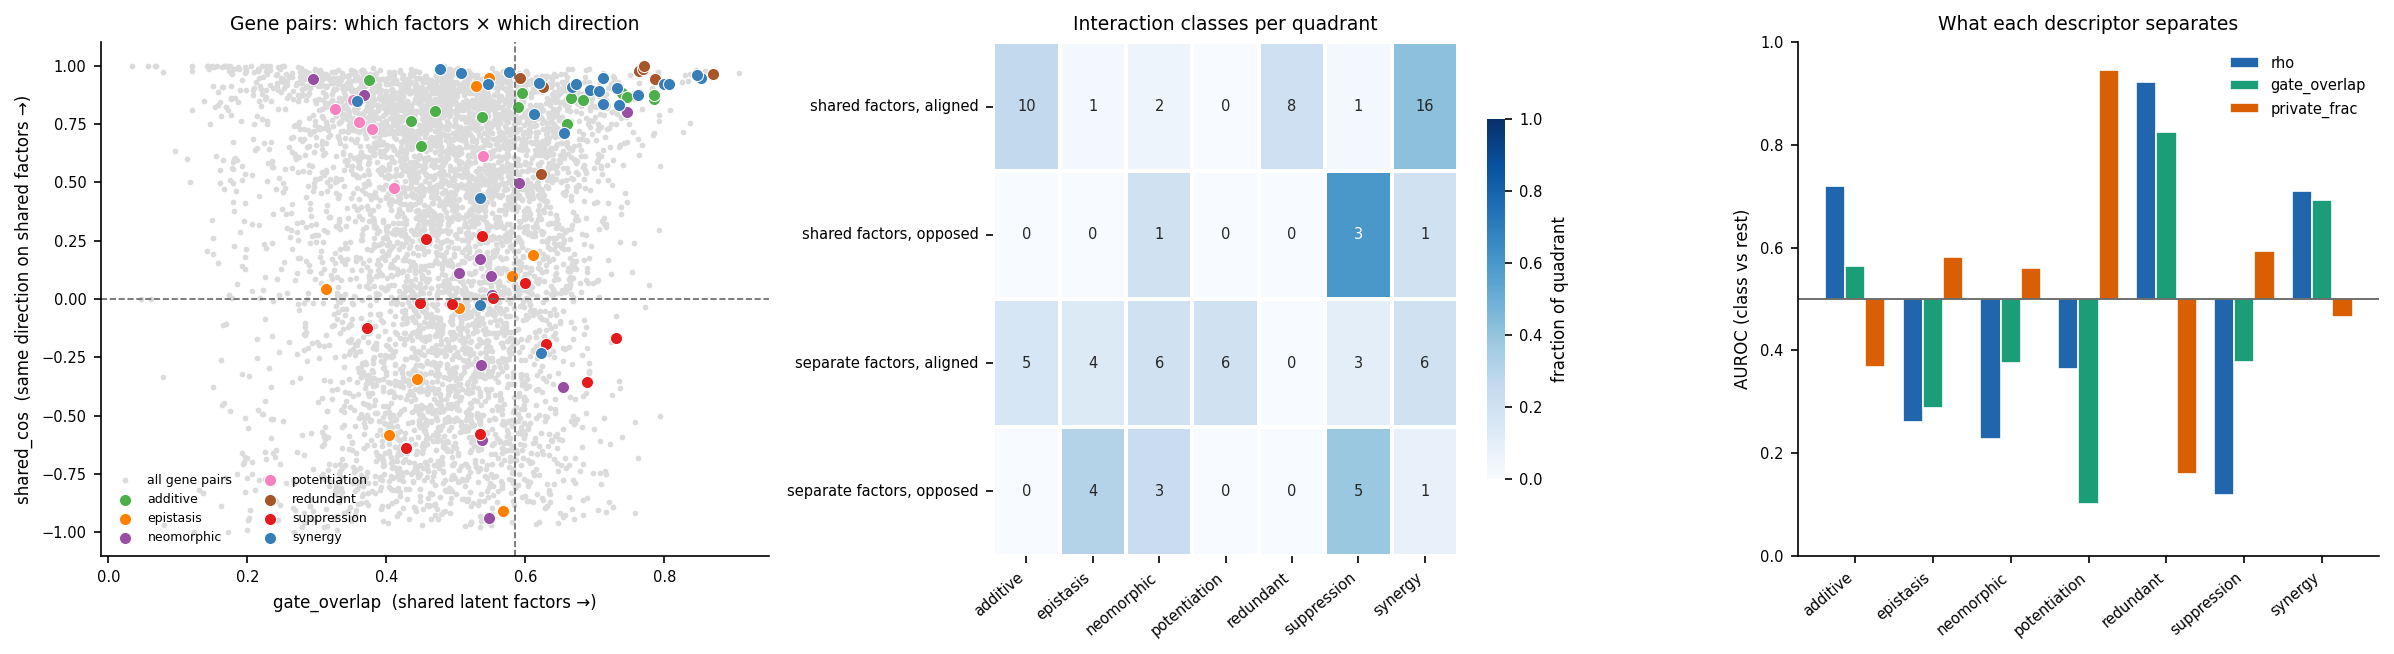

,rho,gate_overlap,private_frac
approximately additive,0.721,0.565,0.367
epistasis,0.261,0.287,0.582
neomorphic,0.226,0.376,0.560
potentiation,0.365,0.100,0.946
redundant,0.923,0.825,0.159
suppression,0.118,0.377,0.593
synergy,0.710,0.692,0.465


In [30]:
# Where each class sits in the (which factors) × (which direction) plane
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={'width_ratios': [1.15, 1, 1]})

ax = axes[0]
ax.scatter(gp['gate_overlap'], gp['shared_cos'], s=3, color='0.86', rasterized=True, label='all gene pairs')
for c in GI_ORDER:
    s = pairs_gate[pairs_gate['gi'] == c]
    ax.scatter(s['gate_overlap'], s['shared_cos'], s=34, color=PALETTE_GI[c], edgecolor='white', lw=0.5, label=short[c])
gmed = pairs_gate['gate_overlap'].median()
ax.axvline(gmed, color='0.4', ls='--', lw=0.8); ax.axhline(0, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('gate_overlap  (shared latent factors →)')
ax.set_ylabel('shared_cos  (same direction on shared factors →)')
ax.set_title('Gene pairs: which factors × which direction')
ax.legend(frameon=False, fontsize=6, ncol=2, loc='lower left')

# Quadrant composition
q_gate = pairs_gate['gate_overlap'] > gmed
q_dir = pairs_gate['shared_cos'] > 0
pairs_gate['quadrant'] = np.select(
    [q_gate & q_dir, q_gate & ~q_dir, ~q_gate & q_dir, ~q_gate & ~q_dir],
    ['shared factors, aligned', 'shared factors, opposed',
     'separate factors, aligned', 'separate factors, opposed'], default='')
QUAD = ['shared factors, aligned', 'shared factors, opposed',
        'separate factors, aligned', 'separate factors, opposed']
qt = pd.crosstab(pairs_gate['quadrant'], pairs_gate['gi']).reindex(index=QUAD, columns=GI_ORDER, fill_value=0)
ax = axes[1]
sns.heatmap(qt.div(qt.sum(1), axis=0), cmap='Blues', vmin=0, vmax=1, annot=qt, fmt='d', annot_kws={'fontsize': 7},
            linewidths=1, linecolor='white', cbar_kws={'label': 'fraction of quadrant', 'shrink': 0.7}, ax=ax)
ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right')
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('Interaction classes per quadrant')

# Per-class AUROC: rho alone vs the gate descriptors
def _auroc(col):
    out = {}
    for c in GI_ORDER:
        xx = pairs_gate.loc[pairs_gate['gi'] == c, col].dropna()
        yy = pairs_gate.loc[pairs_gate['gi'] != c, col].dropna()
        out[c] = mannwhitneyu(xx, yy).statistic / (len(xx) * len(yy))
    return pd.Series(out)

auroc_tab = pd.DataFrame({c: _auroc(c) for c in ['rho', 'gate_overlap', 'private_frac']}).reindex(GI_ORDER)
ax = axes[2]
xpos = np.arange(len(GI_ORDER)); w = 0.26
for n, (col, clr) in enumerate(zip(auroc_tab.columns, ['#2166ac', '#1b9e77', '#d95f02'])):
    ax.bar(xpos + (n - 1) * w, auroc_tab[col] - 0.5, width=w, bottom=0.5, color=clr, label=col,
           edgecolor='white', linewidth=0.8)
ax.axhline(0.5, color='0.3', lw=0.75)
ax.set_xticks(xpos); ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right')
ax.set_ylim(0, 1); ax.set_ylabel('AUROC (class vs rest)')
ax.legend(frameon=False, fontsize=7)
ax.set_title('What each descriptor separates')
plt.tight_layout()
fig.savefig(OUT_DIR / 'rho_vs_gate_plane.svg', bbox_inches='tight')
plt.show()
auroc_tab.round(3)

### 9b. The same plane at module level

Module pairs are placed by their mean gate overlap and mean ρ, averaged over gene pairs that were
never measured as combos. If the hypothesis holds, module pairs that share factors and point the
same way should host the redundant / synergy / additive pairs, and module pairs on private factors
or opposed directions should host potentiation, epistasis, neomorphic and suppression.

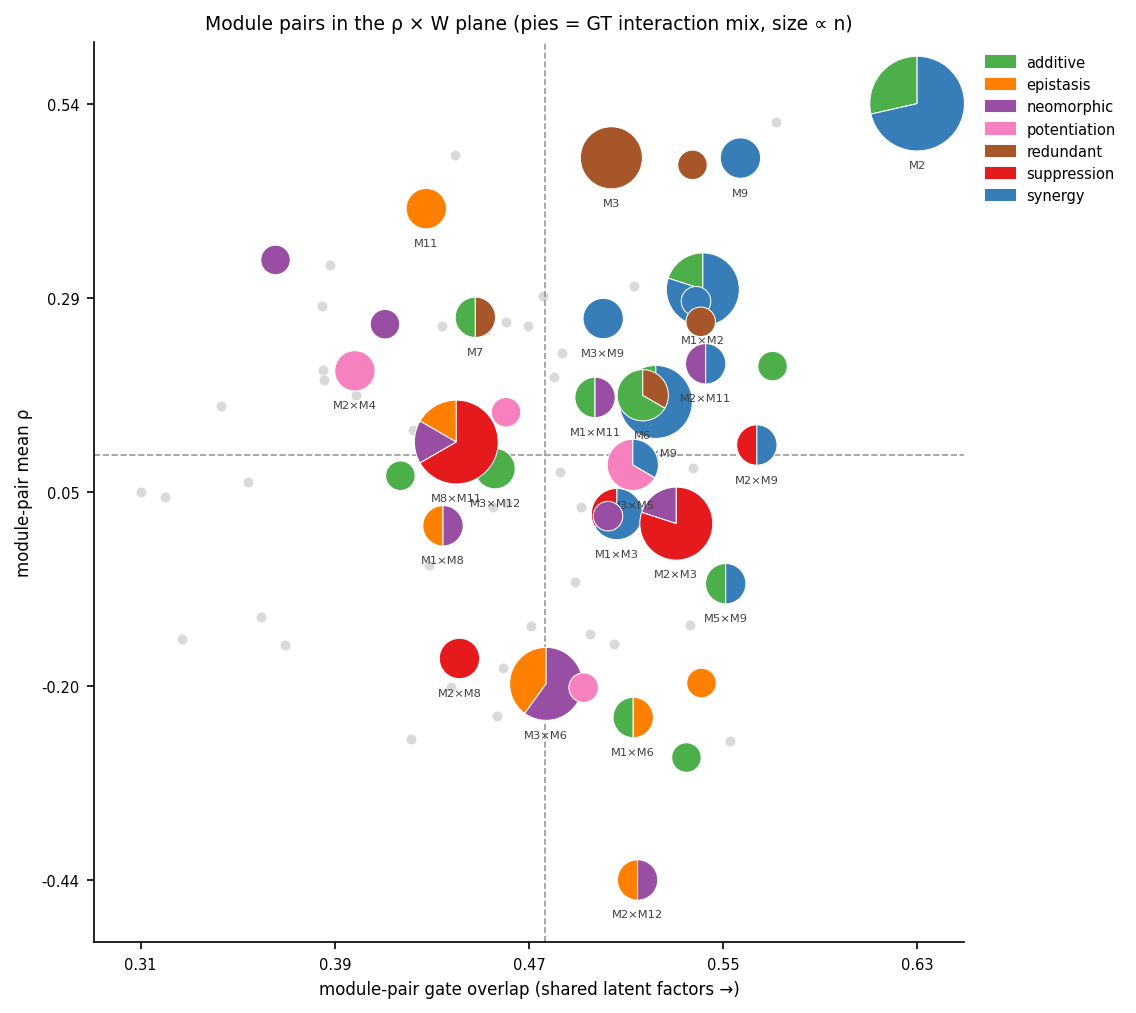

,n,classes,rho,gate_overlap,private_frac,shared_cos
module_pair,,,,,,
M2×M4,2,potentiation:2,0.202,0.398,0.317,0.653
M11,2,epistasis:2,0.407,0.428,0.378,0.549
M1×M8,2,"neomorphic:1, epistasis:1",0.006,0.435,0.377,0.000
M8×M11,6,"suppression:4, neomorphic:1, epistasis:1",0.112,0.440,0.320,0.261
M2×M8,2,suppression:2,-0.162,0.441,0.322,-0.354
M7,2,"approximately additive:1, redundant:1",0.270,0.448,0.352,0.652
M3×M12,2,approximately additive:2,0.078,0.456,0.300,0.150
M3×M6,5,"neomorphic:3, epistasis:2",-0.194,0.478,0.330,-0.418
M1×M11,2,"neomorphic:1, approximately additive:1",0.168,0.498,0.304,0.435


In [31]:
mp_gate = (gp[~gp['measured_combo']].groupby('module_pair')[['rho'] + GATE_DESC].mean())
mp_gate['n_gt'] = pairs_df.groupby('module_pair').size().reindex(mp_gate.index).fillna(0).astype(int)
mp_gate.to_csv(OUT_DIR / 'module_pair_gate_features.csv')

fig, ax = plt.subplots(figsize=(8.5, 6.8))
# plot in normalised coordinates with equal aspect so the pies stay circular
_xs, _ys = mp_gate['gate_overlap'].values, mp_gate['rho'].values
_x0, _x1 = _xs.min(), _xs.max(); _y0, _y1 = _ys.min(), _ys.max()
_nx = lambda v: (v - _x0) / (_x1 - _x0)
_ny = lambda v: (v - _y0) / (_y1 - _y0)
ax.scatter(_nx(_xs), _ny(_ys), s=14, color='0.85', zorder=1)
for name, row in mp_gate[mp_gate['n_gt'] > 0].iterrows():
    comp = pairs_df[pairs_df['module_pair'] == name]['gi'].value_counts()
    x0, y0, tot = _nx(row['gate_overlap']), _ny(row['rho']), comp.sum()
    radius = 0.012 + 0.007 * tot
    start = 90
    for c in GI_ORDER:
        if comp.get(c, 0) == 0:
            continue
        ext = 360 * comp[c] / tot
        ax.add_patch(mpl.patches.Wedge((x0, y0), radius, start, start + ext, fc=PALETTE_GI[c],
                                       ec='white', lw=0.5, zorder=3))
        start += ext
    if tot >= 2:
        ax.text(x0, y0 - radius - 0.012, name, fontsize=5.5, ha='center', va='top', color='0.25')
ax.axvline(_nx(np.median(_xs)), color='0.6', ls='--', lw=0.8)
ax.axhline(_ny(np.median(_ys)), color='0.6', ls='--', lw=0.8)
ax.set_aspect('equal')
ax.set_xlim(-0.06, 1.06); ax.set_ylim(-0.08, 1.08)
_xt = np.linspace(_x0, _x1, 5); _yt = np.linspace(_y0, _y1, 5)
ax.set_xticks(_nx(_xt)); ax.set_xticklabels([f'{v:.2f}' for v in _xt])
ax.set_yticks(_ny(_yt)); ax.set_yticklabels([f'{v:.2f}' for v in _yt])
ax.set_xlabel('module-pair gate overlap (shared latent factors →)')
ax.set_ylabel('module-pair mean ρ')
ax.set_title('Module pairs in the ρ × W plane (pies = GT interaction mix, size ∝ n)', fontsize=9)
ax.legend(handles=[mpl.patches.Patch(color=PALETTE_GI[c], label=short[c]) for c in GI_ORDER],
          frameon=False, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
fig.savefig(OUT_DIR / 'module_pair_rho_gate_plane.svg', bbox_inches='tight')
plt.show()

tbl = (pairs_df.groupby('module_pair')
       .agg(n=('gi', 'size'), classes=('gi', lambda s: ', '.join(f'{k}:{v}' for k, v in s.value_counts().items())))
       .join(mp_gate[['rho', 'gate_overlap', 'private_frac', 'shared_cos']]))
tbl[tbl['n'] >= 2].sort_values('gate_overlap').round(3)

In [32]:
# Does W actually add predictive value beyond rho? Gene-disjoint leave-one-out, so no pair is
# predicted from another pair sharing a gene with it.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

_pg = pairs_gate.dropna(subset=GATE_DESC).reset_index(drop=True)
_ai = _pg['a'].map(g2i).values; _bi = _pg['b'].map(g2i).values; _y = _pg['gi'].values

def loo_acc(cols):
    Xs = StandardScaler().fit_transform(_pg[cols].values)
    ok = []
    for i in range(len(_pg)):
        tr = [j for j in range(len(_pg)) if j != i and not ({_ai[i], _bi[i]} & {_ai[j], _bi[j]})]
        clf = LogisticRegression(max_iter=2000).fit(Xs[tr], _y[tr])
        ok.append(clf.predict(Xs[[i]])[0] == _y[i])
    return float(np.mean(ok))

rows = [{'features': ' + '.join(c), 'LOO accuracy': loo_acc(c)} for c in
        [['rho'], ['gate_overlap'], ['rho', 'gate_overlap'], ['rho', 'gate_overlap', 'private_frac'],
         ['rho', 'gate_overlap', 'private_frac', 'shared_cos', 'n_shared']]]
rows.append({'features': 'majority class', 'LOO accuracy': _pg['gi'].value_counts(normalize=True).max()})
print('7-class prediction is hard at n = %d; per-class AUROC above is the more informative view.' % len(_pg))
pd.DataFrame(rows).round(3)

7-class prediction is hard at n = 86; per-class AUROC above is the more informative view.


,features,LOO accuracy
0,rho,0.256
1,gate_overlap,0.174
2,rho + gate_overlap,0.174
3,rho + gate_overlap + private_frac,0.267
4,rho + gate_overlap + private_frac + shared_cos + n_shared,0.279
5,majority class,0.279


### 9c. What the three descriptors do and do not separate

ρ, gate_overlap and private_frac separate the classes well at the level of *interaction regime*, and
poorly *within* the antagonistic regime. Evaluation is gene-disjoint leave-one-out: a pair is never
predicted using another pair that shares a gene with it.

7 classes : accuracy 0.326  balanced 0.354  (majority 0.279)
3 regimes : accuracy 0.826  balanced 0.827  (majority 0.547)


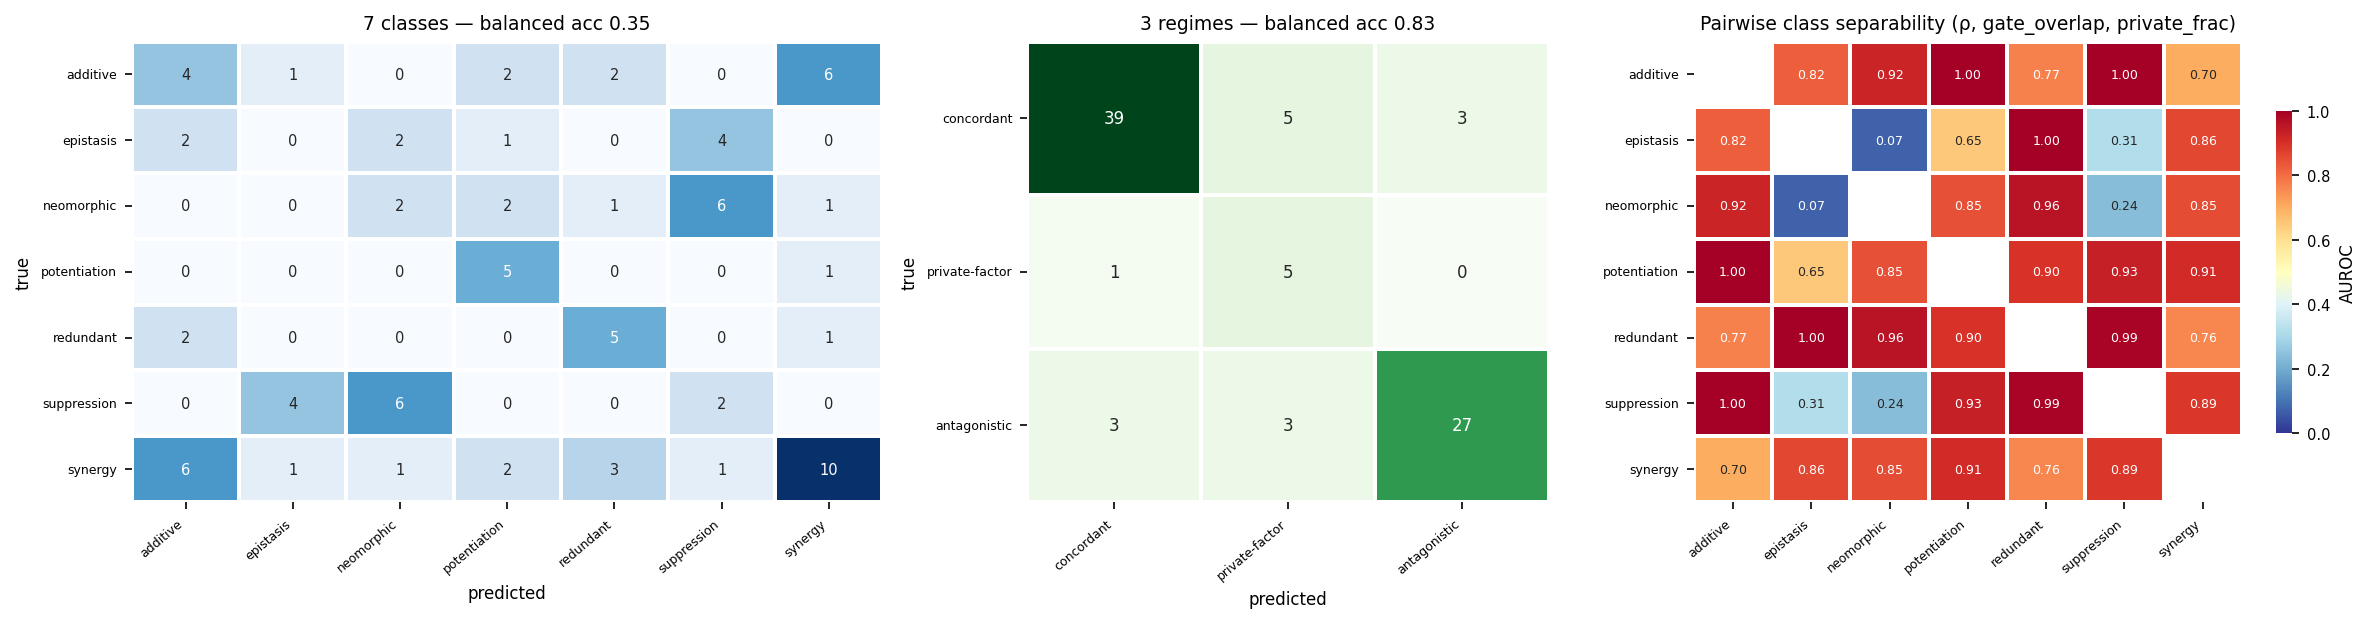

,approximately additive,epistasis,neomorphic,potentiation,redundant,suppression,synergy
approximately additive,NaN,0.82,0.92,1.00,0.77,1.00,0.70
epistasis,0.82,NaN,0.07,0.65,1.00,0.31,0.86
neomorphic,0.92,0.07,NaN,0.85,0.96,0.24,0.85
potentiation,1.00,0.65,0.85,NaN,0.90,0.93,0.91
redundant,0.77,1.00,0.96,0.90,NaN,0.99,0.76
suppression,1.00,0.31,0.24,0.93,0.99,NaN,0.89
synergy,0.70,0.86,0.85,0.91,0.76,0.89,NaN


In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_auc_score

_X_COLS = ['rho', 'gate_overlap', 'private_frac', 'shared_cos', 'n_shared']
_pg = pairs_gate.dropna(subset=GATE_DESC).reset_index(drop=True)
_ai, _bi = _pg['a'].map(g2i).values, _pg['b'].map(g2i).values

def _loo_pred(cols, labels, clf=lambda: LogisticRegression(max_iter=3000, class_weight='balanced')):
    Xs = StandardScaler().fit_transform(_pg[cols].values)
    return np.array([clf().fit(Xs[tr], labels[tr]).predict(Xs[[i]])[0]
                     for i, tr in ((i, [j for j in range(len(_pg))
                                        if j != i and not ({_ai[i], _bi[i]} & {_ai[j], _bi[j]})])
                                   for i in range(len(_pg)))])

y7 = _pg['gi'].values
p7 = _loo_pred(_X_COLS, y7)
# Three interaction regimes: concordant (shared factors, same direction), private (separate
# factors), antagonistic (opposed direction).
REGIME_OF = {'redundant': 'concordant', 'synergy': 'concordant', 'approximately additive': 'concordant',
             'potentiation': 'private-factor',
             'epistasis': 'antagonistic', 'neomorphic': 'antagonistic', 'suppression': 'antagonistic'}
y3 = np.array([REGIME_OF[c] for c in y7])
p3 = _loo_pred(_X_COLS, y3)
G3 = ['concordant', 'private-factor', 'antagonistic']

print(f'7 classes : accuracy {np.mean(p7 == y7):.3f}  balanced {balanced_accuracy_score(y7, p7):.3f}  '
      f'(majority {pd.Series(y7).value_counts(normalize=True).max():.3f})')
print(f'3 regimes : accuracy {np.mean(p3 == y3):.3f}  balanced {balanced_accuracy_score(y3, p3):.3f}  '
      f'(majority {pd.Series(y3).value_counts(normalize=True).max():.3f})')

# Pairwise class separability with the three core descriptors
CORE = ['rho', 'gate_overlap', 'private_frac']
Xc = StandardScaler().fit_transform(_pg[CORE].values)
sep = pd.DataFrame(index=GI_ORDER, columns=GI_ORDER, dtype=float)
for c1, c2 in combinations(GI_ORDER, 2):
    m = np.where((y7 == c1) | (y7 == c2))[0]
    yy = (y7[m] == c2).astype(int)
    _scores = [LinearDiscriminantAnalysis().fit(np.delete(Xc[m], i, 0), np.delete(yy, i)).decision_function(Xc[m][[i]])[0]
          for i in range(len(m))]
    sep.loc[c1, c2] = sep.loc[c2, c1] = roc_auc_score(yy, _scores)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={'width_ratios': [1.15, 0.8, 1.05]})
cm7 = confusion_matrix(y7, p7, labels=GI_ORDER)
sns.heatmap(cm7, cmap='Blues', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[0])
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')
axes[0].set_title(f'7 classes — balanced acc {balanced_accuracy_score(y7, p7):.2f}')
cm3 = confusion_matrix(y3, p3, labels=G3)
sns.heatmap(cm3, cmap='Greens', annot=True, fmt='d', annot_kws={'fontsize': 8}, linewidths=1, linecolor='white',
            xticklabels=G3, yticklabels=G3, cbar=False, ax=axes[1])
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
axes[1].set_title(f'3 regimes — balanced acc {balanced_accuracy_score(y3, p3):.2f}')
sns.heatmap(sep.astype(float), cmap='RdYlBu_r', center=0.5, vmin=0, vmax=1, annot=True, fmt='.2f',
            annot_kws={'fontsize': 6}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER],
            cbar_kws={'label': 'AUROC', 'shrink': 0.7}, ax=axes[2])
axes[2].set_title('Pairwise class separability (ρ, gate_overlap, private_frac)')
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
fig.savefig(OUT_DIR / 'class_separability.svg', bbox_inches='tight')
plt.show()
sep.astype(float).round(2)

### 9d. Can W be aligned across runs?

Latent dimensions are arbitrary per run: they can permute and flip sign, so W matrices cannot be
averaged elementwise as they stand. Two things make the analysis above valid anyway:

1. every gate descriptor is a *pair* statistic computed **within** a run (which factors two
   perturbations share), which is invariant to permuting or flipping the axes; only these
   per-run values are averaged;
2. factors can nonetheless be matched across runs by their **decoded gene-space signature** —
   the expression change produced by moving along that latent axis, which lives in a shared,
   run-independent gene space. Matching is a Hungarian assignment on |cosine| of those signatures.

The cell below quantifies how well factors match, which factors are reproducible, and whether
building the descriptors from aligned-and-averaged W beats averaging the per-run descriptors.

In [34]:
from scipy.optimize import linear_sum_assignment

SIG_PATH = FEAT_DIR / 'factor_signatures.npz'
if not SIG_PATH.exists():
    import torch
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    _d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
    _d.X = _d.layers['counts'].copy()
    slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
    _lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
    _d = _d[:, (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))].copy()
    _i = np.random.default_rng(0).choice(np.where(_lab == slk.configs.get_config('ntc_label'))[0], N_NTC_BG, replace=False)
    _x = torch.tensor(_d.X[_i].toarray(), dtype=torch.float32, device=DEVICE)
    sigs = []
    for run in range(1, N_RUNS + 1):
        m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
        with torch.no_grad():
            sh = m._get_all_pert_shifts(DEVICE)[1:]
            u = m._abduct_ntc(_x)
            delta = float(sh[:, 0].abs()[sh[:, 1] > GATE_THR].median())   # typical per-factor shift size
            vs = []
            for k in range(m.latent_dim):
                e = torch.zeros(m.latent_dim, device=DEVICE); e[k] = delta
                vp = torch.log1p(m._decode_to_expr(u + e, 1.) * 1e4).mean(0)
                vm = torch.log1p(m._decode_to_expr(u - e, 1.) * 1e4).mean(0)
                vs.append(((vp - vm) / 2).cpu().numpy())
        sigs.append(np.stack(vs))
        del m
    np.savez_compressed(SIG_PATH, V=np.stack(sigs))
    del _d

V = np.load(SIG_PATH)['V']                      # (runs, d, G) decoded signature of each latent factor
LD = V.shape[1]
_nrm = lambda A: A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
rng_m = np.random.default_rng(0)
perm = np.tile(np.arange(LD), (N_RUNS, 1)); sign = np.ones((N_RUNS, LD))
match_rows = []
for r in range(1, N_RUNS):
    Cm = _nrm(V[0]) @ _nrm(V[r]).T
    ri, ci = linear_sum_assignment(-np.abs(Cm))
    perm[r, ri] = ci; sign[r, ri] = np.sign(Cm[ri, ci])
    match_rows.append({'pair': f'run1–run{r+1}', 'mean |cos| matched': np.abs(Cm[ri, ci]).mean(),
                       'mean |cos| random match': np.abs(Cm)[rng_m.permutation(LD), np.arange(LD)].mean()})
print(pd.DataFrame(match_rows).round(3).to_string(index=False))

W_al = np.stack([feat_runs[r]['W'][:, perm[r]] for r in range(N_RUNS)])
S_al = np.stack([feat_runs[r]['S'][:, perm[r]] * sign[r] for r in range(N_RUNS)])
fac_repro = np.array([np.mean([np.corrcoef(W_al[i][:, k], W_al[j][:, k])[0, 1] for i, j in pairs]) for k in range(LD)])
print(f'\nFactors whose usage across perturbations reproduces across runs (corr >= 0.3): '
      f'{(fac_repro >= 0.3).sum()} / {LD}')
print('per-factor cross-run usage correlation:', np.round(np.sort(fac_repro)[::-1], 2))

# Does building the descriptors from aligned+averaged W beat averaging the per-run descriptors?
ia, ib = IU
def _ov(Wm):
    act = Wm > GATE_THR
    return (act[ia] & act[ib]).sum(1) / ((act[ia] | act[ib]).sum(1) + 1e-8)
def _priv(Wm, Sm):
    act = Wm > GATE_THR
    pa = ((~act[ib]) * Sm[ia] ** 2).sum(1) / ((Sm[ia] ** 2).sum(1) + 1e-8)
    pb = ((~act[ia]) * Sm[ib] ** 2).sum(1) / ((Sm[ib] ** 2).sum(1) + 1e-8)
    return (pa + pb) / 2

h1, h2 = [0, 1], [2, 3, 4]      # split-half over runs
rows = []
for nm, f_align, f_avg in [
        ('gate_overlap', lambda rs: _ov(W_al[rs].mean(0)), lambda rs: np.mean([_ov(feat_runs[r]['W']) for r in rs], 0)),
        ('private_frac', lambda rs: _priv(W_al[rs].mean(0), S_al[rs].mean(0)),
                          lambda rs: np.mean([_priv(feat_runs[r]['W'], feat_runs[r]['S']) for r in rs], 0))]:
    rows.append({'descriptor': nm,
                 'split-half r (aligned W, then average)': spearmanr(f_align(h1), f_align(h2))[0],
                 'split-half r (average per-run values)': spearmanr(f_avg(h1), f_avg(h2))[0]})
print()
print(pd.DataFrame(rows).round(3).to_string(index=False))

# Is the signal present in a single run, or only after averaging?
_single = []
for r in range(N_RUNS):
    tmp = gp[['combination']].copy()
    tmp['gate_overlap'] = _ov(feat_runs[r]['W'])
    tmp['private_frac'] = _priv(feat_runs[r]['W'], feat_runs[r]['S'])
    t = pairs_df[['combination', 'gi']].merge(tmp, on='combination')
    row = {'run': r + 1}
    for c in ['potentiation', 'redundant', 'synergy']:
        m = t['gi'] == c
        row[f'AUROC private_frac | {short[c]}'] = mannwhitneyu(t.loc[m, 'private_frac'], t.loc[~m, 'private_frac']).statistic / (m.sum() * (~m).sum())
        row[f'AUROC gate_overlap | {short[c]}'] = mannwhitneyu(t.loc[m, 'gate_overlap'], t.loc[~m, 'gate_overlap']).statistic / (m.sum() * (~m).sum())
    _single.append(row)
pd.DataFrame(_single).set_index('run').round(2)

     pair  mean |cos| matched  mean |cos| random match
run1–run2               0.647                    0.119
run1–run3               0.740                    0.150
run1–run4               0.702                    0.148
run1–run5               0.728                    0.185

Factors whose usage across perturbations reproduces across runs (corr >= 0.3): 7 / 16
per-factor cross-run usage correlation: [0.71 0.7  0.34 0.32 0.32 0.3  0.3  0.29 0.25 0.24 0.21 0.11 0.09 0.04
 0.04 0.03]

  descriptor  split-half r (aligned W, then average)  split-half r (average per-run values)
gate_overlap                                   0.506                                  0.620
private_frac                                   0.493                                  0.562


,AUROC private_frac | potentiation,AUROC gate_overlap | potentiation,AUROC private_frac | redundant,AUROC gate_overlap | redundant,AUROC private_frac | synergy,AUROC gate_overlap | synergy
run,,,,,,
1,0.98,0.09,0.12,0.83,0.50,0.68
2,0.78,0.17,0.20,0.73,0.46,0.68
3,0.78,0.20,0.39,0.72,0.39,0.66
4,0.88,0.17,0.31,0.63,0.50,0.58
5,0.93,0.24,0.18,0.80,0.47,0.68


# Part III — From model components to interactions to modules

Putting the pieces together. Each component of the trained model answers a different question about
a pair of perturbations, and an interaction class is a *signature across components* rather than a
threshold on any one of them:

| Component | Question it answers | Pair descriptor |
|---|---|---|
| ρ (learned covariance) | do they move the latent state the same way? | `rho`, `concordance` |
| W (gate) | which latent factors does each one use? | `gate_overlap`, `private_frac` |
| A ⊙ W → decoder | what does each one do to gene programs? | effect profiles, EV |
| c_a, c_b (parent scales) | is the pair damped or amplified? | `c_mean`, `syn_coef_asym` |
| syn MLP | what new direction appears, outside the parent plane? | `syn_rel`, `syn_orth_frac`, `syn_perp_novelgene` |

Section 10 assembles all of them, then feeds them back to the module level. Modules so far come from
ρ alone ("perturbations that do the same thing"); §10c adds a second layer from W
("perturbations that use the same machinery") and tests whether crossing the two explains
interactions better than either on its own.

In [35]:
# ── Parent scales and the synergy direction, for every gene pair ─────────
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ia_t, ib_t = IU

_d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
_d.X = _d.layers['counts'].copy()
slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
_lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
_d = _d[:, (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))].copy()
_i = np.random.default_rng(0).choice(np.where(_lab == slk.configs.get_config('ntc_label'))[0], 512, replace=False)
x_bg = torch.tensor(_d.X[_i].toarray(), dtype=torch.float32, device=DEVICE)

syn_feats, syn_axes_runs, syn_vecs_runs = [], [], []
for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        shifts = m._get_all_pert_shifts(DEVICE)[1:]
        S_, W_, q_ = shifts[:, 0], shifts[:, 1], shifts[:, 2]
        u = m._abduct_ntc(x_bg)
        _ln = lambda z: torch.log1p(m._decode_to_expr(z, 1.) * 1e4).mean(0)
        base = _ln(u)
        Dm = torch.stack([_ln(u + S_[k]) - base for k in range(P)])
        hi = torch.quantile(Dm.abs(), 0.9, dim=1, keepdim=True)          # genes each perturbation moves
        act_gene = Dm.abs() > hi

        A_i = torch.as_tensor(ia_t, device=DEVICE); B_i = torch.as_tensor(ib_t, device=DEVICE)
        c_a, c_b = m._parent_scales_from_rho(q_[A_i], q_[B_i])
        syn = m._synergy_shift_from_rho(q_[A_i], q_[B_i])
        Sa, Sb = S_[A_i], S_[B_i]
        add = Sa + Sb
        Bas = torch.stack([Sa, Sb], -1)                                   # parent plane
        coef = torch.linalg.lstsq(Bas, syn.unsqueeze(-1)).solution.squeeze(-1)
        par = (Bas @ coef.unsqueeze(-1)).squeeze(-1)
        perp = syn - par
        _cos = lambda x, y: (x * y).sum(1) / (x.norm(dim=1) * y.norm(dim=1) + 1e-8)

        novel = torch.empty(len(ia_t), device=DEVICE)
        for s in range(0, len(ia_t), 64):
            pv = perp[s:s + 64]
            z = u[None] + pv[:, None]
            g = torch.log1p(m._decode_to_expr(z.reshape(-1, z.shape[-1]), 1.) * 1e4).reshape(len(pv), x_bg.shape[0], -1).mean(1) - base
            msk = ~(act_gene[A_i[s:s + 64]] | act_gene[B_i[s:s + 64]])    # genes neither parent moves
            novel[s:s + 64] = (g.pow(2) * msk).sum(1) / (g.pow(2).sum(1) + 1e-9)

        syn_feats.append(pd.DataFrame({
            'c_mean': ((c_a + c_b) / 2).squeeze(-1).cpu().numpy(),
            'syn_coef_asym': (coef[:, 0] - coef[:, 1]).abs().cpu().numpy(),
            'syn_rel': (syn.norm(dim=1) / (add.norm(dim=1) + 1e-8)).cpu().numpy(),
            'syn_orth_frac': (perp.norm(dim=1) / (syn.norm(dim=1) + 1e-8)).cpu().numpy(),
            'syn_par_cos_add': _cos(par, add).cpu().numpy(),
            'syn_perp_novelgene': novel.cpu().numpy()}))

        # shared interaction axes: principal directions of the synergy vectors over all pairs
        sc_syn = syn - syn.mean(0)
        U_, Sv, Vt = torch.linalg.svd(sc_syn, full_matrices=False)
        ev = (Sv ** 2 / (Sv ** 2).sum()).cpu().numpy()
        delta = float(S_.abs()[shifts[:, 1] > GATE_THR].median())
        ax_sig = torch.stack([_ln(u + delta * Vt[k]) - base for k in range(5)])   # decoded axis signatures
        syn_axes_runs.append({'evr': ev, 'axes': Vt[:5].cpu().numpy(), 'sig': ax_sig.cpu().numpy(),
                              'load': (sc_syn @ Vt[:5].T).cpu().numpy()})
    del m
    torch.cuda.empty_cache()
del _d, x_bg

SYN_DESC = list(syn_feats[0].columns)
for c in SYN_DESC:
    gp[c] = np.mean([f[c].values for f in syn_feats], 0)
_merge_cols = list(dict.fromkeys(['combination'] + DESC + GATE_DESC + SYN_DESC))
pairs_all = pairs_df.merge(gp[_merge_cols], on='combination', how='left')
print('synergy-direction descriptors (mean over runs), by class:')
pairs_all.groupby('gi')[SYN_DESC].mean().reindex(GI_ORDER).round(3)

synergy-direction descriptors (mean over runs), by class:


,c_mean,syn_coef_asym,syn_rel,syn_orth_frac,syn_par_cos_add,syn_perp_novelgene
gi,,,,,,
approximately additive,0.821,0.240,0.206,0.727,0.826,0.640
epistasis,0.673,0.397,0.356,0.602,0.773,0.641
neomorphic,0.758,0.306,0.354,0.674,0.769,0.622
potentiation,0.880,0.408,0.419,0.746,0.957,0.586
redundant,0.650,0.698,0.260,0.640,0.821,0.687
suppression,0.646,0.185,0.399,0.620,0.891,0.575
synergy,0.861,0.350,0.327,0.729,0.874,0.644


### 10a. One fingerprint per interaction class, and what each component buys

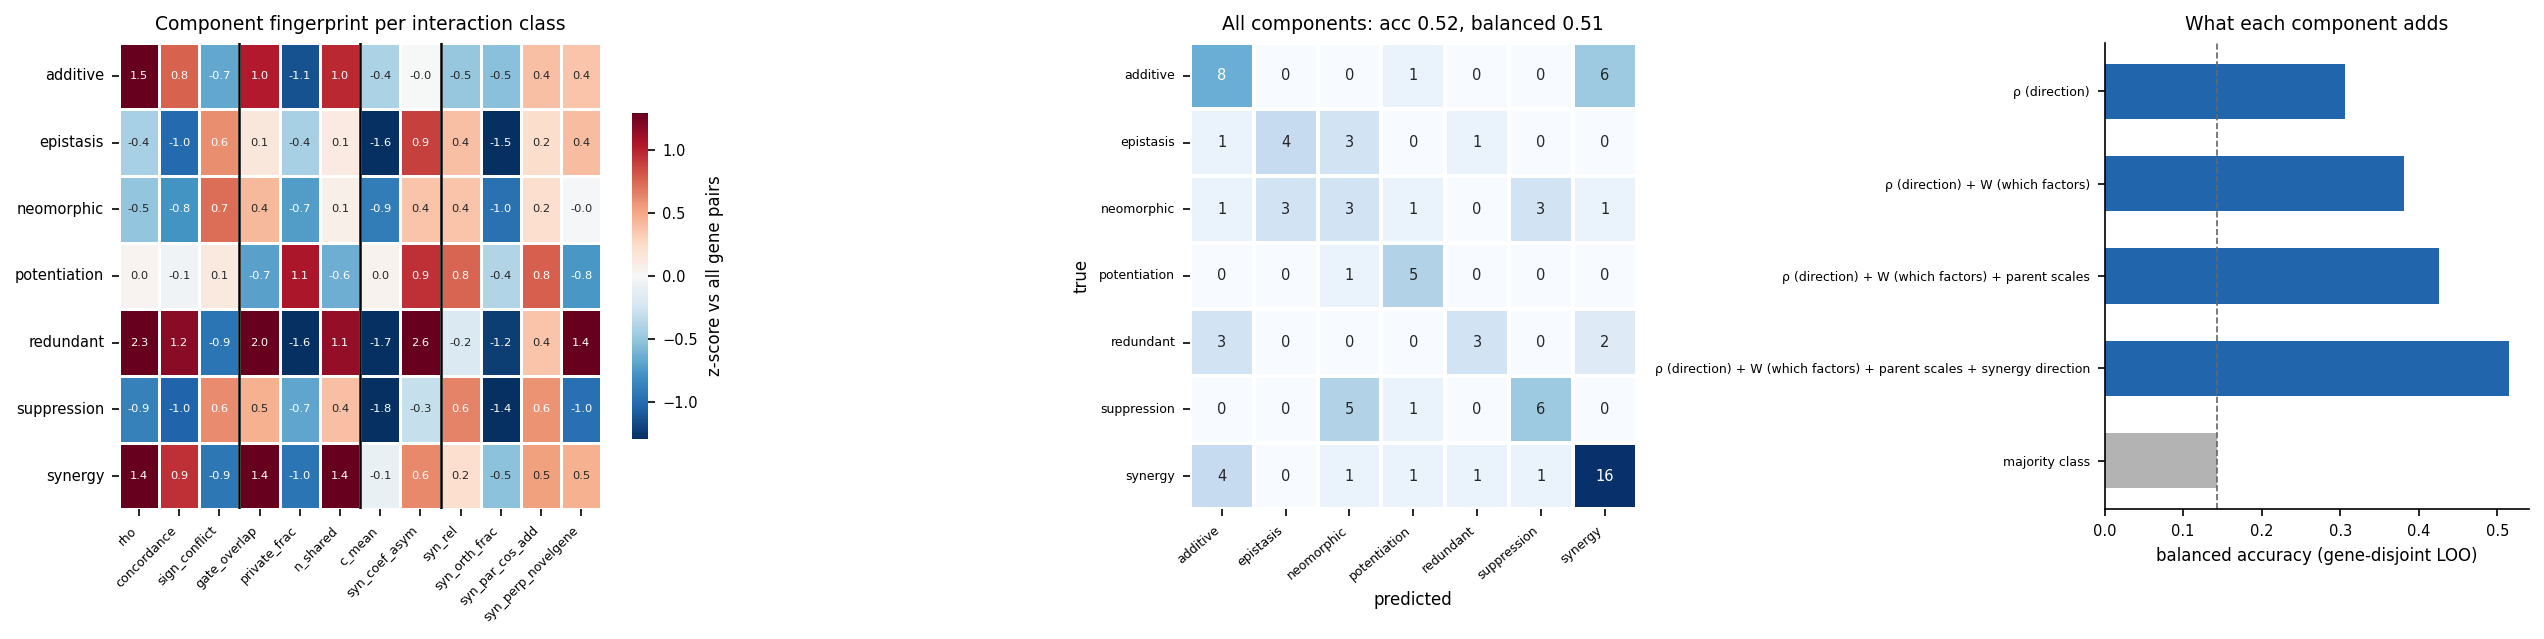

,components,n_features,accuracy,balanced accuracy
0,ρ (direction),3,0.326,0.306
1,ρ (direction) + W (which factors),6,0.384,0.381
2,ρ (direction) + W (which factors) + parent scales,8,0.442,0.425
3,ρ (direction) + W (which factors) + parent scales + synergy direction,12,0.523,0.515
4,majority class,0,0.279,0.143


In [36]:
COMPONENTS = {
    'ρ (direction)':      ['rho', 'concordance', 'sign_conflict'],
    'W (which factors)':  ['gate_overlap', 'private_frac', 'n_shared'],
    'parent scales':      ['c_mean', 'syn_coef_asym'],
    'synergy direction':  ['syn_rel', 'syn_orth_frac', 'syn_par_cos_add', 'syn_perp_novelgene'],
}
ALL_DESC = [c for v in COMPONENTS.values() for c in v]
fp = ((pairs_all.groupby('gi')[ALL_DESC].mean().reindex(GI_ORDER) - gp[ALL_DESC].mean()) / gp[ALL_DESC].std())

# Ablation: what does each component add? Gene-disjoint leave-one-out over all 7 classes.
_pa = pairs_all.dropna(subset=ALL_DESC).reset_index(drop=True)
_ai2, _bi2 = _pa['a'].map(g2i).values, _pa['b'].map(g2i).values
_y = _pa['gi'].values

def _loo(cols):
    Xs = StandardScaler().fit_transform(_pa[cols].values)
    pr = []
    for i in range(len(_pa)):
        tr = [j for j in range(len(_pa)) if j != i and not ({_ai2[i], _bi2[i]} & {_ai2[j], _bi2[j]})]
        pr.append(LogisticRegression(max_iter=3000, class_weight='balanced').fit(Xs[tr], _y[tr]).predict(Xs[[i]])[0])
    pr = np.array(pr)
    return np.mean(pr == _y), balanced_accuracy_score(_y, pr), pr

abl, cum = [], []
for name, cols in COMPONENTS.items():
    cum += cols
    acc, bal, pr = _loo(cum)
    abl.append({'components': ' + '.join(list(COMPONENTS)[:len(abl) + 1]), 'n_features': len(cum),
                'accuracy': acc, 'balanced accuracy': bal})
    final_pred = pr
abl.append({'components': 'majority class', 'n_features': 0,
            'accuracy': _pa['gi'].value_counts(normalize=True).max(), 'balanced accuracy': 1 / len(GI_ORDER)})
abl_df = pd.DataFrame(abl)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={'width_ratios': [1.35, 1, 0.95]})
sns.heatmap(fp, cmap='RdBu_r', center=0, vmin=-1.3, vmax=1.3, annot=True, fmt='.1f', annot_kws={'fontsize': 5.5},
            linewidths=0.5, linecolor='white', ax=axes[0], cbar_kws={'label': 'z-score vs all gene pairs', 'shrink': 0.7},
            yticklabels=[short[c] for c in GI_ORDER])
for x in np.cumsum([len(v) for v in COMPONENTS.values()])[:-1]:
    axes[0].axvline(x, color='k', lw=1.2)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axes[0].set_ylabel(''); axes[0].set_title('Component fingerprint per interaction class')

cm = confusion_matrix(_y, final_pred, labels=GI_ORDER)
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[1])
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
axes[1].set_title(f'All components: acc {abl_df.iloc[-2]["accuracy"]:.2f}, balanced {abl_df.iloc[-2]["balanced accuracy"]:.2f}')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=6)

ax = axes[2]
ypos = np.arange(len(abl_df))
ax.barh(ypos, abl_df['balanced accuracy'], color=['#2166ac'] * (len(abl_df) - 1) + ['0.7'], height=0.6)
ax.set_yticks(ypos); ax.set_yticklabels(abl_df['components'], fontsize=6)
ax.invert_yaxis()
ax.axvline(1 / len(GI_ORDER), color='0.4', ls='--', lw=0.8)
ax.set_xlabel('balanced accuracy (gene-disjoint LOO)')
ax.set_title('What each component adds')
plt.tight_layout()
plt.show()
abl_df.round(3)

### 10b. The shared interaction axes

The synergy vectors of all 5460 pairs are not scattered over the latent space: their principal
directions form a handful of shared **interaction axes**. Each axis is decoded into gene space and
scored against the effect programs from §7b, so the model's "new directions" get a biological
reading. Module pairs are then placed on the first two axes.

variance of the synergy vectors carried by each axis: [0.347 0.247 0.157 0.107 0.068]   (top-3 = 0.75)


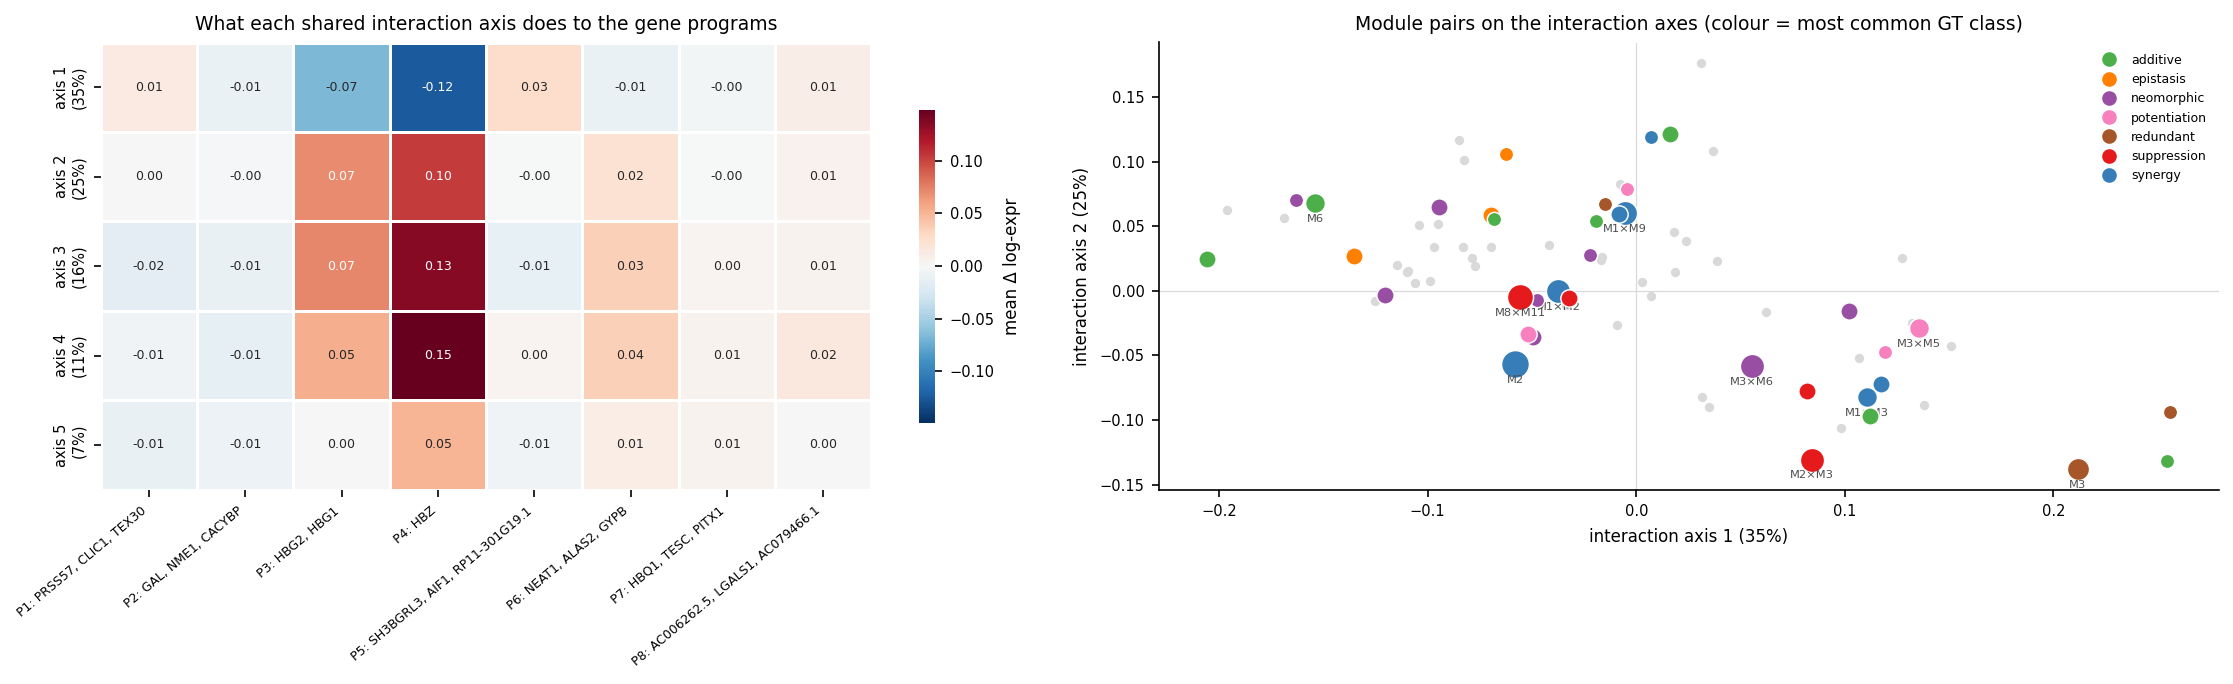

,"P1: PRSS57, CLIC1, TEX30","P2: GAL, NME1, CACYBP","P3: HBG2, HBG1",P4: HBZ,"P5: SH3BGRL3, AIF1, RP11-301G19.1","P6: NEAT1, ALAS2, GYPB","P7: HBQ1, TESC, PITX1","P8: AC006262.5, LGALS1, AC079466.1"
axis 1\n(35%),0.013,-0.010,-0.067,-0.124,0.028,-0.010,-0.004,0.009
axis 2\n(25%),0.000,-0.002,0.070,0.103,-0.001,0.022,-0.000,0.006
axis 3\n(16%),-0.015,-0.011,0.073,0.135,-0.012,0.035,0.004,0.005
axis 4\n(11%),-0.006,-0.013,0.053,0.149,0.004,0.036,0.005,0.016
axis 5\n(7%),-0.011,-0.009,0.001,0.051,-0.006,0.011,0.006,0.000


In [37]:
# Match axes across runs by their decoded gene signature (same trick as §9d), then average
_nrm2 = lambda A: A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
ref_sig = syn_axes_runs[0]['sig']
axis_sig = [ref_sig]
axis_load = [syn_axes_runs[0]['load']]
for r in range(1, N_RUNS):
    Cm = _nrm2(ref_sig) @ _nrm2(syn_axes_runs[r]['sig']).T
    ri, ci = linear_sum_assignment(-np.abs(Cm))
    sgn2 = np.sign(Cm[ri, ci])[:, None]
    axis_sig.append(syn_axes_runs[r]['sig'][ci] * sgn2)
    axis_load.append(syn_axes_runs[r]['load'][:, ci] * sgn2.T)
axis_sig = np.mean(axis_sig, 0)
axis_load = np.mean(axis_load, 0)
evr = np.mean([a['evr'][:5] for a in syn_axes_runs], 0)
print('variance of the synergy vectors carried by each axis:', np.round(evr, 3),
      f'  (top-3 = {evr[:3].sum():.2f})')

# Axis × program scores, using the programs from section 7b
axis_g = axis_sig[:, readout_mask]
prog_cols = {}
for k in sorted(prog.unique()):
    gk = [g for g in prog.index[prog == k]]
    gi_idx = [list(rnames).index(g) for g in gk]
    prog_cols[prog_names[k]] = axis_g[:, gi_idx].mean(1)
axis_prog = pd.DataFrame(prog_cols, index=[f'axis {k+1}\n({evr[k]:.0%})' for k in range(5)])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1, 1.1]})
lim = np.abs(axis_prog.values).max()
sns.heatmap(axis_prog, cmap='RdBu_r', center=0, vmin=-lim, vmax=lim, annot=True, fmt='.2f',
            annot_kws={'fontsize': 6}, linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'mean Δ log-expr', 'shrink': 0.7})
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[0].set_title('What each shared interaction axis does to the gene programs')

gp_ax = pd.DataFrame(axis_load[:, :2], columns=['axis1', 'axis2'])
gp_ax['module_pair'] = gp['module_pair'].values
gp_ax['measured'] = gp['measured_combo'].values
mp_ax = gp_ax[~gp_ax['measured']].groupby('module_pair')[['axis1', 'axis2']].mean()
ax = axes[1]
ax.scatter(mp_ax['axis1'], mp_ax['axis2'], s=12, color='0.85', zorder=1)
for name, row in mp_ax.iterrows():
    comp = pairs_df[pairs_df['module_pair'] == name]['gi'].value_counts()
    if comp.sum() == 0:
        continue
    ax.scatter(row['axis1'], row['axis2'], s=25 + 22 * comp.sum(), color=PALETTE_GI[comp.index[0]],
               edgecolor='white', lw=0.7, zorder=3)
    if comp.sum() >= 3:
        ax.annotate(name, (row['axis1'], row['axis2']), fontsize=5.5, xytext=(0, -9),
                    textcoords='offset points', ha='center', color='0.3')
ax.axhline(0, color='0.85', lw=0.6); ax.axvline(0, color='0.85', lw=0.6)
ax.set_xlabel(f'interaction axis 1 ({evr[0]:.0%})'); ax.set_ylabel(f'interaction axis 2 ({evr[1]:.0%})')
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=PALETTE_GI[c], label=short[c]) for c in GI_ORDER],
          frameon=False, fontsize=6, loc='best')
ax.set_title('Module pairs on the interaction axes (colour = most common GT class)')
plt.tight_layout()
plt.show()
axis_prog.round(3)

### 10c. Two module layers: same program vs. same machinery

ρ-modules (§3) group perturbations that *do the same thing*. Because gate overlap is almost
independent of ρ, W supports a second, complementary grouping — perturbations that *use the same
latent factors*. W-modules are built with the same consensus procedure: cluster each run's gate
profiles over k = 5..20, average the co-assignments, then cluster that.

The test: do GT pairs that share a ρ-module-pair, a W-module-pair, or both, agree on interaction
class more often than pairs matched on ρ? Pairs sharing a gene are excluded throughout.

ARI(ρ-modules, W-modules) = 0.043  (0 = unrelated groupings, 1 = identical)


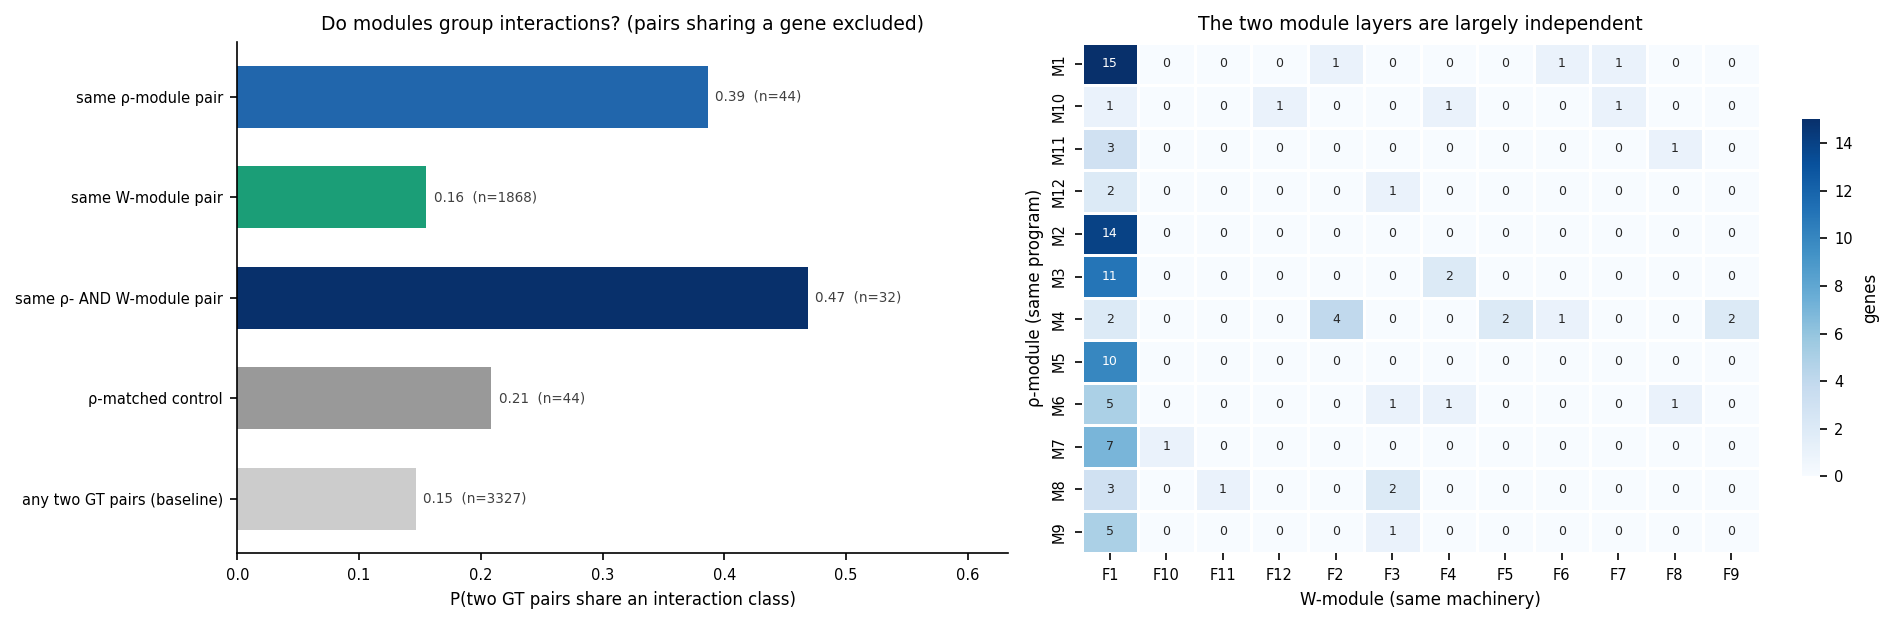

,relation,n pairs of GT pairs,same interaction class
0,same ρ-module pair,44,0.386
1,same W-module pair,1868,0.155
2,same ρ- AND W-module pair,32,0.469
3,ρ-matched control,44,0.209
4,any two GT pairs (baseline),3327,0.146


In [38]:
# W-modules by consensus over runs and resolutions
C_W = np.zeros((P, P))
for r in feat_runs:
    Wn = r['W'] / (np.linalg.norm(r['W'], axis=1, keepdims=True) + 1e-8)
    Mw = Wn @ Wn.T
    for k in K_RANGE:
        lw = cluster_corr(Mw, k, 'average')
        C_W += (lw[:, None] == lw[None, :])
C_W /= (N_RUNS * len(K_RANGE))
w_lab = cluster_corr(C_W, K_FINAL, LINKAGE_CONS)
w_module = pd.Series([f'F{n+1}' for n in pd.Series(w_lab).map(
    {old: n for n, old in enumerate(pd.Series(w_lab).value_counts().index)})], index=genes, name='w_module')
print(f'ARI(ρ-modules, W-modules) = {adjusted_rand_score(module_of, w_module):.3f}  '
      f'(0 = unrelated groupings, 1 = identical)')

gt_pairs = pairs_df.reset_index(drop=True)
gi_arr = gt_pairs['gi'].values
A_ = gt_pairs['a'].values; B_ = gt_pairs['b'].values
rho_pair = gt_pairs['rho'].values
I_, J_ = np.triu_indices(len(gt_pairs), 1)
no_share = np.array([len({A_[i], B_[i]} & {A_[j], B_[j]}) == 0 for i, j in zip(I_, J_)])
same_class = gi_arr[I_] == gi_arr[J_]

def _mp_key(lab):
    return np.array(['|'.join(sorted([lab[a], lab[b]])) for a, b in zip(A_, B_)])
rho_key, w_key = _mp_key(module_of), _mp_key(w_module)
same_rho_mp = rho_key[I_] == rho_key[J_]
same_w_mp = w_key[I_] == w_key[J_]

# control: pairs matched on rho (same quartile of mean rho and of |Δrho|)
rbar = (rho_pair[I_] + rho_pair[J_]) / 2
drho = np.abs(rho_pair[I_] - rho_pair[J_])
qb = pd.qcut(rbar[no_share], 4, labels=False, duplicates='drop')
db = pd.qcut(drho[no_share], 4, labels=False, duplicates='drop')
ctrl_rate, wsum = 0.0, 0.0
for xq in range(4):
    for xd in range(4):
        cell = np.zeros(no_share.sum(), bool)
        cell[(qb == xq) & (db == xd)] = True
        idx_ns = np.where(no_share)[0]
        sel, oth = idx_ns[cell & same_rho_mp[idx_ns]], idx_ns[cell & ~same_rho_mp[idx_ns]]
        if len(sel) and len(oth):
            ctrl_rate += len(sel) * same_class[oth].mean(); wsum += len(sel)

rows = [
    {'relation': 'same ρ-module pair',           'n pairs of GT pairs': int((no_share & same_rho_mp).sum()),
     'same interaction class': same_class[no_share & same_rho_mp].mean()},
    {'relation': 'same W-module pair',           'n pairs of GT pairs': int((no_share & same_w_mp).sum()),
     'same interaction class': same_class[no_share & same_w_mp].mean()},
    {'relation': 'same ρ- AND W-module pair',    'n pairs of GT pairs': int((no_share & same_rho_mp & same_w_mp).sum()),
     'same interaction class': same_class[no_share & same_rho_mp & same_w_mp].mean()},
    {'relation': 'ρ-matched control',            'n pairs of GT pairs': int(wsum),
     'same interaction class': ctrl_rate / wsum if wsum else np.nan},
    {'relation': 'any two GT pairs (baseline)',  'n pairs of GT pairs': int(no_share.sum()),
     'same interaction class': same_class[no_share].mean()},
]
homophily = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1, 1.1]})
ax = axes[0]
cols = ['#2166ac', '#1b9e77', '#08306b', '0.6', '0.8']
ax.barh(np.arange(len(homophily)), homophily['same interaction class'], color=cols, height=0.62)
for n, (v, k) in enumerate(zip(homophily['same interaction class'], homophily['n pairs of GT pairs'])):
    ax.text(v + 0.006, n, f'{v:.2f}  (n={k})', va='center', fontsize=6.5, color='0.25')
ax.set_yticks(np.arange(len(homophily))); ax.set_yticklabels(homophily['relation'], fontsize=7)
ax.invert_yaxis(); ax.set_xlim(0, max(homophily['same interaction class']) * 1.35)
ax.set_xlabel('P(two GT pairs share an interaction class)')
ax.set_title('Do modules group interactions? (pairs sharing a gene excluded)')

ct2 = pd.crosstab(module_of, w_module)
sns.heatmap(ct2, cmap='Blues', annot=True, fmt='d', annot_kws={'fontsize': 6}, linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'genes', 'shrink': 0.7}, ax=axes[1])
axes[1].set_xlabel('W-module (same machinery)'); axes[1].set_ylabel('ρ-module (same program)')
axes[1].set_title('The two module layers are largely independent')
plt.tight_layout()
plt.show()
homophily.round(3)

### 10d. Module-pair rule table

In [39]:
# Every module pair with GT pairs: its component fingerprint, and what was actually observed
RULE_DESC = ['rho', 'gate_overlap', 'private_frac', 'c_mean', 'syn_orth_frac', 'syn_perp_novelgene']
mp_fp = gp[~gp['measured_combo']].groupby('module_pair')[RULE_DESC].mean()

def _rule(r):
    # Read the component fingerprint as a sentence, using medians over module pairs as cut points
    hi_rho = r['rho'] > mp_fp['rho'].median()
    hi_gate = r['gate_overlap'] > mp_fp['gate_overlap'].median()
    lo_c = r['c_mean'] < mp_fp['c_mean'].median()
    novel = r['syn_perp_novelgene'] > mp_fp['syn_perp_novelgene'].median()
    if hi_rho and hi_gate:
        return 'same program, shared factors → redundant / synergy / additive'
    if not hi_gate and not lo_c:
        return 'private factors, undamped → potentiation / additive'
    if lo_c and not novel:
        return 'damped, new direction on the parents’ own genes → suppression'
    if novel and not hi_rho:
        return 'new direction on other genes → neomorphic / epistasis'
    return 'mixed'

rule_tbl = (pairs_df.groupby('module_pair')
            .agg(n=('gi', 'size'),
                 observed=('gi', lambda s: ', '.join(f'{k}:{v}' for k, v in s.value_counts().items())))
            .join(mp_fp))
rule_tbl['fingerprint says'] = rule_tbl.apply(_rule, axis=1)
rule_tbl = rule_tbl.sort_values(['n', 'rho'], ascending=[False, False])
rule_tbl[['n', 'observed', 'fingerprint says'] + RULE_DESC].round(3)

,n,observed,fingerprint says,rho,gate_overlap,private_frac,c_mean,syn_orth_frac,syn_perp_novelgene
module_pair,,,,,,,,,
M2,7,"synergy:5, approximately additive:2","same program, shared factors → redundant / synergy / additive",0.540,0.633,0.152,0.941,0.846,0.653
M8×M11,6,"suppression:4, neomorphic:1, epistasis:1","damped, new direction on the parents’ own genes → suppression",0.112,0.440,0.320,0.869,0.826,0.608
M1×M2,5,"synergy:4, approximately additive:1","same program, shared factors → redundant / synergy / additive",0.305,0.543,0.223,0.877,0.814,0.637
M1×M9,5,"synergy:4, approximately additive:1","same program, shared factors → redundant / synergy / additive",0.163,0.523,0.279,0.858,0.828,0.617
M2×M3,5,"suppression:4, neomorphic:1",mixed,0.009,0.532,0.227,0.878,0.796,0.583
M3×M6,5,"neomorphic:3, epistasis:2","damped, new direction on the parents’ own genes → suppression",-0.194,0.478,0.330,0.858,0.767,0.597
M3,4,redundant:4,"same program, shared factors → redundant / synergy / additive",0.471,0.505,0.259,0.834,0.753,0.609
M6,3,"approximately additive:2, redundant:1","same program, shared factors → redundant / synergy / additive",0.171,0.518,0.292,0.871,0.744,0.629
M3×M5,3,"potentiation:2, synergy:1",new direction on other genes → neomorphic / epistasis,0.083,0.514,0.289,0.858,0.736,0.624


### 10e. Tier-1 additions: four more model components

Four components of the trained model that the descriptors so far ignore:

1. **Partial correlation.** ρ is a *marginal* correlation from Σ_P. Its precision matrix
   Θ = Σ_P⁻¹ gives the **direct** coupling with mediation through other perturbations removed.
   Epistasis ("A acts *through* B") should show marginal coupling without direct coupling, so
   `rho_minus_pcorr` is the mediation index.
2. **Classifier head.** `cls_head` was trained to name the perturbations behind a latent state.
   Applied to the predicted combination, it says whether the model still *recognises* each parent:
   dominance keeps one parent, a novel state keeps neither.
3. **Nearest-single identity.** How close the predicted combination lands to every *other* single
   perturbation's effect — a combination that resembles nothing else is neomorphic by definition.
4. **Program saturation.** Per-program ratio ‖combo‖ / ‖additive‖ on the programs from §7b.
   Since the interaction axes are erythroid modulation (§10b), the interesting question is whether
   that specific program saturates (suppression) or another program appears (neomorphic).

In [40]:
import pyro
T1_PCORR = ['pcorr', 'rho_minus_pcorr']
T1_CLS   = ['cls_min_parent', 'cls_parent_gap', 'cls_best_other']
T1_NN    = ['nn_other_cos', 'nn_parent_cos', 'nn_parent_minus_other']
prog_ids = sorted(prog.unique())
T1_PROG  = [f'sat_P{k}' for k in prog_ids]
TIER1 = T1_PCORR + T1_CLS + T1_NN + T1_PROG

_d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
_d.X = _d.layers['counts'].copy()
slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
_lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
_d = _d[:, (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))].copy()
_i = np.random.default_rng(0).choice(np.where(_lab == slk.configs.get_config('ntc_label'))[0], 512, replace=False)
x_bg = torch.tensor(_d.X[_i].toarray(), dtype=torch.float32, device=DEVICE)
prog_idx = {k: np.where(np.isin(var_names, list(prog.index[prog == k])))[0] for k in prog_ids}
gt_a = pairs_df['a'].map(g2i).values
gt_b = pairs_df['b'].map(g2i).values

t1_runs = []
for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        # --- (1) precision matrix of the learned perturbation covariance ---
        Lq = m.qr().cpu()
        sig = pyro.param('sigma_fac').detach().cpu()
        Sig = Lq @ Lq.T + sig ** 2 * torch.eye(Lq.shape[0])
        Th = torch.linalg.inv(Sig.double())
        dth = torch.sqrt(torch.diag(Th))
        pcorr_m = (-Th / torch.outer(dth, dth)).numpy()

        shifts = m._get_all_pert_shifts(DEVICE)[1:]
        S_, W_, q_ = shifts[:, 0], shifts[:, 1], shifts[:, 2]
        u = m._abduct_ntc(x_bg)
        _ln = lambda z: torch.log1p(m._decode_to_expr(z, 1.) * 1e4).mean(0)
        base = _ln(u)
        Dm = torch.stack([_ln(u + S_[k]) - base for k in range(P)])
        Dn = Dm / (Dm.norm(dim=1, keepdim=True) + 1e-8)

        rows = []
        for n, (i, j) in enumerate(zip(gt_a, gt_b)):
            ca, cb = m._parent_scales_from_rho(q_[[i]], q_[[j]])
            syn = m._synergy_shift_from_rho(q_[[i]], q_[[j]])
            shift_ab = (ca * S_[i] + cb * S_[j] + syn).squeeze(0)
            z = u + shift_ab
            d_ab = _ln(z) - base
            add = Dm[i] + Dm[j]

            # (2) does the classifier still recognise each parent?
            pr = m.cls_head(z).sigmoid().mean(0)
            others = torch.ones(P, dtype=torch.bool, device=DEVICE); others[[i, j]] = False
            # (3) what does the combination look like, among all singles?
            cos_all = (Dn @ (d_ab / (d_ab.norm() + 1e-8)))
            nn_other = float(cos_all[others].max())
            nn_par = float(max(cos_all[i], cos_all[j]))
            r = {'pcorr': pcorr_m[i, j], 'rho_minus_pcorr': float(R[:, i, j].mean() - pcorr_m[i, j]),
                 'cls_min_parent': float(min(pr[i], pr[j])), 'cls_parent_gap': float(abs(pr[i] - pr[j])),
                 'cls_best_other': float(pr[others].max()),
                 'nn_other_cos': nn_other, 'nn_parent_cos': nn_par, 'nn_parent_minus_other': nn_par - nn_other}
            # (4) per-program saturation of the combination vs the additive expectation.
            # Log-ratio with a floor on the denominator: when two parents cancel on a program the
            # raw ratio explodes (the additive norm goes to ~0), which swamps the feature.
            floor = 0.05 * float(add.norm()) / np.sqrt(len(prog_ids))
            for k in prog_ids:
                gidx = prog_idx[k]
                r[f'sat_P{k}'] = float(np.clip(np.log2((float(d_ab[gidx].norm()) + floor) /
                                                       (float(add[gidx].norm()) + floor)), -4, 4))
            rows.append(r)
        t1_runs.append(pd.DataFrame(rows))
    del m
    torch.cuda.empty_cache()
del _d, x_bg

t1 = sum(t1_runs) / len(t1_runs)
for c in TIER1:
    pairs_all[c] = t1[c].values
print('Tier-1 descriptors by class (P3/P4 are the erythroid programs):')
pairs_all.groupby('gi')[T1_PCORR + T1_CLS + T1_NN + ['sat_P3', 'sat_P4']].mean().reindex(GI_ORDER).round(3)

Tier-1 descriptors by class (P3/P4 are the erythroid programs):


,pcorr,rho_minus_pcorr,cls_min_parent,cls_parent_gap,cls_best_other,nn_other_cos,nn_parent_cos,nn_parent_minus_other,sat_P3,sat_P4
gi,,,,,,,,,,
approximately additive,0.047,0.498,0.316,0.306,0.178,0.877,0.916,0.040,0.090,-0.184
epistasis,-0.000,-0.001,0.251,0.312,0.206,0.847,0.937,0.090,0.307,0.067
neomorphic,-0.010,-0.015,0.141,0.211,0.153,0.830,0.856,0.026,0.251,0.114
potentiation,-0.001,0.129,0.131,0.565,0.185,0.832,0.911,0.079,0.452,0.140
redundant,0.113,0.645,0.211,0.267,0.172,0.894,0.962,0.068,-0.097,-0.411
suppression,0.001,-0.127,0.265,0.201,0.228,0.856,0.744,-0.112,-0.058,-0.397
synergy,0.018,0.481,0.185,0.201,0.187,0.947,0.940,-0.008,0.055,0.074


In [41]:
# ── Re-run the ablation with the tier-1 families ─────────────────────────
BASE = ALL_DESC
FAMILIES = {'+ partial correlation': T1_PCORR, '+ classifier head': T1_CLS,
            '+ nearest single': T1_NN, '+ program saturation': T1_PROG}

_pa2 = pairs_all.dropna(subset=BASE + TIER1).reset_index(drop=True)
_a2, _b2 = _pa2['a'].map(g2i).values, _pa2['b'].map(g2i).values
_y2 = _pa2['gi'].values
REGIME_OF = {'redundant': 'concordant', 'synergy': 'concordant', 'approximately additive': 'concordant',
             'potentiation': 'private-factor',
             'epistasis': 'antagonistic', 'neomorphic': 'antagonistic', 'suppression': 'antagonistic'}
_y2r = np.array([REGIME_OF[c] for c in _y2])

def _folds():
    for i in range(len(_pa2)):
        yield i, [j for j in range(len(_pa2)) if j != i and not ({_a2[i], _b2[i]} & {_a2[j], _b2[j]})]

def loo_flat(cols, labels=None):
    labels = _y2 if labels is None else labels
    Xs = StandardScaler().fit_transform(_pa2[cols].values)
    pr = [LogisticRegression(max_iter=4000, class_weight='balanced').fit(Xs[tr], labels[tr]).predict(Xs[[i]])[0]
          for i, tr in _folds()]
    return np.array(pr)

def loo_two_stage(cols):
    # stage 1: which regime; stage 2: which class inside the predicted regime
    Xs = StandardScaler().fit_transform(_pa2[cols].values)
    out = []
    for i, tr in _folds():
        s1 = LogisticRegression(max_iter=4000, class_weight='balanced').fit(Xs[tr], _y2r[tr])
        reg = s1.predict(Xs[[i]])[0]
        mem = [j for j in tr if _y2r[j] == reg]
        sub = np.unique(_y2[mem])
        out.append(sub[0] if len(sub) < 2 else
                   LogisticRegression(max_iter=4000, class_weight='balanced').fit(Xs[mem], _y2[mem]).predict(Xs[[i]])[0])
    return np.array(out)

rows, preds = [], {}
for name, cols in [('base (ρ + W + scales + syn)', BASE)] + \
                  [(n, BASE + f) for n, f in FAMILIES.items()] + \
                  [('base + all tier 1', BASE + TIER1)]:
    pr = loo_flat(cols)
    preds[name] = pr
    rows.append({'feature set': name, 'n_features': len(cols), 'accuracy': np.mean(pr == _y2),
                 'balanced accuracy': balanced_accuracy_score(_y2, pr)})
best_name = max(rows[1:], key=lambda r: r['balanced accuracy'])['feature set']
best_cols = BASE + (TIER1 if best_name == 'base + all tier 1' else FAMILIES[best_name])
pr2 = loo_two_stage(best_cols)
preds['two-stage on best set'] = pr2
rows.append({'feature set': f'two-stage ({best_name})', 'n_features': len(best_cols),
             'accuracy': np.mean(pr2 == _y2), 'balanced accuracy': balanced_accuracy_score(_y2, pr2)})
rows.append({'feature set': 'majority class', 'n_features': 0,
             'accuracy': pd.Series(_y2).value_counts(normalize=True).max(), 'balanced accuracy': 1 / len(GI_ORDER)})
abl2 = pd.DataFrame(rows)
print(f'Best single addition: {best_name}')
abl2.round(3)

Best single addition: + partial correlation


,feature set,n_features,accuracy,balanced accuracy
0,base (ρ + W + scales + syn),12,0.523,0.515
1,+ partial correlation,14,0.558,0.547
2,+ classifier head,15,0.488,0.448
3,+ nearest single,15,0.512,0.463
4,+ program saturation,20,0.442,0.427
5,base + all tier 1,28,0.535,0.510
6,two-stage (+ partial correlation),14,0.500,0.487
7,majority class,0,0.279,0.143


/var/tmp/ipykernel_2020546/2961487881.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', fontsize=6)


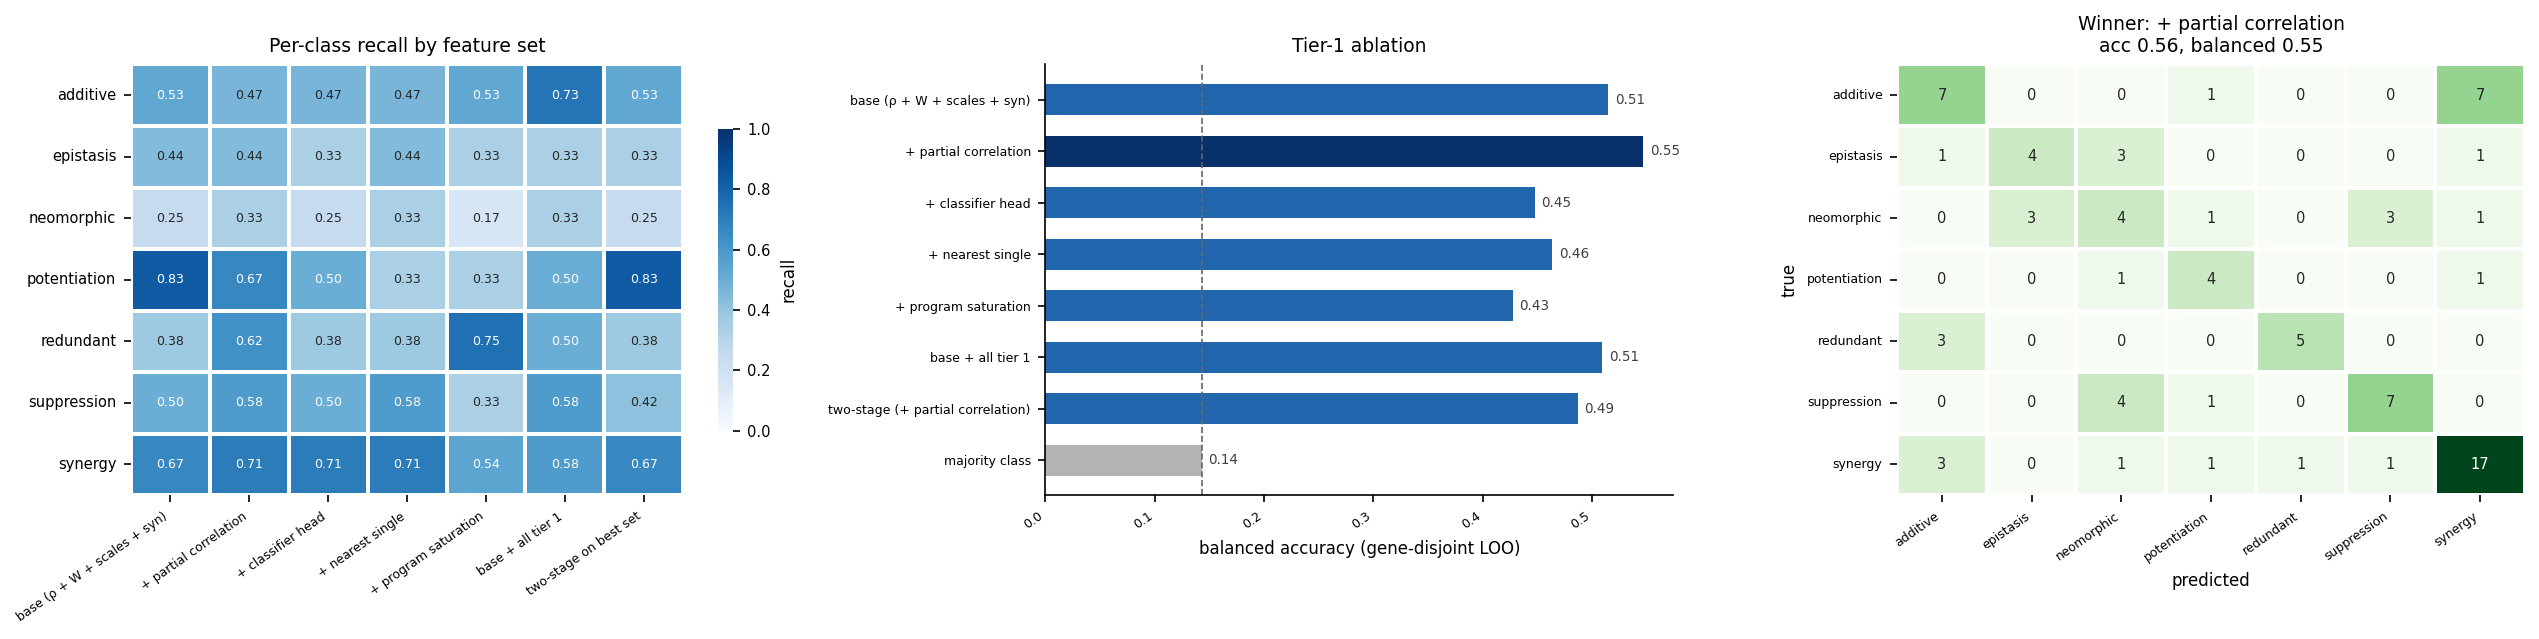

,base (ρ + W + scales + syn),+ partial correlation,+ classifier head,+ nearest single,+ program saturation,base + all tier 1,two-stage on best set
approximately additive,0.53,0.47,0.47,0.47,0.53,0.73,0.53
epistasis,0.44,0.44,0.33,0.44,0.33,0.33,0.33
neomorphic,0.25,0.33,0.25,0.33,0.17,0.33,0.25
potentiation,0.83,0.67,0.50,0.33,0.33,0.50,0.83
redundant,0.38,0.62,0.38,0.38,0.75,0.50,0.38
suppression,0.50,0.58,0.50,0.58,0.33,0.58,0.42
synergy,0.67,0.71,0.71,0.71,0.54,0.58,0.67


In [42]:
# Per-class recall for every feature set, and the confusion matrix of the winner
rec = pd.DataFrame({name: {c: (pr[_y2 == c] == c).mean() for c in GI_ORDER} for name, pr in preds.items()}).reindex(GI_ORDER)
winner = max(preds, key=lambda k: balanced_accuracy_score(_y2, preds[k]))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={'width_ratios': [1.1, 1, 1]})
sns.heatmap(rec, cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f', annot_kws={'fontsize': 6},
            linewidths=1, linecolor='white', ax=axes[0], cbar_kws={'label': 'recall', 'shrink': 0.7},
            yticklabels=[short[c] for c in GI_ORDER])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=6)
axes[0].set_title('Per-class recall by feature set')

ax = axes[1]
ypos = np.arange(len(abl2))
clr = ['#08306b' if n == winner else '#2166ac' for n in abl2['feature set']]
clr[-1] = '0.7'
ax.barh(ypos, abl2['balanced accuracy'], color=clr, height=0.6)
for n, v in enumerate(abl2['balanced accuracy']):
    ax.text(v + 0.006, n, f'{v:.2f}', va='center', fontsize=6.5, color='0.25')
ax.set_yticks(ypos); ax.set_yticklabels(abl2['feature set'], fontsize=6)
ax.invert_yaxis(); ax.axvline(1 / len(GI_ORDER), color='0.4', ls='--', lw=0.8)
ax.set_xlabel('balanced accuracy (gene-disjoint LOO)')
ax.set_title('Tier-1 ablation')

cmw = confusion_matrix(_y2, preds[winner], labels=GI_ORDER)
sns.heatmap(cmw, cmap='Greens', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[2])
axes[2].set_xlabel('predicted'); axes[2].set_ylabel('true')
axes[2].set_title(f'Winner: {winner}\nacc {np.mean(preds[winner] == _y2):.2f}, balanced {balanced_accuracy_score(_y2, preds[winner]):.2f}')
for a in axes[1:]:
    a.set_xticklabels(a.get_xticklabels(), rotation=35, ha='right', fontsize=6)
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()
rec.round(2)

### 10f. Which features actually earn their place

Dumping all 28 descriptors into a 7-class fit at n = 86 overfits, so the families are also tested by
**greedy forward selection**. Two numbers are reported:

- the *selected-set* score, where selection and scoring share the same leave-one-out loop — this is
  optimistic and only names the useful features;
- a **nested** estimate, where selection is redone inside each outer fold, which is the honest
  accuracy of the whole procedure.

In [43]:
CAND = BASE + TIER1
Xall = pd.DataFrame(StandardScaler().fit_transform(_pa2[CAND].values), columns=CAND)

def _fit_predict(cols, tr, te, labels):
    clf = LogisticRegression(max_iter=4000, class_weight='balanced')
    clf.fit(Xall.iloc[tr][cols].values, labels[tr])
    return clf.predict(Xall.iloc[te][cols].values)

def _loo_bal(cols, labels=_y2):
    pr = np.array([_fit_predict(cols, tr, [i], labels)[0] for i, tr in _folds()])
    return balanced_accuracy_score(labels, pr), pr

def greedy(cand, idx_pool, labels, max_feat=10, folds=None):
    chosen, best = [], -np.inf
    path = []
    while len(chosen) < max_feat:
        scores = []
        for c in cand:
            if c in chosen:
                continue
            cols = chosen + [c]
            if folds is None:
                s = _loo_bal(cols, labels)[0]
            else:
                pr = np.concatenate([_fit_predict(cols, tr, te, labels) for tr, te in folds])
                order = np.concatenate([te for _, te in folds])
                s = balanced_accuracy_score(labels[order], pr)
            scores.append((s, c))
        s, c = max(scores)
        if s <= best + 1e-9:
            break
        best, chosen = s, chosen + [c]
        path.append({'step': len(chosen), 'added': c, 'balanced accuracy': s})
    return chosen, best, pd.DataFrame(path)

sel, sel_score, sel_path = greedy(CAND, None, _y2)
print('Greedy selection path (selection and scoring share the LOO loop — optimistic):')
print(sel_path.round(3).to_string(index=False))

# Nested: 5 gene-disjoint outer folds, selection redone inside each
rng_f = np.random.default_rng(0)
gene_ids = np.array(sorted(set(_a2) | set(_b2)))
gene_fold = {g: k for g, k in zip(rng_f.permutation(gene_ids), np.arange(len(gene_ids)) % 5)}
pair_fold = np.array([max(gene_fold[a], gene_fold[b]) for a, b in zip(_a2, _b2)])
outer = []
for k in range(5):
    te = np.where(pair_fold == k)[0]
    tr = np.array([j for j in range(len(_pa2))
                   if pair_fold[j] != k and not ({_a2[j], _b2[j]} & set(np.concatenate([[_a2[t], _b2[t]] for t in te])))])
    if len(te) == 0 or len(tr) < 20:
        continue
    inner = [(np.array([j for j in tr if j % 3 != f]), np.array([j for j in tr if j % 3 == f])) for f in range(3)]
    cols_k, _, _ = greedy(CAND, None, _y2, max_feat=6, folds=inner)
    outer.append((te, _fit_predict(cols_k, tr, te, _y2), cols_k))
te_all = np.concatenate([o[0] for o in outer]); pr_all = np.concatenate([o[1] for o in outer])
print(f'\nSelected set ({len(sel)} features): {sel}')
print(f'  selected-set score (optimistic) : accuracy {np.mean(_loo_bal(sel)[1] == _y2):.3f}  balanced {sel_score:.3f}')
print(f'  nested estimate (honest)        : accuracy {np.mean(pr_all == _y2[te_all]):.3f}  '
      f'balanced {balanced_accuracy_score(_y2[te_all], pr_all):.3f}   (n={len(te_all)})')

# Same outer folds, but with FIXED feature sets — the only fair comparison for the nested number,
# since these folds train on ~60 pairs instead of the 85 a leave-one-out fit sees.
fixed_rows = []
for nm, cols in [('base', BASE), ('base + partial corr', BASE + T1_PCORR),
                 ('base + all tier 1', BASE + TIER1), ('greedy-selected set', sel)]:
    prf, tef = [], []
    for te, _, _ in outer:
        tr = np.array([j for j in range(len(_pa2))
                       if j not in set(te) and not ({_a2[j], _b2[j]} & set(np.concatenate([[_a2[t], _b2[t]] for t in te])))])
        prf.append(_fit_predict(cols, tr, te, _y2)); tef.append(te)
    prf, tef = np.concatenate(prf), np.concatenate(tef)
    fixed_rows.append({'feature set': nm, 'n_features': len(cols), 'accuracy': np.mean(prf == _y2[tef]),
                       'balanced accuracy': balanced_accuracy_score(_y2[tef], prf)})
fixed_rows.append({'feature set': 'selection redone inside each fold', 'n_features': np.nan,
                   'accuracy': np.mean(pr_all == _y2[te_all]), 'balanced accuracy': balanced_accuracy_score(_y2[te_all], pr_all)})
print('\n5-fold gene-disjoint CV (identical folds for every row):')
print(pd.DataFrame(fixed_rows).round(3).to_string(index=False))
print('\n  features chosen per outer fold  :', [o[2] for o in outer])

Greedy selection path (selection and scoring share the LOO loop — optimistic):
 step         added  balanced accuracy
    1           rho              0.490
    2        sat_P7              0.536
    3 nn_parent_cos              0.617



Selected set (3 features): ['rho', 'sat_P7', 'nn_parent_cos']


  selected-set score (optimistic) : accuracy 0.605  balanced 0.617
  nested estimate (honest)        : accuracy 0.314  balanced 0.291   (n=86)

5-fold gene-disjoint CV (identical folds for every row):
                      feature set  n_features  accuracy  balanced accuracy
                             base        12.0     0.326              0.295
              base + partial corr        14.0     0.337              0.292
                base + all tier 1        28.0     0.349              0.312
              greedy-selected set         3.0     0.512              0.466
selection redone inside each fold         NaN     0.314              0.291

  features chosen per outer fold  : [['rho', 'nn_parent_cos', 'sat_P5'], ['pcorr', 'sat_P8', 'nn_parent_minus_other'], ['rho', 'cls_min_parent'], ['rho', 'sat_P8', 'nn_parent_cos'], ['private_frac', 'sign_conflict', 'rho', 'n_shared', 'nn_parent_cos']]


### 10g. In-sample fit: train and test on all labelled pairs

No cross-validation — the classifier is fit on all 86 labelled pairs and scored on the same pairs.
This measures how separable the classes are in the model's component space (an upper bound on
what any classifier could do here), not how it would generalise.

Best in-sample: ρ only with random forest — accuracy 1.000, balanced 1.000  (n = 86)


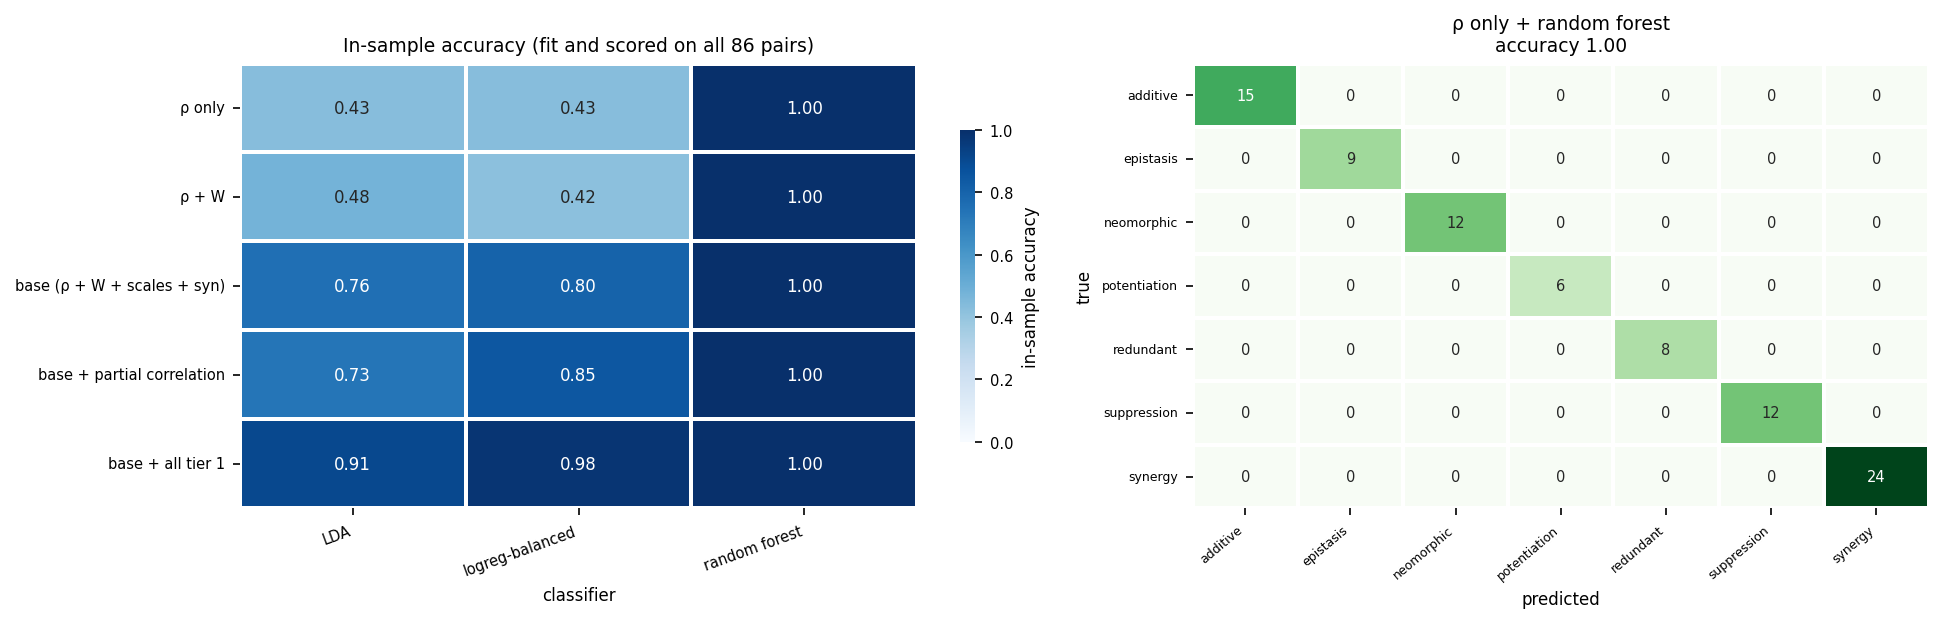


per-class recall (best in-sample fit): {'additive': 1.0, 'epistasis': 1.0, 'neomorphic': 1.0, 'potentiation': 1.0, 'redundant': 1.0, 'suppression': 1.0, 'synergy': 1.0}


,feature set,classifier,n_features,accuracy,balanced accuracy
0,ρ only,logreg-balanced,1,0.430,0.506
1,ρ only,LDA,1,0.430,0.327
2,ρ only,random forest,1,1.000,1.000
3,ρ + W,logreg-balanced,3,0.419,0.450
4,ρ + W,LDA,3,0.477,0.427
5,ρ + W,random forest,3,1.000,1.000
6,base (ρ + W + scales + syn),logreg-balanced,12,0.802,0.821
7,base (ρ + W + scales + syn),LDA,12,0.756,0.738
8,base (ρ + W + scales + syn),random forest,12,1.000,1.000
9,base + partial correlation,logreg-balanced,14,0.849,0.858


In [44]:
insample = []
SETS_IS = {'ρ only': ['rho'],
           'ρ + W': ['rho', 'gate_overlap', 'private_frac'],
           'base (ρ + W + scales + syn)': BASE,
           'base + partial correlation': BASE + T1_PCORR,
           'base + all tier 1': BASE + TIER1}
preds_is = {}
for nm, cols in SETS_IS.items():
    Xs = StandardScaler().fit_transform(_pa2[cols].values)
    for cname, clf in [('logreg-balanced', LogisticRegression(max_iter=5000, class_weight='balanced')),
                       ('LDA', LinearDiscriminantAnalysis()),
                       ('random forest', RandomForestClassifier(n_estimators=500, random_state=0))]:
        pr = clf.fit(Xs, _y2).predict(Xs)
        insample.append({'feature set': nm, 'classifier': cname, 'n_features': len(cols),
                         'accuracy': np.mean(pr == _y2), 'balanced accuracy': balanced_accuracy_score(_y2, pr)})
        preds_is[(nm, cname)] = pr
is_df = pd.DataFrame(insample)
best_is = is_df.loc[is_df['accuracy'].idxmax()]
print(f"Best in-sample: {best_is['feature set']} with {best_is['classifier']} — "
      f"accuracy {best_is['accuracy']:.3f}, balanced {best_is['balanced accuracy']:.3f}  (n = {len(_pa2)})")
pr_best = preds_is[(best_is['feature set'], best_is['classifier'])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.15, 1]})
piv = is_df.pivot(index='feature set', columns='classifier', values='accuracy').reindex(list(SETS_IS))
sns.heatmap(piv, cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f', annot_kws={'fontsize': 8},
            linewidths=1, linecolor='white', cbar_kws={'label': 'in-sample accuracy', 'shrink': 0.7}, ax=axes[0])
axes[0].set_ylabel(''); axes[0].set_title('In-sample accuracy (fit and scored on all 86 pairs)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right', fontsize=7)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=7)

cm_is = confusion_matrix(_y2, pr_best, labels=GI_ORDER)
sns.heatmap(cm_is, cmap='Greens', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[1])
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
axes[1].set_title(f"{best_is['feature set']} + {best_is['classifier']}\naccuracy {best_is['accuracy']:.2f}")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

print('\nper-class recall (best in-sample fit):',
      {short[c]: round(float((pr_best[_y2 == c] == c).mean()), 2) for c in GI_ORDER})
is_df.round(3)

## 11. An unsupervised scoring scheme

Rather than fitting weights to the labels, each interaction class gets a **prior specification**: the
model-component metrics that should be high or low if that mechanism is at work. These come from what
each component means, not from the class means measured earlier:

| Class | Mechanism | Expected signature |
|---|---|---|
| redundant | same program, same machinery, the second perturbation adds nothing | ρ↑ gate_overlap↑ concordance↑ c_mean↓ syn_rel↓ |
| synergy | same direction, amplified together | ρ↑ gate_overlap↑ c_mean↑ syn_par_cos_add↑ |
| approximately additive | both act, nothing interferes | syn_rel↓ \|c_mean−1\|↓ sign_conflict↓ nn_parent_cos↑ |
| potentiation | separate machinery, each amplified | private_frac↑ gate_overlap↓ c_mean↑ |
| suppression | damped, the new direction pushes back on the parents' own genes | c_mean↓ ρ↓ syn_perp_novelgene↓ nn_parent_minus_other↓ sat_erythroid↓ |
| epistasis | one parent dominates; coupling is mediated, not direct | mag_asym↑ syn_coef_asym↑ cls_parent_gap↑ rho_minus_pcorr↑ |
| neomorphic | a state resembling neither parent | syn_perp_novelgene↑ nn_parent_cos↓ cls_min_parent↓ sign_conflict↑ |

Every metric is z-scored across **all 5460 gene pairs** (never using labels), a class score is the mean
of its signed z-scores, and each class score is then z-scored across pairs so the argmax is not
dominated by one class's scale. Labels are used only to evaluate the result.

In [45]:
# Tier-1 metrics for every gene pair, so the scheme can score unmeasured pairs and module pairs too
t1_all_runs = []
_d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
_d.X = _d.layers['counts'].copy()
slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
_lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
_d = _d[:, (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))].copy()
_i = np.random.default_rng(0).choice(np.where(_lab == slk.configs.get_config('ntc_label'))[0], 512, replace=False)
x_bg = torch.tensor(_d.X[_i].toarray(), dtype=torch.float32, device=DEVICE)
ia_all, ib_all = IU
BATCH = 48

for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        Lq = m.qr().cpu(); sig = pyro.param('sigma_fac').detach().cpu()
        Sig = Lq @ Lq.T + sig ** 2 * torch.eye(Lq.shape[0])
        Th = torch.linalg.inv(Sig.double()); dth = torch.sqrt(torch.diag(Th))
        pcorr_m = (-Th / torch.outer(dth, dth)).numpy()

        shifts = m._get_all_pert_shifts(DEVICE)[1:]
        S_, W_, q_ = shifts[:, 0], shifts[:, 1], shifts[:, 2]
        u = m._abduct_ntc(x_bg)
        _ln = lambda z: torch.log1p(m._decode_to_expr(z, 1.) * 1e4).mean(0)
        base = _ln(u)
        Dm = torch.stack([_ln(u + S_[k]) - base for k in range(P)])
        Dn = Dm / (Dm.norm(dim=1, keepdim=True) + 1e-8)
        gidx_t = {k: torch.as_tensor(np.where(np.isin(var_names, list(prog.index[prog == k])))[0], device=DEVICE)
                  for k in prog_ids}

        DIRECTIONAL = ['dom_gap', 'parent_coef_asym', 'dominant_parent_fit', 'add_fit', 'combo_novel_frac',
                       'joint_over_add']
        # Purely parametric descriptors, read straight off the model's combination equation
        #   z_ab = z0 + c_a (A_a*W_a) + c_b (A_b*W_b) + syn(rho_a, rho_b)
        # No decoding, no data: these are functions of the gates, loadings, parent-scale layer and
        # synergy MLP alone.
        PARAMETRIC = ['c_ratio', 'c_sum', 'syn_offgate_frac', 'syn_ongate_cos',
                      'combo_over_maxparent', 'combo_over_add_lat', 'dist_to_dominant']
        hi_g = torch.quantile(Dm.abs(), 0.9, dim=1, keepdim=True)
        act_g = Dm.abs() > hi_g                      # genes each single perturbation moves
        cols = {k: np.empty(len(ia_all), dtype=np.float32)
                for k in T1_CLS + T1_NN + T1_PROG + DIRECTIONAL + PARAMETRIC}
        for s in range(0, len(ia_all), BATCH):
            A_b = torch.as_tensor(ia_all[s:s + BATCH], device=DEVICE)
            B_b = torch.as_tensor(ib_all[s:s + BATCH], device=DEVICE)
            ca, cb = m._parent_scales_from_rho(q_[A_b], q_[B_b])
            syn = m._synergy_shift_from_rho(q_[A_b], q_[B_b])
            shift_ab = ca * S_[A_b] + cb * S_[B_b] + syn
            z = u[None] + shift_ab[:, None]                                 # (b, n_bg, d)
            zf = z.reshape(-1, z.shape[-1])
            d_ab = torch.log1p(m._decode_to_expr(zf, 1.) * 1e4).reshape(len(A_b), x_bg.shape[0], -1).mean(1) - base
            pr = m.cls_head(zf).sigmoid().reshape(len(A_b), x_bg.shape[0], -1).mean(1)      # (b, P)
            add = Dm[A_b] + Dm[B_b]
            cos_all = (d_ab / (d_ab.norm(dim=1, keepdim=True) + 1e-8)) @ Dn.T               # (b, P)
            rows_b = torch.arange(len(A_b), device=DEVICE)
            p_a, p_b = pr[rows_b, A_b], pr[rows_b, B_b]
            cos_a, cos_b = cos_all[rows_b, A_b], cos_all[rows_b, B_b]
            mask = torch.ones_like(cos_all, dtype=torch.bool)
            mask[rows_b, A_b] = False; mask[rows_b, B_b] = False
            nn_other = cos_all.masked_fill(~mask, -2).max(1).values
            cls_other = pr.masked_fill(~mask, -2).max(1).values
            nn_par = torch.maximum(cos_a, cos_b)
            sl = slice(s, s + len(A_b))
            cols['cls_min_parent'][sl] = torch.minimum(p_a, p_b).cpu().numpy()
            cols['cls_parent_gap'][sl] = (p_a - p_b).abs().cpu().numpy()
            cols['cls_best_other'][sl] = cls_other.cpu().numpy()
            cols['nn_other_cos'][sl] = nn_other.cpu().numpy()
            cols['nn_parent_cos'][sl] = nn_par.cpu().numpy()
            cols['nn_parent_minus_other'][sl] = (nn_par - nn_other).cpu().numpy()
            # Directional dominance: regress the predicted combination on its two parents in gene
            # space. Epistasis means the combination sits on ONE parent's axis, which is an
            # asymmetric statement that symmetric magnitude measures cannot express.
            Xp = torch.stack([Dm[A_b], Dm[B_b]], -1)                       # (b, G, 2)
            cf = torch.linalg.lstsq(Xp, d_ab.unsqueeze(-1)).solution.squeeze(-1)   # (b, 2)
            big = cf.abs().max(1).values; small = cf.abs().min(1).values
            fit = (Xp @ cf.unsqueeze(-1)).squeeze(-1)
            cols['dom_gap'][sl] = (cos_a - cos_b).abs().cpu().numpy()
            cols['parent_coef_asym'][sl] = torch.log2((big + 0.05) / (small + 0.05)).cpu().numpy()
            cols['dominant_parent_fit'][sl] = (1 - (d_ab - fit).norm(dim=1) / (d_ab.norm(dim=1) + 1e-8)).cpu().numpy()
            # Positive signature for 'additive': the combination IS the sum of its parents.
            cols['add_fit'][sl] = (1 - (d_ab - add).norm(dim=1) / (add.norm(dim=1) + 1e-8)).cpu().numpy()
            # Positive signature for 'neomorphic': the combination's own effect lands on genes
            # neither parent moves.
            # Magnitude of the combination relative to the additive expectation: this is what
            # separates suppression (damped) from neomorphic (a different direction, not damped).
            cols['joint_over_add'][sl] = (d_ab.norm(dim=1) / (add.norm(dim=1) + 1e-8)).cpu().numpy()
            novel_msk = ~(act_g[A_b] | act_g[B_b])
            cols['combo_novel_frac'][sl] = ((d_ab.pow(2) * novel_msk).sum(1) /
                                            (d_ab.pow(2).sum(1) + 1e-9)).cpu().numpy()
            # ---- parametric block (latent space only) ----
            Sa_b, Sb_b = S_[A_b], S_[B_b]
            add_lat = Sa_b + Sb_b
            ca_s, cb_s = ca.squeeze(-1), cb.squeeze(-1)
            cols['c_ratio'][sl] = (torch.log2((torch.maximum(ca_s, cb_s) + 0.05) /
                                              (torch.minimum(ca_s, cb_s) + 0.05))).cpu().numpy()
            cols['c_sum'][sl] = (ca_s + cb_s).cpu().numpy()
            openg = (W_[A_b] > GATE_THR) | (W_[B_b] > GATE_THR)      # factors either parent uses
            syn_e = syn.pow(2)
            cols['syn_offgate_frac'][sl] = ((syn_e * ~openg).sum(1) / (syn_e.sum(1) + 1e-9)).cpu().numpy()
            syn_on = syn * openg
            cols['syn_ongate_cos'][sl] = ((syn_on * add_lat).sum(1) /
                                          (syn_on.norm(dim=1) * add_lat.norm(dim=1) + 1e-8)).cpu().numpy()
            maxpar = torch.maximum(Sa_b.norm(dim=1), Sb_b.norm(dim=1))
            cols['combo_over_maxparent'][sl] = (shift_ab.norm(dim=1) / (maxpar + 1e-8)).cpu().numpy()
            cols['combo_over_add_lat'][sl] = (shift_ab.norm(dim=1) / (add_lat.norm(dim=1) + 1e-8)).cpu().numpy()
            dom_is_a = (ca_s * Sa_b.norm(dim=1)) >= (cb_s * Sb_b.norm(dim=1))
            dom_shift = torch.where(dom_is_a[:, None], ca_s[:, None] * Sa_b, cb_s[:, None] * Sb_b)
            cols['dist_to_dominant'][sl] = ((shift_ab - dom_shift).norm(dim=1) /
                                            (shift_ab.norm(dim=1) + 1e-8)).cpu().numpy()
            floor = 0.05 * add.norm(dim=1) / np.sqrt(len(prog_ids))
            for k in prog_ids:
                gi_k = gidx_t[k]
                cols[f'sat_P{k}'][sl] = torch.clamp(torch.log2((d_ab[:, gi_k].norm(dim=1) + floor) /
                                                              (add[:, gi_k].norm(dim=1) + floor)), -4, 4).cpu().numpy()
        df_run = pd.DataFrame(cols)
        df_run['pcorr'] = pcorr_m[ia_all, ib_all]
        t1_all_runs.append(df_run)
    del m
    torch.cuda.empty_cache()
del _d, x_bg

t1_all = sum(t1_all_runs) / len(t1_all_runs)
for c in t1_all.columns:
    gp[c] = t1_all[c].values
gp['rho_minus_pcorr'] = gp['rho'] - gp['pcorr']
gp['additivity'] = -(gp['c_mean'] - 1).abs()
gp['sat_erythroid'] = gp[['sat_P3', 'sat_P4']].mean(1)
print(f'tier-1 metrics computed for all {len(gp)} gene pairs')
gp[['pcorr', 'cls_min_parent', 'nn_parent_cos', 'sat_erythroid']].describe().round(3)

tier-1 metrics computed for all 5460 gene pairs


,pcorr,cls_min_parent,nn_parent_cos,sat_erythroid
count,5460.000,5460.000,5460.000,5460.000
mean,0.005,0.027,0.892,0.114
std,0.028,0.055,0.095,0.367
min,-0.245,0.000,0.260,-1.699
25%,-0.007,0.005,0.861,-0.101
50%,0.003,0.012,0.921,0.155
75%,0.016,0.025,0.955,0.336
max,0.254,0.835,0.996,2.009


Unsupervised scoring on the 86 labelled pairs: accuracy 0.500, balanced 0.496  (majority 0.279, chance 0.143)


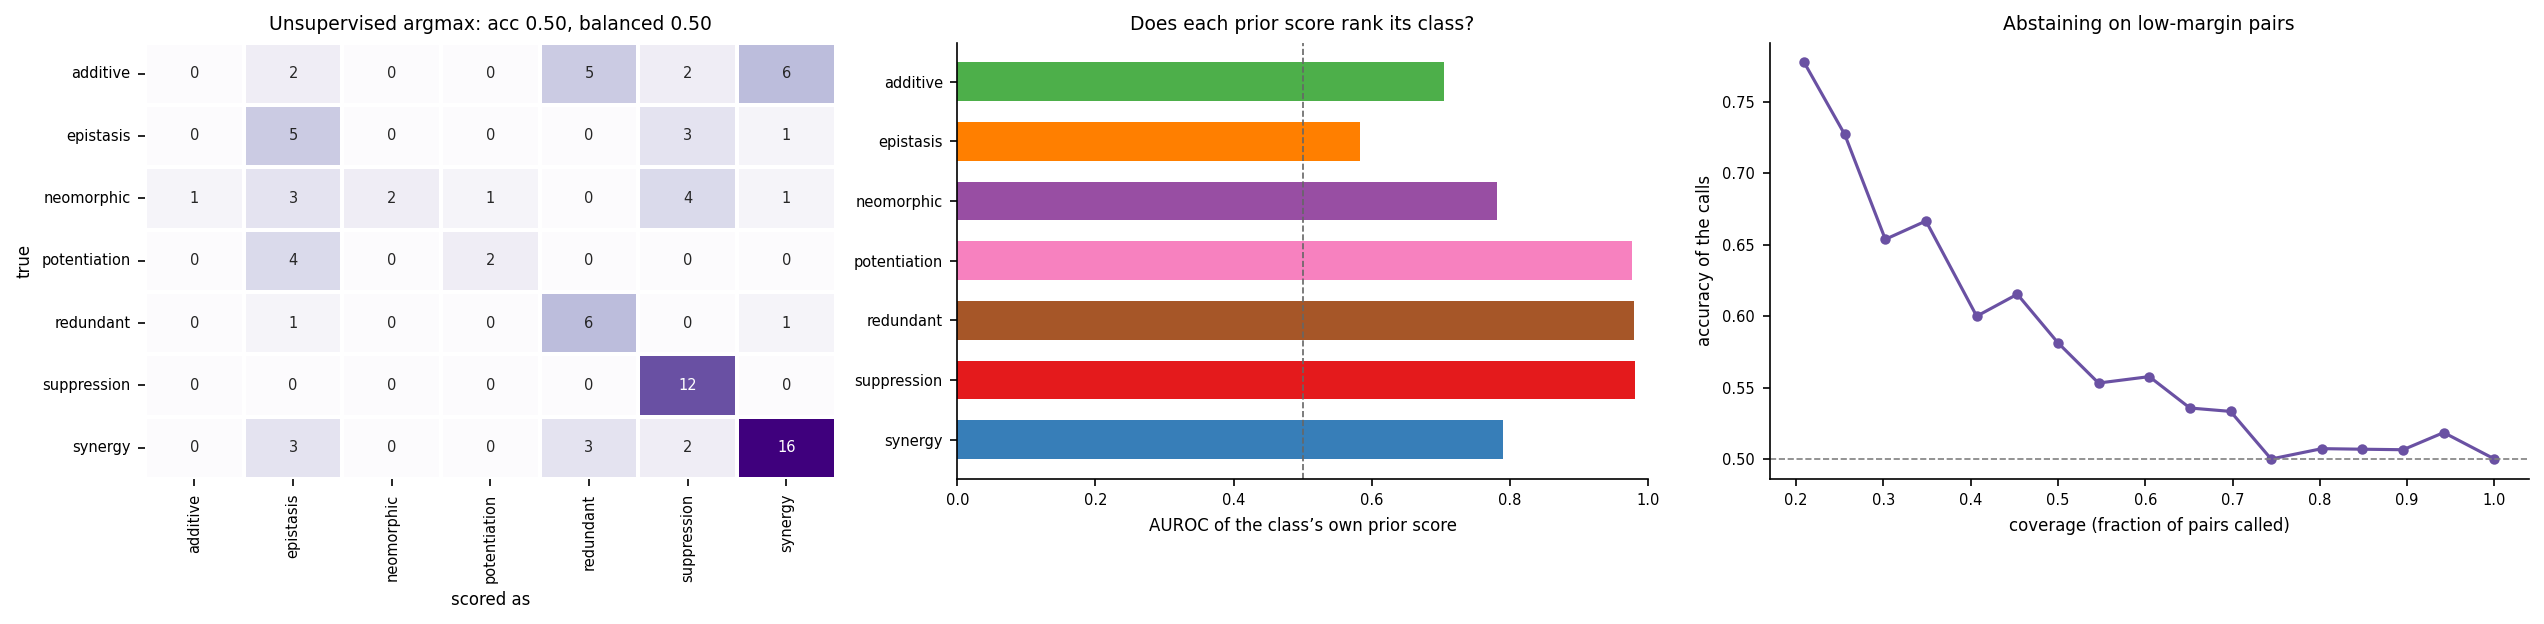

,n,AUROC of its own score,recall (argmax)
class,,,
approximately additive,15,0.705,0.000
epistasis,9,0.583,0.556
neomorphic,12,0.782,0.167
potentiation,6,0.977,0.333
redundant,8,0.981,0.750
suppression,12,0.982,1.000
synergy,24,0.790,0.667


In [46]:
# ── Prior specifications: (weight, metric), no labels used ───────────────
PRIORS = {
    'redundant':              [(1, 'rho'), (1, 'gate_overlap'), (1, 'concordance'), (-1, 'c_mean'), (-1, 'syn_rel')],
    'synergy':                [(1, 'rho'), (1, 'gate_overlap'), (1, 'c_mean'), (1, 'syn_par_cos_add')],
    'approximately additive': [(-1, 'syn_rel'), (1, 'additivity'), (-1, 'sign_conflict'), (1, 'nn_parent_cos')],
    'potentiation':           [(1, 'private_frac'), (-1, 'gate_overlap'), (1, 'c_mean')],
    'suppression':            [(-1, 'c_mean'), (-1, 'rho'), (-1, 'syn_perp_novelgene'),
                               (-1, 'nn_parent_minus_other'), (-1, 'sat_erythroid')],
    'epistasis':              [(1, 'mag_asym'), (1, 'syn_coef_asym'), (1, 'cls_parent_gap'), (1, 'rho_minus_pcorr')],
    'neomorphic':             [(1, 'syn_perp_novelgene'), (-1, 'nn_parent_cos'), (-1, 'cls_min_parent'),
                               (1, 'sign_conflict')],
}
USED = sorted({mt for spec in PRIORS.values() for _, mt in spec})
Z = (gp[USED] - gp[USED].mean()) / gp[USED].std()          # z-scored over ALL gene pairs, label-free

def score_table(Zdf):
    sc_ = pd.DataFrame({cls: np.mean([w * Zdf[mt] for w, mt in spec], axis=0) for cls, spec in PRIORS.items()})
    return (sc_ - sc_.mean()) / sc_.std()                   # comparable across classes

scores_all = score_table(Z)
scores_all.index = gp.index
gp_scored = gp[['combination', 'module_pair', 'measured_combo']].join(scores_all)
gp_scored['predicted'] = scores_all.idxmax(1)
gp_scored['margin'] = (scores_all.max(1) - scores_all.apply(lambda r: r.nlargest(2).iloc[-1], axis=1))

ev = pairs_df[['combination', 'gi']].merge(gp_scored, on='combination')
acc = np.mean(ev['predicted'] == ev['gi'])
bal = balanced_accuracy_score(ev['gi'], ev['predicted'])
print(f'Unsupervised scoring on the {len(ev)} labelled pairs: accuracy {acc:.3f}, balanced {bal:.3f}  '
      f'(majority {pairs_df["gi"].value_counts(normalize=True).max():.3f}, chance {1/7:.3f})')

# Each class score on its own, as a one-vs-rest ranker
auc_rows = []
for cls in GI_ORDER:
    s_in = ev.loc[ev['gi'] == cls, cls]; s_out = ev.loc[ev['gi'] != cls, cls]
    auc_rows.append({'class': cls, 'n': len(s_in),
                     'AUROC of its own score': mannwhitneyu(s_in, s_out).statistic / (len(s_in) * len(s_out)),
                     'recall (argmax)': float((ev.loc[ev['gi'] == cls, 'predicted'] == cls).mean())})
auc_df = pd.DataFrame(auc_rows).set_index('class').reindex(GI_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), gridspec_kw={'width_ratios': [1, 1, 1.1]})
cm_u = confusion_matrix(ev['gi'], ev['predicted'], labels=GI_ORDER)
sns.heatmap(cm_u, cmap='Purples', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[0])
axes[0].set_xlabel('scored as'); axes[0].set_ylabel('true')
axes[0].set_title(f'Unsupervised argmax: acc {acc:.2f}, balanced {bal:.2f}')

ax = axes[1]
ax.barh(np.arange(len(GI_ORDER)), auc_df['AUROC of its own score'],
        color=[PALETTE_GI[c] for c in GI_ORDER], height=0.65)
ax.axvline(0.5, color='0.4', ls='--', lw=0.8)
ax.set_yticks(np.arange(len(GI_ORDER))); ax.set_yticklabels([short[c] for c in GI_ORDER], fontsize=7)
ax.invert_yaxis(); ax.set_xlim(0, 1); ax.set_xlabel('AUROC of the class’s own prior score')
ax.set_title('Does each prior score rank its class?')

# accuracy when only confident calls are kept
ax = axes[2]
qs = np.linspace(0, 0.8, 17)
cov, ac = [], []
for q in qs:
    thr = ev['margin'].quantile(q)
    sel = ev[ev['margin'] >= thr]
    cov.append(len(sel) / len(ev)); ac.append(np.mean(sel['predicted'] == sel['gi']))
ax.plot(cov, ac, marker='o', ms=4, color='#6a51a3')
ax.axhline(acc, color='0.5', ls='--', lw=0.8)
ax.set_xlabel('coverage (fraction of pairs called)'); ax.set_ylabel('accuracy of the calls')
ax.set_title('Abstaining on low-margin pairs')
plt.tight_layout()
plt.show()
auc_df.round(3)

In [47]:
# The scheme applied to module pairs, using only unmeasured gene pairs
mp_scores = gp_scored[~gp_scored['measured_combo']].groupby('module_pair')[GI_ORDER].mean()
mp_scores['scored as'] = mp_scores.idxmax(1)
mp_obs = (pairs_df.groupby('module_pair')
          .agg(n_gt=('gi', 'size'),
               observed=('gi', lambda s: ', '.join(f'{k}:{v}' for k, v in s.value_counts().items())),
               dominant=('gi', lambda s: s.value_counts().index[0])))
mp_tab = mp_scores.join(mp_obs).sort_values('n_gt', ascending=False)
hit = mp_tab.dropna(subset=['dominant'])
print(f"Module pairs whose unsupervised call matches their most common observed class: "
      f"{(hit['scored as'] == hit['dominant']).sum()} / {len(hit)}")
print(f"  restricted to module pairs with >= 3 GT pairs: "
      f"{(hit[hit['n_gt'] >= 3]['scored as'] == hit[hit['n_gt'] >= 3]['dominant']).sum()} / {(hit['n_gt'] >= 3).sum()}")
mp_tab[['n_gt', 'observed', 'scored as'] + GI_ORDER].head(25).round(2)

Module pairs whose unsupervised call matches their most common observed class: 7 / 36
  restricted to module pairs with >= 3 GT pairs: 3 / 10


,n_gt,observed,scored as,approximately additive,epistasis,neomorphic,potentiation,redundant,suppression,synergy
module_pair,,,,,,,,,,
M2,7.0,"synergy:5, approximately additive:2",synergy,0.97,0.34,-0.56,-0.80,1.30,-1.19,1.65
M8×M11,6.0,"suppression:4, neomorphic:1, epistasis:1",epistasis,-0.00,0.81,-0.18,0.21,-0.22,-0.07,-0.34
M1×M2,5.0,"synergy:4, approximately additive:1",redundant,0.47,0.10,-0.39,-0.46,0.71,-0.47,0.71
M2×M3,5.0,"suppression:4, neomorphic:1",suppression,0.13,-0.65,-0.41,-0.41,0.05,0.59,0.05
M3×M6,5.0,"neomorphic:3, epistasis:2",suppression,-0.96,-0.51,0.84,0.06,-0.95,0.85,-0.91
M1×M9,5.0,"synergy:4, approximately additive:1",suppression,0.22,-0.11,-0.40,-0.28,0.27,0.36,-0.00
M3,4.0,redundant:4,redundant,0.50,0.88,-0.88,-0.36,1.03,-0.01,0.41
M1×M3,3.0,"synergy:2, suppression:1",suppression,-0.11,-0.37,-0.29,-0.39,0.07,0.63,-0.23
M3×M5,3.0,"potentiation:2, synergy:1",suppression,0.16,-0.29,-0.13,-0.21,0.24,0.24,0.16


### 11b. Additive as the fallback

*Approximately additive* is a null class — it means no mechanism fired — so it should not have to win
an argmax against classes defined by a positive signature. The rule becomes: take the strongest
non-additive class **only if its score clears a threshold**, otherwise call the pair additive. Since
the scores are z-scored across all gene pairs, τ = 0 (the population mean) is the natural label-free
choice; the sweep below shows the labels were not used to pick it.

With additive as fallback (tau = 0): accuracy 0.500, balanced 0.496
  argmax version was:                accuracy 0.500, balanced 0.496


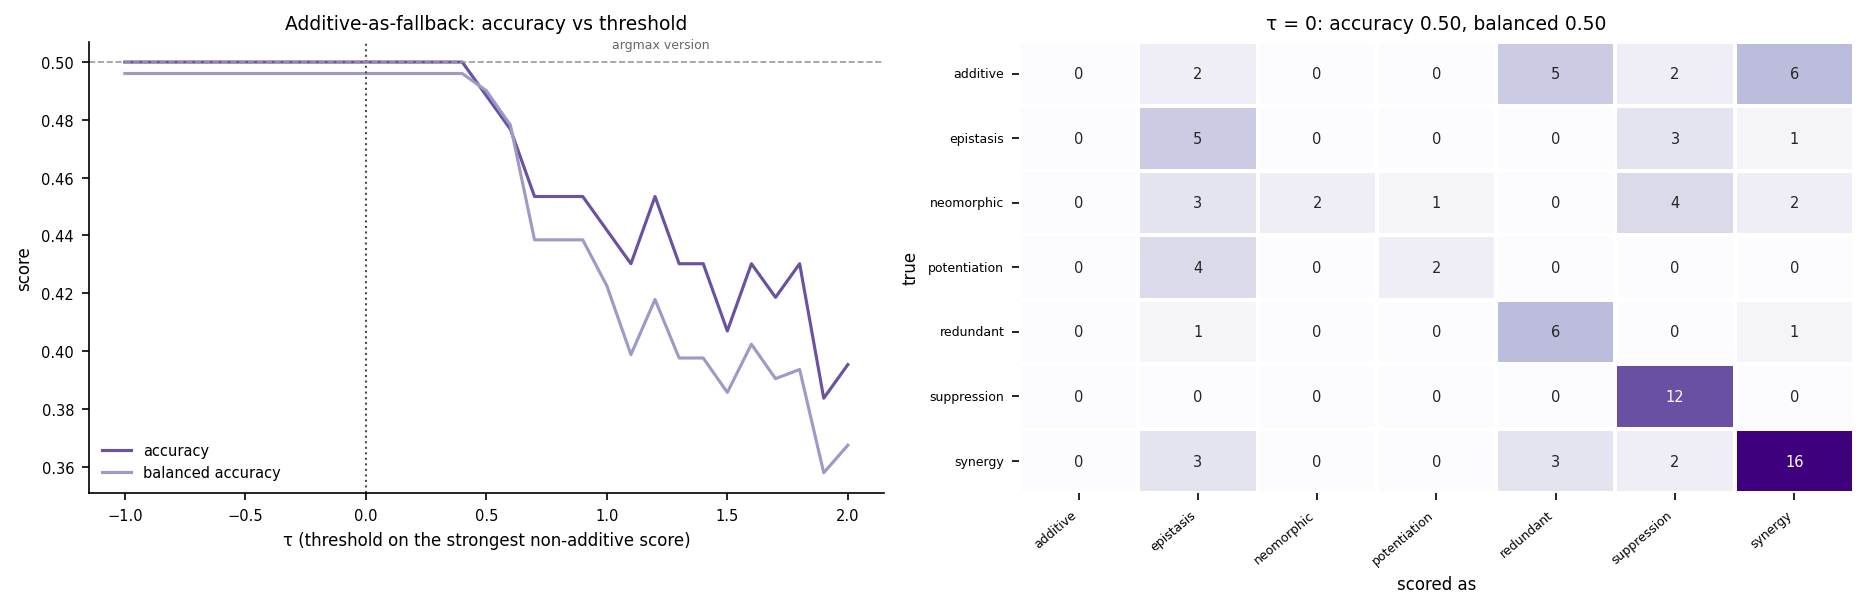

per-class recall: {'additive': 0.0, 'epistasis': 0.56, 'neomorphic': 0.17, 'potentiation': 0.33, 'redundant': 0.75, 'suppression': 1.0, 'synergy': 0.67}


In [48]:
NON_ADD = [c for c in GI_ORDER if c != 'approximately additive']
best_non_add = scores_all[NON_ADD].idxmax(1)
best_score = scores_all[NON_ADD].max(1)

def _apply(tau):
    return np.where(best_score.values >= tau, best_non_add.values, 'approximately additive')

gp_scored['predicted_fb'] = _apply(0.0)
ev2 = pairs_df[['combination', 'gi']].merge(gp_scored[['combination', 'predicted_fb']], on='combination')
acc_fb = np.mean(ev2['predicted_fb'] == ev2['gi'])
bal_fb = balanced_accuracy_score(ev2['gi'], ev2['predicted_fb'])
print(f'With additive as fallback (tau = 0): accuracy {acc_fb:.3f}, balanced {bal_fb:.3f}')
print(f'  argmax version was:                accuracy {acc:.3f}, balanced {bal:.3f}')

taus = np.linspace(-1.0, 2.0, 31)
curve = []
for t in taus:
    p = _apply(t)
    e = pairs_df[['combination', 'gi']].merge(
        pd.DataFrame({'combination': gp_scored['combination'], 'p': p}), on='combination')
    curve.append({'tau': t, 'accuracy': np.mean(e['p'] == e['gi']),
                  'balanced': balanced_accuracy_score(e['gi'], e['p'])})
curve = pd.DataFrame(curve)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1), gridspec_kw={'width_ratios': [1, 1.05]})
ax = axes[0]
ax.plot(curve['tau'], curve['accuracy'], label='accuracy', color='#6a51a3')
ax.plot(curve['tau'], curve['balanced'], label='balanced accuracy', color='#9e9ac8')
ax.axvline(0, color='0.3', ls=':', lw=1)
ax.axhline(acc, color='0.6', ls='--', lw=0.8)
ax.text(1.02, acc + 0.005, 'argmax version', fontsize=6, color='0.4')
ax.set_xlabel('τ (threshold on the strongest non-additive score)'); ax.set_ylabel('score')
ax.legend(frameon=False, fontsize=7)
ax.set_title('Additive-as-fallback: accuracy vs threshold')

cm_fb = confusion_matrix(ev2['gi'], ev2['predicted_fb'], labels=GI_ORDER)
sns.heatmap(cm_fb, cmap='Purples', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[1])
axes[1].set_xlabel('scored as'); axes[1].set_ylabel('true')
axes[1].set_title(f'τ = 0: accuracy {acc_fb:.2f}, balanced {bal_fb:.2f}')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

print('per-class recall:', {short[c]: round(float((ev2.loc[ev2['gi'] == c, 'predicted_fb'] == c).mean()), 2)
                            for c in GI_ORDER})

### 11c. Three fixes to the scheme

1. **Per-class calibration.** Z-scores assume the class scores have comparable shapes; they do not, so
   classes with heavy tails win the argmax too often (this is why *additive* never won). Each score is
   now converted to its **empirical percentile over all 5460 gene pairs** — a label-free rank
   calibration — before the classes compete.
2. **A directional epistasis prior.** Epistasis means the combination sits on *one parent's axis*,
   which symmetric magnitude measures cannot express. The predicted combination is regressed on its two
   parents in gene space: `parent_coef_asym` (ratio of the two coefficients), `dom_gap` (which parent the
   combination resembles) and `dominant_parent_fit` (how fully the two parents explain it).
3. **Module pairs scored from extremes.** A module pair's character is driven by a few strong gene
   pairs, so module-level scores use the mean of the top-3 gene pairs per class instead of the mean of all.

                      scheme  accuracy  balanced accuracy
       z-scored argmax (§11)     0.500              0.496
percentile, mechanism priors     0.512              0.542
percentile, parameter priors     0.547              0.542
   percentile, union of both     0.535              0.525
   percentile, hybrid priors     0.581              0.589
union + additive as residual     0.547              0.548

Best: percentile, hybrid priors
per-class recall: {'additive': 0.4, 'epistasis': 0.56, 'neomorphic': 0.17, 'potentiation': 0.5, 'redundant': 0.88, 'suppression': 1.0, 'synergy': 0.62}


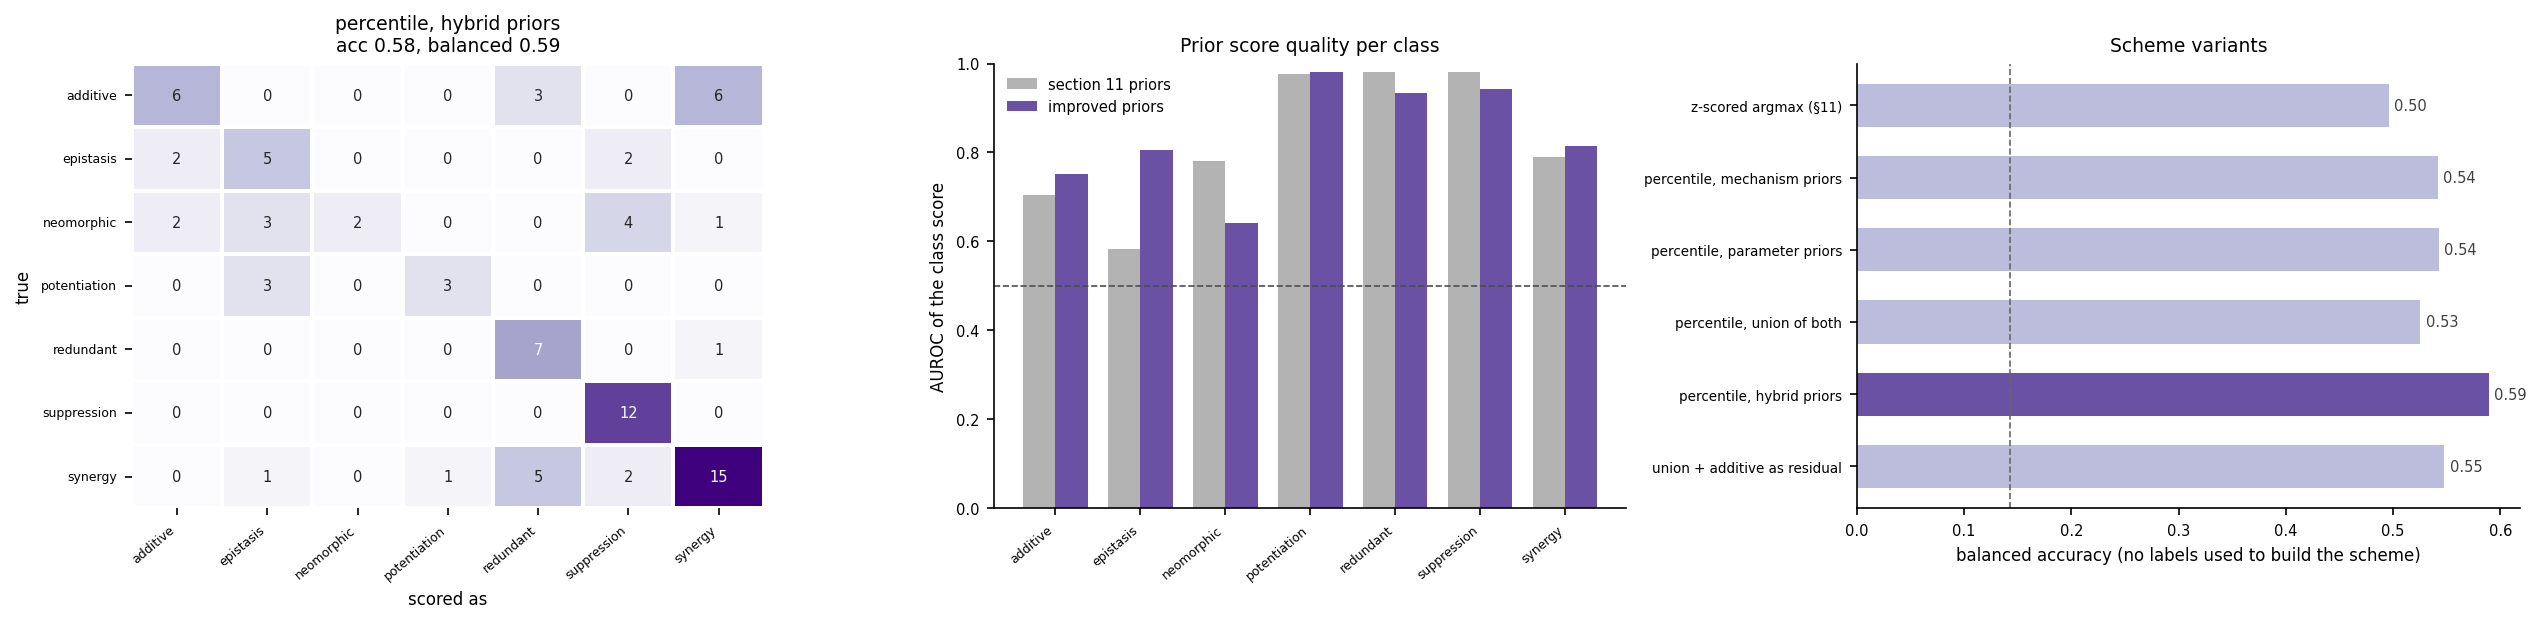

,scheme,accuracy,balanced accuracy
0,z-scored argmax (§11),0.500,0.496
1,"percentile, mechanism priors",0.512,0.542
2,"percentile, parameter priors",0.547,0.542
3,"percentile, union of both",0.535,0.525
4,"percentile, hybrid priors",0.581,0.589
5,union + additive as residual,0.547,0.548


In [49]:
gp['dom_gap'] = t1_all['dom_gap'].values if 'dom_gap' in t1_all else gp.get('dom_gap')
PRIORS2 = dict(PRIORS)
# ── Priors rewritten against the model's own combination equation ───────
#     z_ab = z0 + c_a (A_a*W_a) + c_b (A_b*W_b) + syn(rho_a, rho_b)
# Each class is a statement about those parameters:
#   redundant   : the pair behaves like ONE parent -> combo norm ~ max parent, scales damped
#   synergy     : the pair exceeds the sum        -> combo/additive > 1, scales up
#   additive    : c_a ~ c_b ~ 1 and syn ~ 0       -> combo/additive ~ 1
#   potentiation: each parent amplified on its OWN factors -> scales up, gates disjoint
#   suppression : scales damped AND syn pushes back against the parents' own factors
#   epistasis   : one parent's scale dominates    -> c_ratio high, combo sits on that parent
#   neomorphic  : syn opens factors NEITHER parent gates, and the result is not damped
gp['add_balance'] = -(gp['combo_over_add_lat'] - 1).abs()
gp['one_parent_like'] = -(gp['combo_over_maxparent'] - 1).abs()
PRIORS2['redundant'] = [(1, 'rho'), (1, 'gate_overlap'), (1, 'one_parent_like'), (-1, 'c_sum'), (-1, 'syn_rel')]
PRIORS2['synergy'] = [(1, 'rho'), (1, 'gate_overlap'), (1, 'c_sum'), (1, 'combo_over_add_lat'),
                      (1, 'syn_par_cos_add')]
PRIORS2['approximately additive'] = [(1, 'add_fit'), (1, 'add_balance'), (-1, 'syn_rel'),
                                     (-1, 'combo_novel_frac'), (-1, 'sign_conflict')]
PRIORS2['potentiation'] = [(1, 'private_frac'), (-1, 'gate_overlap'), (1, 'c_sum'), (1, 'combo_over_add_lat')]
PRIORS2['suppression'] = [(-1, 'c_sum'), (-1, 'rho'), (-1, 'syn_ongate_cos'), (-1, 'joint_over_add'),
                          (-1, 'nn_parent_minus_other'), (-1, 'sat_erythroid')]
PRIORS2['epistasis'] = [(1, 'c_ratio'), (-1, 'dist_to_dominant'), (1, 'dom_gap'), (1, 'parent_coef_asym'),
                        (1, 'dominant_parent_fit'), (1, 'rho_minus_pcorr')]
PRIORS2['neomorphic'] = [(1, 'syn_offgate_frac'), (1, 'combo_novel_frac'), (1, 'syn_perp_novelgene'),
                         (1, 'joint_over_add'), (-1, 'nn_parent_cos'), (-1, 'c_ratio')]
# A third reading: keep the mechanism priors for the classes they already describe well
# (redundant, synergy, potentiation) and use the parameter-level statements only where the
# mechanism version had no positive signature at all (epistasis, additive, neomorphic, and the
# damped-vs-novel split between suppression and neomorphic).
PRIORS_HYB = dict(PRIORS)
PRIORS_HYB['epistasis'] = [(1, 'dom_gap'), (1, 'parent_coef_asym'), (1, 'dominant_parent_fit'),
                           (1, 'cls_parent_gap'), (1, 'rho_minus_pcorr')]
PRIORS_HYB['approximately additive'] = [(1, 'add_fit'), (-1, 'syn_rel'), (-1, 'combo_novel_frac'),
                                        (-1, 'sign_conflict')]
PRIORS_HYB['neomorphic'] = [(1, 'combo_novel_frac'), (1, 'syn_perp_novelgene'), (-1, 'nn_parent_cos'),
                            (-1, 'cls_min_parent'), (1, 'joint_over_add')]
PRIORS_HYB['suppression'] = PRIORS['suppression'] + [(-1, 'joint_over_add')]

# The mechanism-level priors (§11) and the parameter-level priors above are two readings of the same
# mechanisms; their UNION keeps every term from both, so no class is chosen by looking at the labels.
PRIORS3 = {}
for cls in GI_ORDER:
    seen, terms = {}, []
    for w, mt in PRIORS2[cls] + PRIORS[cls]:
        if mt in seen:
            continue
        seen[mt] = w
        terms.append((w, mt))
    PRIORS3[cls] = terms

USED2 = sorted({mt for spec in PRIORS2.values() for _, mt in spec})
Z2 = (gp[USED2] - gp[USED2].mean()) / gp[USED2].std()
raw2 = pd.DataFrame({cls: np.mean([w * Z2[mt] for w, mt in spec], axis=0) for cls, spec in PRIORS2.items()})

# label-free rank calibration: each class score -> its percentile among all gene pairs
pct = raw2.rank(pct=True)
pct.index = gp.index

def _evaluate(pred, name):
    e = pairs_df[['combination', 'gi']].merge(
        pd.DataFrame({'combination': gp['combination'].values, 'p': pred}), on='combination')
    return {'scheme': name, 'accuracy': np.mean(e['p'] == e['gi']),
            'balanced accuracy': balanced_accuracy_score(e['gi'], e['p'])}, e

def _pct_scores(priors):
    used = sorted({mt for spec in priors.values() for _, mt in spec})
    Zu = (gp[used] - gp[used].mean()) / gp[used].std()
    raw = pd.DataFrame({cls: np.mean([w * Zu[mt] for w, mt in spec], axis=0) for cls, spec in priors.items()})
    out = raw.rank(pct=True)
    out.index = gp.index
    return out[GI_ORDER]

pct_v1 = _pct_scores(PRIORS)          # mechanism-level priors (§11)
pct_v2 = _pct_scores(PRIORS2)         # parameter-level priors (this section)
pct = _pct_scores(PRIORS3)            # union of both

variants = []
variants.append(_evaluate(scores_all.idxmax(1).values, 'z-scored argmax (§11)'))
variants.append(_evaluate(pct_v1.idxmax(1).values, 'percentile, mechanism priors'))
variants.append(_evaluate(pct_v2.idxmax(1).values, 'percentile, parameter priors'))
variants.append(_evaluate(pct.idxmax(1).values, 'percentile, union of both'))
pct_hyb = _pct_scores(PRIORS_HYB)
variants.append(_evaluate(pct_hyb.idxmax(1).values, 'percentile, hybrid priors'))
non_add_pct = pct[[c for c in GI_ORDER if c != 'approximately additive']]
pred_res = np.where(non_add_pct.max(1) >= 0.5, non_add_pct.idxmax(1), 'approximately additive')
variants.append(_evaluate(pred_res, 'union + additive as residual'))

res_df = pd.DataFrame([v[0] for v in variants])
best_i = int(res_df['balanced accuracy'].idxmax())
best_e = variants[best_i][1]
print(res_df.round(3).to_string(index=False))
print(f"\nBest: {res_df.iloc[best_i]['scheme']}")
print('per-class recall:', {short[c]: round(float((best_e.loc[best_e['gi'] == c, 'p'] == c).mean()), 2) for c in GI_ORDER})

auc2 = {}
ev_pct = pairs_df[['combination', 'gi']].merge(pct.assign(combination=gp['combination'].values), on='combination')
for cls in GI_ORDER:
    a_ = ev_pct.loc[ev_pct['gi'] == cls, cls]; b_ = ev_pct.loc[ev_pct['gi'] != cls, cls]
    auc2[cls] = mannwhitneyu(a_, b_).statistic / (len(a_) * len(b_))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), gridspec_kw={'width_ratios': [1, 1, 1.05]})
cmv = confusion_matrix(best_e['gi'], best_e['p'], labels=GI_ORDER)
sns.heatmap(cmv, cmap='Purples', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[0])
axes[0].set_xlabel('scored as'); axes[0].set_ylabel('true')
axes[0].set_title(f"{res_df.iloc[best_i]['scheme']}\nacc {res_df.iloc[best_i]['accuracy']:.2f}, "
                  f"balanced {res_df.iloc[best_i]['balanced accuracy']:.2f}")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=6)

ax = axes[1]
old_auc = auc_df['AUROC of its own score']
xp = np.arange(len(GI_ORDER)); w = 0.38
ax.bar(xp - w / 2, [old_auc[c] for c in GI_ORDER], width=w, color='0.7', label='section 11 priors')
ax.bar(xp + w / 2, [auc2[c] for c in GI_ORDER], width=w, color='#6a51a3', label='improved priors')
ax.axhline(0.5, color='0.3', lw=0.8, ls='--')
ax.set_xticks(xp); ax.set_xticklabels([short[c] for c in GI_ORDER], rotation=40, ha='right', fontsize=6)
ax.set_ylabel('AUROC of the class score'); ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=7); ax.set_title('Prior score quality per class')

ax = axes[2]
ypos = np.arange(len(res_df))
ax.barh(ypos, res_df['balanced accuracy'], color=['#6a51a3' if i == best_i else '#bcbddc' for i in range(len(res_df))],
        height=0.6)
for n, v in enumerate(res_df['balanced accuracy']):
    ax.text(v + 0.005, n, f'{v:.2f}', va='center', fontsize=7, color='0.25')
ax.set_yticks(ypos); ax.set_yticklabels(res_df['scheme'], fontsize=6.5)
ax.invert_yaxis(); ax.axvline(1 / 7, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('balanced accuracy (no labels used to build the scheme)')
ax.set_title('Scheme variants')
plt.tight_layout()
plt.show()
res_df.round(3)

In [50]:
# Module pairs scored from their most extreme gene pairs rather than the mean
pct_mp = pct.assign(module_pair=gp['module_pair'].values, measured=gp['measured_combo'].values)
unm = pct_mp[~pct_mp['measured']]
top3 = unm.groupby('module_pair')[GI_ORDER].agg(lambda s: s.nlargest(min(3, len(s))).mean())
mean_all = unm.groupby('module_pair')[GI_ORDER].mean()

obs = (pairs_df.groupby('module_pair')
       .agg(n_gt=('gi', 'size'), dominant=('gi', lambda s: s.value_counts().index[0]),
            observed=('gi', lambda s: ', '.join(f'{k}:{v}' for k, v in s.value_counts().items()))))
rows = []
for nm, mp_tbl in [('mean of all gene pairs', mean_all), ('mean of top-3 gene pairs', top3)]:
    call = mp_tbl.idxmax(1)
    j = obs.join(call.rename('scored as')).dropna(subset=['scored as'])
    rows.append({'module scoring': nm,
                 'matches dominant class': f"{(j['scored as'] == j['dominant']).sum()} / {len(j)}",
                 'rate': (j['scored as'] == j['dominant']).mean(),
                 'n_gt >= 3 only': f"{(j[j['n_gt'] >= 3]['scored as'] == j[j['n_gt'] >= 3]['dominant']).sum()}"
                                   f" / {(j['n_gt'] >= 3).sum()}"})
print(pd.DataFrame(rows).round(3).to_string(index=False))
mp_final = obs.join(top3.idxmax(1).rename('scored as')).join(top3.round(2)).sort_values('n_gt', ascending=False)
mp_final[['n_gt', 'observed', 'scored as']].head(20)

          module scoring matches dominant class  rate n_gt >= 3 only
  mean of all gene pairs                 7 / 36 0.194         4 / 10
mean of top-3 gene pairs                 7 / 36 0.194         5 / 10


,n_gt,observed,scored as
module_pair,,,
M2,7,"synergy:5, approximately additive:2",synergy
M8×M11,6,"suppression:4, neomorphic:1, epistasis:1",epistasis
M1×M2,5,"synergy:4, approximately additive:1",approximately additive
M2×M3,5,"suppression:4, neomorphic:1",suppression
M3×M6,5,"neomorphic:3, epistasis:2",neomorphic
M1×M9,5,"synergy:4, approximately additive:1",synergy
M3,4,redundant:4,redundant
M1×M3,3,"synergy:2, suppression:1",suppression
M3×M5,3,"potentiation:2, synergy:1",suppression


### 11d. The decision rule, not the priors

Summing standardized scores treats the descriptors as independent, but they are strongly correlated
(ρ, concordance and latent_cos are near-duplicates), so a prior that names three correlated terms
counts the same evidence three times. Three alternative rules, all still unsupervised — the priors
only supply a *direction* in descriptor space, and the data supplies the geometry:

1. **Whitened scoring.** Score a pair as wᶜᵀ Σ⁻¹ x instead of wᶜᵀ x, where Σ is the covariance of the
   descriptors over all 5460 gene pairs. This is the prior direction expressed in the data's own
   metric — correlated terms stop double-counting.
2. **Prior-seeded mixture.** Seed a Gaussian mixture with one component per class, each centred on the
   pairs that score highest under that class's prior, then let EM refine the boundaries over all 5460
   pairs. The priors name the components; the data shapes them.
3. **Prior-anchored nearest centroid.** Each class is represented by the centroid of its top-scoring
   pairs, and every pair is assigned to the nearest centroid in the whitened metric.

                                    scheme  accuracy  balanced accuracy
             hybrid priors · summed scores     0.581              0.589
          parameter priors · summed scores     0.547              0.542
          mechanism priors · summed scores     0.512              0.542
mechanism priors · whitened (strong ridge)     0.512              0.540
                     union · summed scores     0.535              0.525
        parameter priors · prior centroids     0.488              0.458
   hybrid priors · whitened (strong ridge)     0.430              0.433
           union · whitened (strong ridge)     0.419              0.418
               mechanism priors · whitened     0.326              0.414
           hybrid priors · prior centroids     0.477              0.411
        mechanism priors · prior centroids     0.453              0.399
                   union · prior centroids     0.442              0.397
parameter priors · whitened (strong ridge)     0.372            

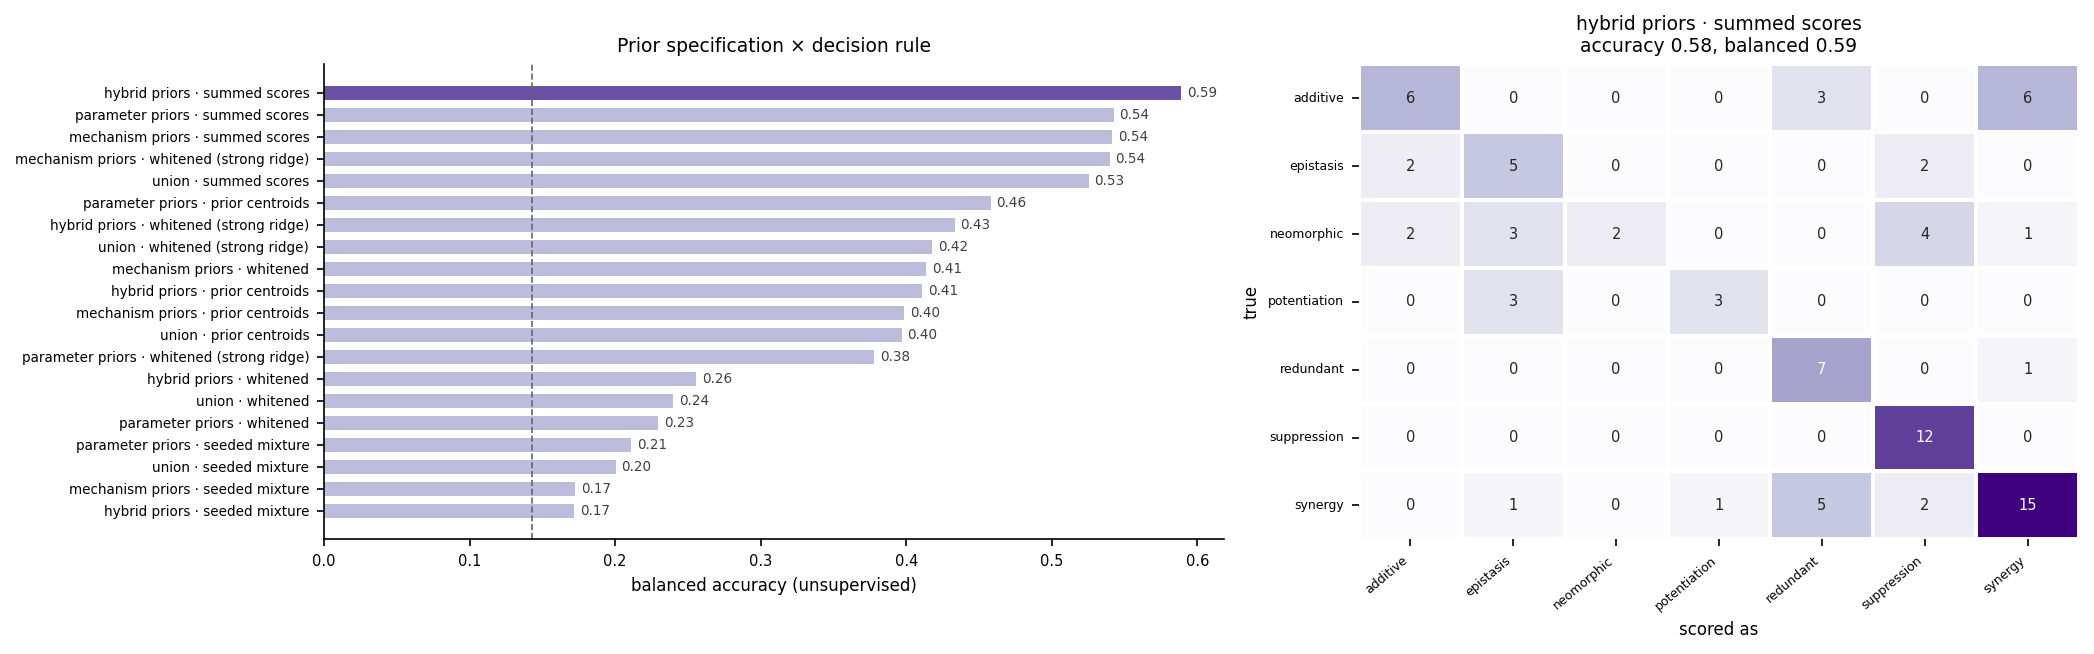

,scheme,accuracy,balanced accuracy
15,hybrid priors · summed scores,0.581,0.589
5,parameter priors · summed scores,0.547,0.542
0,mechanism priors · summed scores,0.512,0.542
2,mechanism priors · whitened (strong ridge),0.512,0.540
10,union · summed scores,0.535,0.525
8,parameter priors · prior centroids,0.488,0.458
17,hybrid priors · whitened (strong ridge),0.430,0.433
12,union · whitened (strong ridge),0.419,0.418
1,mechanism priors · whitened,0.326,0.414
18,hybrid priors · prior centroids,0.477,0.411


In [51]:
from sklearn.mixture import GaussianMixture
from scipy.linalg import pinvh

SPECS = {'mechanism priors': PRIORS, 'parameter priors': PRIORS2, 'union': PRIORS3,
         'hybrid priors': PRIORS_HYB}

def _feature_matrix(priors):
    used = sorted({mt for spec in priors.values() for _, mt in spec})
    Zu = (gp[used] - gp[used].mean()) / gp[used].std()
    return used, Zu.values

def whitened_pct(priors, ridge=1e-2):
    used, Xm = _feature_matrix(priors)
    Sinv = pinvh(np.cov(Xm.T) + ridge * np.eye(Xm.shape[1]))
    out = {}
    for cls, spec in priors.items():
        w = np.zeros(len(used))
        for wt, mt in spec:
            w[used.index(mt)] += wt
        w = w / (np.linalg.norm(w) + 1e-12)
        out[cls] = Xm @ (Sinv @ w)
    sc_ = pd.DataFrame(out, index=gp.index)[GI_ORDER]
    return sc_.rank(pct=True)

def seeded_mixture(priors, top_frac=0.05, seed=0, kind='gmm'):
    used, Xm = _feature_matrix(priors)
    pcs = PCA(n_components=min(10, Xm.shape[1]), random_state=seed).fit_transform(Xm)
    sc_ = whitened_pct(priors)
    means = np.stack([pcs[sc_[cls].values >= np.quantile(sc_[cls].values, 1 - top_frac)].mean(0) for cls in GI_ORDER])
    if kind == 'centroid':
        d = ((pcs[:, None, :] - means[None]) ** 2).sum(-1)
        return np.array(GI_ORDER)[d.argmin(1)]
    gm = GaussianMixture(n_components=len(GI_ORDER), means_init=means, covariance_type='diag',
                         reg_covar=1e-2, max_iter=200, random_state=seed).fit(pcs)
    return np.array(GI_ORDER)[gm.predict(pcs)]

rule_rows = []
for spec_name, priors in SPECS.items():
    p_sum = _pct_scores(priors).idxmax(1).values
    rule_rows.append(_evaluate(p_sum, f'{spec_name} · summed scores')[0])
    for rg, tag in [(1e-2, 'whitened'), (0.5, 'whitened (strong ridge)')]:
        rule_rows.append(_evaluate(whitened_pct(priors, ridge=rg).idxmax(1).values, f'{spec_name} · {tag}')[0])
    rule_rows.append(_evaluate(seeded_mixture(priors, kind='centroid'), f'{spec_name} · prior centroids')[0])
    rule_rows.append(_evaluate(seeded_mixture(priors, kind='gmm'), f'{spec_name} · seeded mixture')[0])
rules_df = pd.DataFrame(rule_rows).sort_values('balanced accuracy', ascending=False)
print(rules_df.round(3).to_string(index=False))

best_rule = rules_df.iloc[0]['scheme']
spec_key = [k for k in SPECS if best_rule.startswith(k)][0]
if 'whitened' in best_rule:
    best_pred = whitened_pct(SPECS[spec_key]).idxmax(1).values
elif 'centroids' in best_rule:
    best_pred = seeded_mixture(SPECS[spec_key], kind='centroid')
elif 'mixture' in best_rule:
    best_pred = seeded_mixture(SPECS[spec_key], kind='gmm')
else:
    best_pred = _pct_scores(SPECS[spec_key]).idxmax(1).values
_, ev_best = _evaluate(best_pred, best_rule)
print(f"\nBest rule: {best_rule}")
print('per-class recall:', {short[c]: round(float((ev_best.loc[ev_best['gi'] == c, 'p'] == c).mean()), 2) for c in GI_ORDER})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={'width_ratios': [1.25, 1]})
ax = axes[0]
ypos = np.arange(len(rules_df))
ax.barh(ypos, rules_df['balanced accuracy'],
        color=['#6a51a3' if i == 0 else '#bcbddc' for i in range(len(rules_df))], height=0.62)
for n, v in enumerate(rules_df['balanced accuracy']):
    ax.text(v + 0.004, n, f'{v:.2f}', va='center', fontsize=6.5, color='0.25')
ax.set_yticks(ypos); ax.set_yticklabels(rules_df['scheme'], fontsize=6.5)
ax.invert_yaxis(); ax.axvline(1 / 7, color='0.4', ls='--', lw=0.8)
ax.set_xlabel('balanced accuracy (unsupervised)')
ax.set_title('Prior specification × decision rule')

cmb = confusion_matrix(ev_best['gi'], ev_best['p'], labels=GI_ORDER)
sns.heatmap(cmb, cmap='Purples', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=axes[1])
axes[1].set_xlabel('scored as'); axes[1].set_ylabel('true')
axes[1].set_title(f'{best_rule}\naccuracy {np.mean(ev_best["p"] == ev_best["gi"]):.2f}, '
                  f'balanced {balanced_accuracy_score(ev_best["gi"], ev_best["p"]):.2f}')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=6)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()
rules_df.round(3)

### 11e. A readable rule cascade

The scoring schemes above are hard to read. This is the same knowledge written as a cascade of
explicit cuts on the model's parameters — "high ρ and shared gates with a damped scale is redundant,
the same with a positive synergy term is synergy", and so on. Thresholds are quantiles of the
all-pairs distribution, so each cut has a plain reading ("above the 60th percentile of gene pairs").

```
epistasis     : one parent's scale dominates (c_ratio high) and the combination sits on that parent
redundant     : ρ high, gates shared, scales damped, synergy small   -> the pair acts like one parent
synergy       : ρ high, gates shared, combination exceeds the sum
additive      : ρ high, gates shared, combination ≈ the sum
potentiation  : gates disjoint (private factors), scales up
suppression   : ρ low, scales damped, combination smaller than the sum
neomorphic    : ρ low, synergy opens factors neither parent gates, combination not damped
```

In [52]:
from sklearn.tree import DecisionTreeClassifier, export_text

RULE_FEATURES = ['rho', 'gate_overlap', 'c_sum', 'syn_rel', 'c_ratio', 'dominant_parent_fit',
                 'joint_over_add', 'combo_novel_frac', 'syn_offgate_frac', 'private_frac']
Q = {f: gp[f].quantile for f in RULE_FEATURES}          # cuts are quantiles over all 5460 pairs

DEFAULT_CUTS = {'rho_hi': 0.60, 'gate_hi': 0.55, 'c_lo': 0.35, 'c_hi': 0.65, 'syn_hi': 0.60,
                'cratio_hi': 0.75, 'domfit_hi': 0.50, 'joint_hi': 0.55, 'joint_lo': 0.45,
                'novel_hi': 0.65, 'priv_hi': 0.60}

def classify_rules(df, cuts):
    t = {k: Q[f](v) for (k, v), f in zip(cuts.items(),
         ['rho', 'gate_overlap', 'c_sum', 'c_sum', 'syn_rel', 'c_ratio', 'dominant_parent_fit',
          'joint_over_add', 'joint_over_add', 'combo_novel_frac', 'private_frac'])}
    out = []
    for _, r in df.iterrows():
        if r['c_ratio'] > t['cratio_hi'] and r['dominant_parent_fit'] > t['domfit_hi']:
            out.append('epistasis')
        elif r['rho'] > t['rho_hi'] and r['gate_overlap'] > t['gate_hi']:
            if r['c_sum'] < t['c_lo'] and r['syn_rel'] < t['syn_hi']:
                out.append('redundant')
            elif r['joint_over_add'] > t['joint_hi'] or r['syn_rel'] > t['syn_hi']:
                out.append('synergy')
            else:
                out.append('approximately additive')
        elif r['gate_overlap'] <= t['gate_hi'] and r['private_frac'] > t['priv_hi'] and r['c_sum'] > t['c_hi']:
            out.append('potentiation')
        elif r['c_sum'] < t['c_lo'] and r['joint_over_add'] < t['joint_lo']:
            out.append('suppression')
        elif r['combo_novel_frac'] > t['novel_hi'] or r['syn_offgate_frac'] > t['novel_hi']:
            out.append('neomorphic')
        else:
            out.append('approximately additive')
    return np.array(out)

gt_feat = pairs_df[['combination', 'gi']].merge(gp[['combination'] + RULE_FEATURES], on='combination')
pred_default = classify_rules(gt_feat, DEFAULT_CUTS)
print(f'Hand-set quantile cuts : accuracy {np.mean(pred_default == gt_feat["gi"]):.3f}  '
      f'balanced {balanced_accuracy_score(gt_feat["gi"], pred_default):.3f}')

# Light tuning: each cut is moved over a small grid of quantiles, two passes, everything else fixed.
cuts = dict(DEFAULT_CUTS)
grid = np.arange(0.25, 0.85, 0.05)
for _ in range(2):
    for k in cuts:
        best_v, best_s = cuts[k], balanced_accuracy_score(gt_feat['gi'], classify_rules(gt_feat, cuts))
        for v in grid:
            trial = dict(cuts); trial[k] = float(v)
            s = balanced_accuracy_score(gt_feat['gi'], classify_rules(gt_feat, trial))
            if s > best_s:
                best_v, best_s = float(v), s
        cuts[k] = best_v
pred_tuned = classify_rules(gt_feat, cuts)
acc_t = np.mean(pred_tuned == gt_feat['gi']); bal_t = balanced_accuracy_score(gt_feat['gi'], pred_tuned)
print(f'Tuned quantile cuts    : accuracy {acc_t:.3f}  balanced {bal_t:.3f}')
print('per-class recall:', {short[c]: round(float((pred_tuned[gt_feat["gi"].values == c] == c).mean()), 2)
                            for c in GI_ORDER})

# Reference: let a shallow decision tree find its own rules from the labels
tree = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=0).fit(
    gt_feat[RULE_FEATURES].values, gt_feat['gi'].values)
pt = tree.predict(gt_feat[RULE_FEATURES].values)
print(f'\nSupervised depth-4 tree (in-sample, for reference): accuracy {np.mean(pt == gt_feat["gi"]):.3f}  '
      f'balanced {balanced_accuracy_score(gt_feat["gi"], pt):.3f}')

print('\nFinal cuts (quantile of all 5460 gene pairs -> value):')
_names = ['rho', 'gate_overlap', 'c_sum', 'c_sum', 'syn_rel', 'c_ratio', 'dominant_parent_fit',
          'joint_over_add', 'joint_over_add', 'combo_novel_frac', 'private_frac']
for (k, v), f in zip(cuts.items(), _names):
    print(f'  {k:11s} = {f} at q{v:.2f}  ->  {Q[f](v):.3f}')

Hand-set quantile cuts : accuracy 0.349  balanced 0.248


Tuned quantile cuts    : accuracy 0.558  balanced 0.530
per-class recall: {'additive': 0.33, 'epistasis': 0.33, 'neomorphic': 0.5, 'potentiation': 0.67, 'redundant': 0.38, 'suppression': 0.75, 'synergy': 0.75}

Supervised depth-4 tree (in-sample, for reference): accuracy 0.802  balanced 0.852

Final cuts (quantile of all 5460 gene pairs -> value):
  rho_hi      = rho at q0.75  ->  0.326
  gate_hi     = gate_overlap at q0.30  ->  0.424
  c_lo        = c_sum at q0.25  ->  1.568
  c_hi        = c_sum at q0.25  ->  1.568
  syn_hi      = syn_rel at q0.75  ->  0.357
  cratio_hi   = c_ratio at q0.35  ->  0.036
  domfit_hi   = dominant_parent_fit at q0.65  ->  0.786
  joint_hi    = joint_over_add at q0.65  ->  1.175
  joint_lo    = joint_over_add at q0.50  ->  1.135
  novel_hi    = combo_novel_frac at q0.25  ->  0.331
  priv_hi     = private_frac at q0.60  ->  0.313


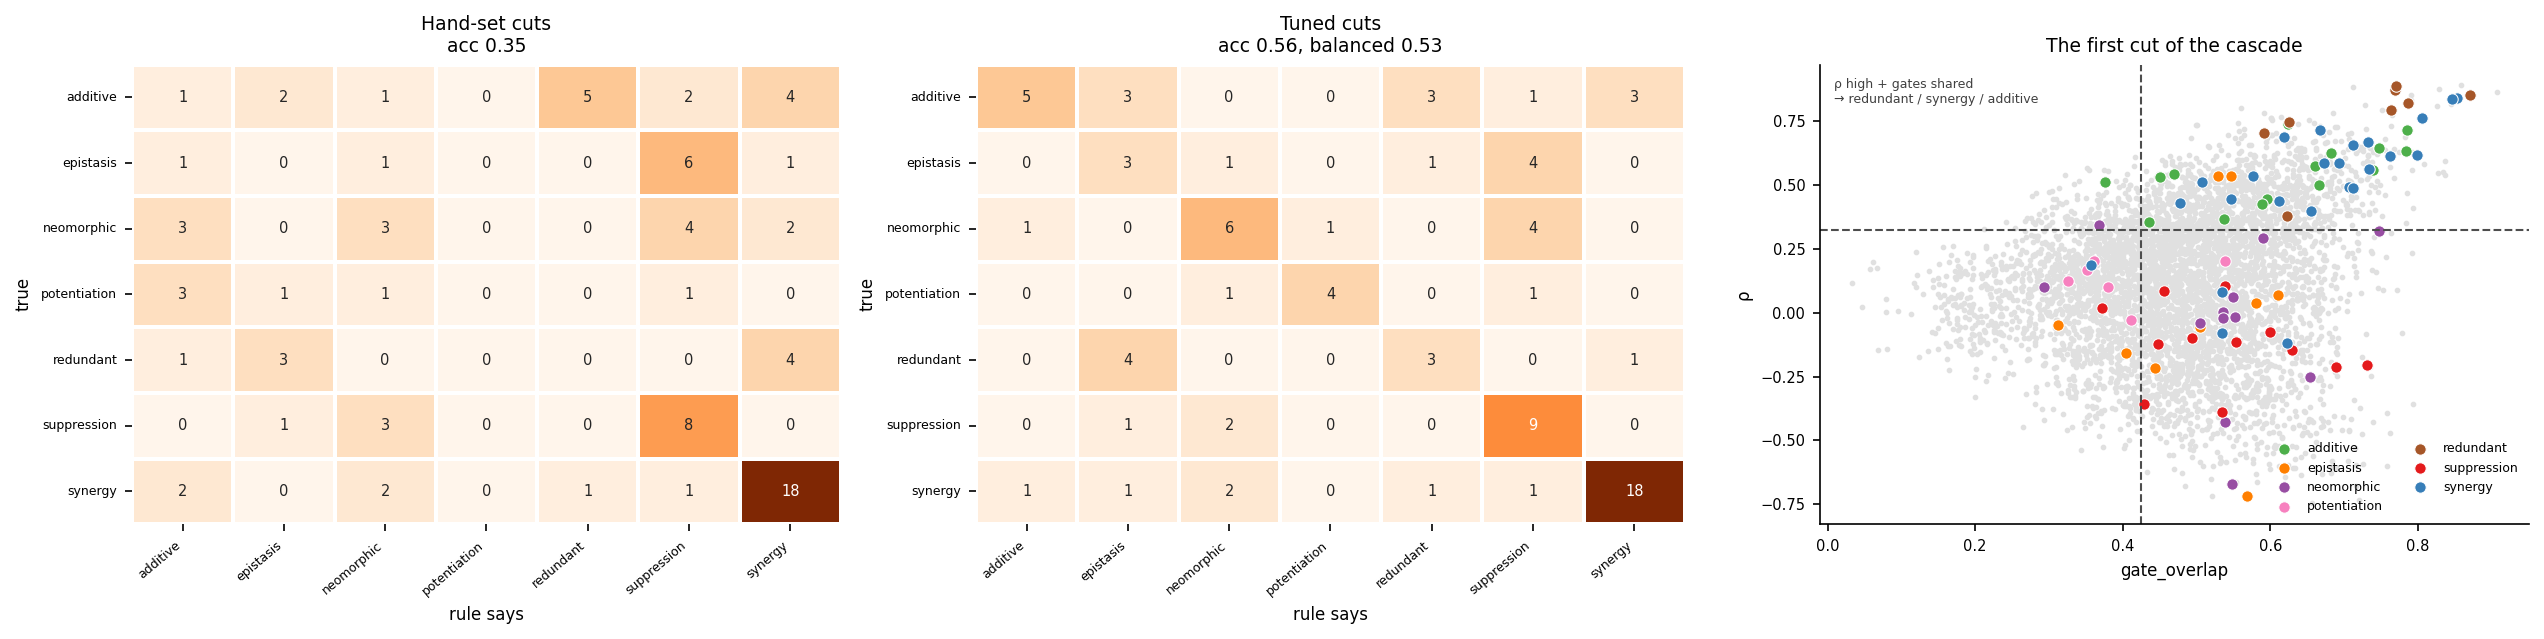

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={'width_ratios': [1, 1, 1]})
for ax, pred, title in [(axes[0], pred_default, f'Hand-set cuts\nacc {np.mean(pred_default == gt_feat["gi"]):.2f}'),
                        (axes[1], pred_tuned, f'Tuned cuts\nacc {acc_t:.2f}, balanced {bal_t:.2f}')]:
    cm = confusion_matrix(gt_feat['gi'], pred, labels=GI_ORDER)
    sns.heatmap(cm, cmap='Oranges', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1,
                linecolor='white', xticklabels=[short[c] for c in GI_ORDER],
                yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=ax)
    ax.set_xlabel('rule says'); ax.set_ylabel('true'); ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)

# the first split, drawn: rho x gate_overlap with the cuts shown
ax = axes[2]
ax.scatter(gp['gate_overlap'], gp['rho'], s=3, color='0.88', rasterized=True)
for c in GI_ORDER:
    sub = gt_feat[gt_feat['gi'] == c]
    ax.scatter(sub['gate_overlap'], sub['rho'], s=30, color=PALETTE_GI[c], edgecolor='white', lw=0.5, label=short[c])
ax.axvline(Q['gate_overlap'](cuts['gate_hi']), color='0.3', ls='--', lw=1)
ax.axhline(Q['rho'](cuts['rho_hi']), color='0.3', ls='--', lw=1)
ax.text(0.02, 0.97, 'ρ high + gates shared\n→ redundant / synergy / additive', transform=ax.transAxes,
        fontsize=6, va='top', color='0.25')
ax.set_xlabel('gate_overlap'); ax.set_ylabel('ρ')
ax.legend(frameon=False, fontsize=6, loc='lower right', ncol=2)
ax.set_title('The first cut of the cascade')
plt.tight_layout()
plt.show()

### 11f. Mined rules: let the data pick the cuts, then read them back

The cascade in §11e guessed both the *order* of the questions and the cuts. Here the cuts are fit to
the 86 labelled pairs — deliberate data snooping, so that the result is a readable statement about
how model parameters relate to interactions, not a generalisation estimate.

For every class, an exhaustive search over **all pairs of model-parameter descriptors** and quantile
thresholds finds the single conjunction `A <op> t₁ AND B <op> t₂` with the best F1 for that class. The
rules are then applied as a cascade, most precise first. Each rule is one readable sentence about the
model's parameters.

In [54]:
RULE_POOL = [f for f in ['rho', 'pcorr', 'rho_minus_pcorr', 'concordance', 'sign_conflict', 'latent_cos',
                         'gate_overlap', 'private_frac', 'n_shared', 'mag_asym', 'mag_mean',
                         'c_mean', 'c_sum', 'c_diff', 'c_ratio', 'syn_rel', 'syn_orth_frac',
                         'syn_par_cos_add', 'syn_perp_novelgene', 'syn_offgate_frac', 'syn_ongate_cos',
                         'combo_over_maxparent', 'combo_over_add_lat', 'dist_to_dominant',
                         'dom_gap', 'parent_coef_asym', 'dominant_parent_fit', 'add_fit',
                         'combo_novel_frac', 'joint_over_add', 'cls_min_parent', 'cls_parent_gap',
                         'nn_parent_cos', 'nn_parent_minus_other', 'sat_erythroid']
             if f in gp.columns]
gt_r = pairs_df[['combination', 'gi']].merge(gp[['combination'] + RULE_POOL], on='combination')
Xr = gt_r[RULE_POOL].values
yr = gt_r['gi'].values
QS = np.arange(0.15, 0.90, 0.05)

# every atomic condition: feature above / below a quantile of the ALL-PAIRS distribution
atoms, atom_txt = [], []
for fi, f in enumerate(RULE_POOL):
    for q in QS:
        thr = gp[f].quantile(q)
        atoms.append(Xr[:, fi] > thr); atom_txt.append((f, '>', q, thr))
        atoms.append(Xr[:, fi] <= thr); atom_txt.append((f, '<=', q, thr))
atoms = np.array(atoms)
print(f'{len(RULE_POOL)} descriptors -> {len(atoms)} atomic conditions, searching all pairs '
      f'({len(atoms) * (len(atoms) - 1) // 2:,} conjunctions) per class')

def best_rule(mask_target, min_support=3):
    y = mask_target.astype(float)
    n_pos = y.sum()
    best = (0, None, None)
    for i in range(len(atoms)):
        ai = atoms[i]
        if ai.sum() < min_support:
            continue
        both = atoms[i:] & ai
        tp = both @ y
        sup = both.sum(1)
        ok = sup >= min_support
        f1 = np.where(ok, 2 * tp / np.maximum(sup + n_pos, 1e-9), 0)
        j = int(np.argmax(f1))
        if f1[j] > best[0]:
            best = (float(f1[j]), i, i + j)
    return best

rules = {}
for cls in GI_ORDER:
    f1, i, j = best_rule(yr == cls)
    m = atoms[i] & atoms[j]
    prec = (yr[m] == cls).mean() if m.sum() else 0
    rules[cls] = {'f1': f1, 'precision': prec, 'support': int(m.sum()),
                  'recall': float((m & (yr == cls)).sum() / (yr == cls).sum()),
                  'terms': (atom_txt[i], atom_txt[j]), 'mask': m}

def _fmt(t):
    f, op, q, thr = t
    return f'{f} {op} {thr:.3g} (q{q:.2f})'

order = sorted(GI_ORDER, key=lambda c: -rules[c]['precision'])
pred_rules = np.array(['approximately additive'] * len(yr), dtype=object)
assigned = np.zeros(len(yr), bool)
for cls in order:
    take = rules[cls]['mask'] & ~assigned
    pred_rules[take] = cls
    assigned |= take
acc_r = np.mean(pred_rules == yr); bal_r = balanced_accuracy_score(yr, pred_rules)
print(f'\nMined rule cascade: accuracy {acc_r:.3f}, balanced {bal_r:.3f}  '
      f'(unassigned pairs fall through to additive: {(~assigned).sum()})')
print('per-class recall:', {short[c]: round(float((pred_rules[yr == c] == c).mean()), 2) for c in GI_ORDER})
print('\nRules, applied in this order:')
for cls in order:
    r = rules[cls]
    print(f"  {short[cls]:12s}: {_fmt(r['terms'][0])}  AND  {_fmt(r['terms'][1])}"
          f"   [precision {r['precision']:.2f}, covers {r['support']} pairs]")

35 descriptors -> 1050 atomic conditions, searching all pairs (550,725 conjunctions) per class



Mined rule cascade: accuracy 0.709, balanced 0.714  (unassigned pairs fall through to additive: 15)
per-class recall: {'additive': 0.67, 'epistasis': 0.67, 'neomorphic': 0.5, 'potentiation': 0.83, 'redundant': 0.75, 'suppression': 0.83, 'synergy': 0.75}

Rules, applied in this order:
  potentiation: syn_perp_novelgene <= 0.611 (q0.40)  AND  combo_over_add_lat > 1.11 (q0.80)   [precision 1.00, covers 5 pairs]
  redundant   : concordance > 0.731 (q0.75)  AND  combo_over_add_lat <= 0.917 (q0.15)   [precision 1.00, covers 6 pairs]
  epistasis   : dom_gap > 0.642 (q0.85)  AND  add_fit > 0.565 (q0.20)   [precision 0.86, covers 7 pairs]
  suppression : c_mean <= 0.751 (q0.20)  AND  combo_novel_frac > 0.355 (q0.40)   [precision 0.83, covers 12 pairs]
  additive    : latent_cos > 0.476 (q0.75)  AND  nn_parent_cos <= 0.944 (q0.65)   [precision 0.77, covers 13 pairs]
  synergy     : sign_conflict <= 0.0449 (q0.20)  AND  joint_over_add > 1.08 (q0.35)   [precision 0.74, covers 27 pairs]
  neomorph

Depth-4 tree: accuracy 0.860, balanced 0.879, 13 leaves
Depth-5 tree: accuracy 0.895, balanced 0.925, 16 leaves

|--- rho <= 0.35
|   |--- dom_gap <= 0.70
|   |   |--- dist_to_dominant <= 0.48
|   |   |   |--- latent_cos <= 0.31
|   |   |   |   |--- class: potentiation
|   |   |   |--- latent_cos >  0.31
|   |   |   |   |--- class: potentiation
|   |   |--- dist_to_dominant >  0.48
|   |   |   |--- parent_coef_asym <= 0.46
|   |   |   |   |--- class: suppression
|   |   |   |--- parent_coef_asym >  0.46
|   |   |   |   |--- class: neomorphic
|   |--- dom_gap >  0.70
|   |   |--- c_mean <= 0.75
|   |   |   |--- class: epistasis
|   |   |--- c_mean >  0.75
|   |   |   |--- class: neomorphic
|--- rho >  0.35
|   |--- pcorr <= 0.05
|   |   |--- concordance <= 0.83
|   |   |   |--- mag_asym <= 0.63
|   |   |   |   |--- class: approximately additive
|   |   |   |--- mag_asym >  0.63
|   |   |   |   |--- class: epistasis
|   |   |--- concordance >  0.83
|   |   |   |--- dominant_parent_fit <=

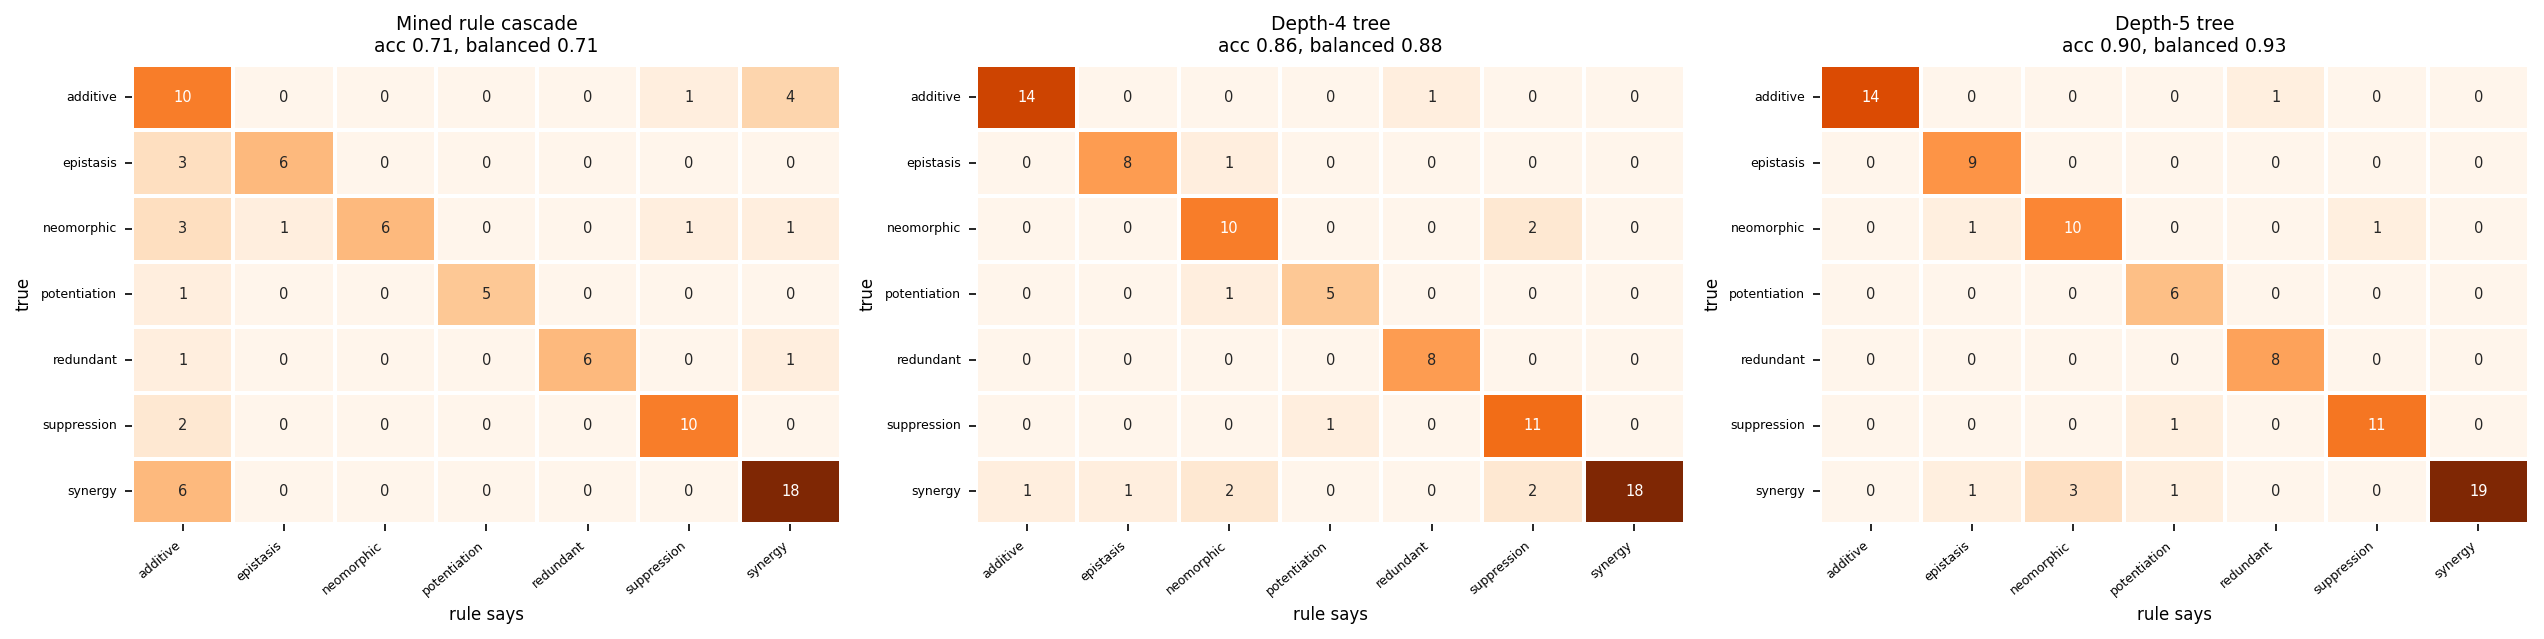

In [55]:
# A shallow tree over the same descriptors, for comparison, and its rules in plain text
tree2 = DecisionTreeClassifier(max_depth=4, class_weight='balanced', min_samples_leaf=3,
                               random_state=0).fit(Xr, yr)
pt2 = tree2.predict(Xr)
print(f'Depth-4 tree: accuracy {np.mean(pt2 == yr):.3f}, balanced {balanced_accuracy_score(yr, pt2):.3f}, '
      f'{tree2.get_n_leaves()} leaves')
tree5 = DecisionTreeClassifier(max_depth=5, class_weight='balanced', min_samples_leaf=2,
                               random_state=0).fit(Xr, yr)
pt5 = tree5.predict(Xr)
print(f'Depth-5 tree: accuracy {np.mean(pt5 == yr):.3f}, balanced {balanced_accuracy_score(yr, pt5):.3f}, '
      f'{tree5.get_n_leaves()} leaves')
print('\n' + export_text(tree2, feature_names=RULE_POOL, decimals=2))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, pred, title in [(axes[0], pred_rules, f'Mined rule cascade\nacc {acc_r:.2f}, balanced {bal_r:.2f}'),
                        (axes[1], pt2, f'Depth-4 tree\nacc {np.mean(pt2 == yr):.2f}, '
                                       f'balanced {balanced_accuracy_score(yr, pt2):.2f}'),
                        (axes[2], pt5, f'Depth-5 tree\nacc {np.mean(pt5 == yr):.2f}, '
                                       f'balanced {balanced_accuracy_score(yr, pt5):.2f}')]:
    cm = confusion_matrix(yr, pred, labels=GI_ORDER)
    sns.heatmap(cm, cmap='Oranges', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1,
                linecolor='white', xticklabels=[short[c] for c in GI_ORDER],
                yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=ax)
    ax.set_xlabel('rule says'); ax.set_ylabel('true'); ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

### 11g. A minimal descriptor set

The rule search above drew on 35 descriptors. This section restricts it to one measure per idea:

| Idea | Descriptor |
|---|---|
| direction | `rho` |
| direct coupling (only if needed) | `pcorr` |
| which factors | `gate_overlap`, `n_shared`, `private_frac` |
| latent alignment of A⊙W | `latent_cos` |
| parent scales | `c_sum` (magnitude), `c_ratio` (dominance) |
| synergy term | `syn_rel` (magnitude), `syn_cos_add` (alignment with the additive shift) |
| decoder: dominance (pick ≤ 2) | `dom_gap`, `dominant_parent_fit`, `parent_coef_asym` |
| decoder: neomorphism (pick ≤ 2) | `combo_novel_frac`, `joint_over_add`, `syn_offgate_frac` |

Every combination of the optional slots is tried with the one-conjunction-per-class rule cascade from
§11f, with and without `pcorr`. The best set is then pruned feature by feature for as long as
accuracy stays above 0.7.

In [56]:
from itertools import combinations as _comb

CORE = ['rho', 'gate_overlap', 'n_shared', 'private_frac', 'latent_cos', 'c_sum', 'c_ratio', 'syn_rel', 'syn_cos_add']
DOM_OPTS = ['dom_gap', 'dominant_parent_fit', 'parent_coef_asym']
NEO_OPTS = ['combo_novel_frac', 'joint_over_add', 'syn_offgate_frac']
ALL_MIN = CORE + ['pcorr'] + DOM_OPTS + NEO_OPTS
gt_min = pairs_df[['combination', 'gi']].merge(gp[['combination'] + ALL_MIN], on='combination')
y_min = gt_min['gi'].values

def mine_cascade(pool, qs=np.arange(0.15, 0.90, 0.05), min_support=3):
    X = gt_min[pool].values
    atoms_, txt_ = [], []
    for fi, f in enumerate(pool):
        for q in qs:
            thr = gp[f].quantile(q)
            atoms_.append(X[:, fi] > thr); txt_.append((f, '>', q, thr))
            atoms_.append(X[:, fi] <= thr); txt_.append((f, '<=', q, thr))
    A_ = np.array(atoms_)
    rules_ = {}
    for cls in GI_ORDER:
        y = (y_min == cls).astype(float); npos = y.sum()
        best = (0.0, 0, 0)
        for i in range(len(A_)):
            if A_[i].sum() < min_support:
                continue
            both = A_[i:] & A_[i]
            tp = both @ y; sup = both.sum(1)
            f1 = np.where(sup >= min_support, 2 * tp / np.maximum(sup + npos, 1e-9), 0)
            j = int(np.argmax(f1))
            if f1[j] > best[0]:
                best = (float(f1[j]), i, i + j)
        _, i, j = best
        m = A_[i] & A_[j]
        rules_[cls] = {'precision': (y_min[m] == cls).mean() if m.sum() else 0.0, 'mask': m,
                       'terms': (txt_[i], txt_[j]) if i != j else (txt_[i],), 'support': int(m.sum())}
    order_ = sorted(GI_ORDER, key=lambda c: -rules_[c]['precision'])
    pred = np.array(['approximately additive'] * len(y_min), dtype=object)
    done = np.zeros(len(y_min), bool)
    for c in order_:
        take = rules_[c]['mask'] & ~done
        pred[take] = c; done |= take
    return float(np.mean(pred == y_min)), float(balanced_accuracy_score(y_min, pred)), pred, rules_, order_

grid_rows = []
for use_p in (False, True):
    for kd in (1, 2):
        for dom in _comb(DOM_OPTS, kd):
            for kn in (1, 2):
                for neo in _comb(NEO_OPTS, kn):
                    pool = CORE + (['pcorr'] if use_p else []) + list(dom) + list(neo)
                    acc_, bal_, *_ = mine_cascade(pool)
                    grid_rows.append({'pcorr': use_p, 'dominance': ', '.join(dom), 'neomorphism': ', '.join(neo),
                                      'n_features': len(pool), 'accuracy': acc_, 'balanced accuracy': bal_})
grid = pd.DataFrame(grid_rows).sort_values(['accuracy', 'balanced accuracy'], ascending=False)
print(f"Configurations reaching > 0.7 accuracy: {(grid['accuracy'] > 0.7).sum()} / {len(grid)} "
      f"(without pcorr: {((grid['accuracy'] > 0.7) & ~grid['pcorr']).sum()})")
grid.head(12).round(3)

Configurations reaching > 0.7 accuracy: 27 / 72 (without pcorr: 13)


,pcorr,dominance,neomorphism,n_features,accuracy,balanced accuracy
9,False,dominant_parent_fit,"combo_novel_frac, joint_over_add",12,0.733,0.734
45,True,dominant_parent_fit,"combo_novel_frac, joint_over_add",13,0.733,0.734
1,False,dom_gap,joint_over_add,11,0.709,0.723
5,False,dom_gap,"joint_over_add, syn_offgate_frac",12,0.709,0.723
19,False,"dom_gap, dominant_parent_fit",joint_over_add,12,0.709,0.723
23,False,"dom_gap, dominant_parent_fit","joint_over_add, syn_offgate_frac",13,0.709,0.723
25,False,"dom_gap, parent_coef_asym",joint_over_add,12,0.709,0.723
29,False,"dom_gap, parent_coef_asym","joint_over_add, syn_offgate_frac",13,0.709,0.723
37,True,dom_gap,joint_over_add,12,0.709,0.723
41,True,dom_gap,"joint_over_add, syn_offgate_frac",13,0.709,0.723


            removed  n_features  accuracy  balanced accuracy
            (start)          12     0.733              0.734
       gate_overlap          11     0.744              0.746
        syn_cos_add          10     0.744              0.746
         latent_cos           9     0.744              0.746
dominant_parent_fit           8     0.744              0.746
            c_ratio           7     0.744              0.746
   combo_novel_frac           6     0.744              0.746
           n_shared           5     0.733              0.746

Minimal set (5 descriptors): ['rho', 'private_frac', 'c_sum', 'syn_rel', 'joint_over_add']
Rule cascade: accuracy 0.733, balanced 0.746
per-class recall: {'additive': 0.67, 'epistasis': 0.56, 'neomorphic': 0.75, 'potentiation': 1.0, 'redundant': 0.75, 'suppression': 0.75, 'synergy': 0.75}

Rules, applied in this order:
  additive    : c_sum <= 1.88 (q0.55)  AND  syn_rel <= 0.173 (q0.25)   [precision 0.88, covers 8]
  redundant   : rho > 0.36 (q0.

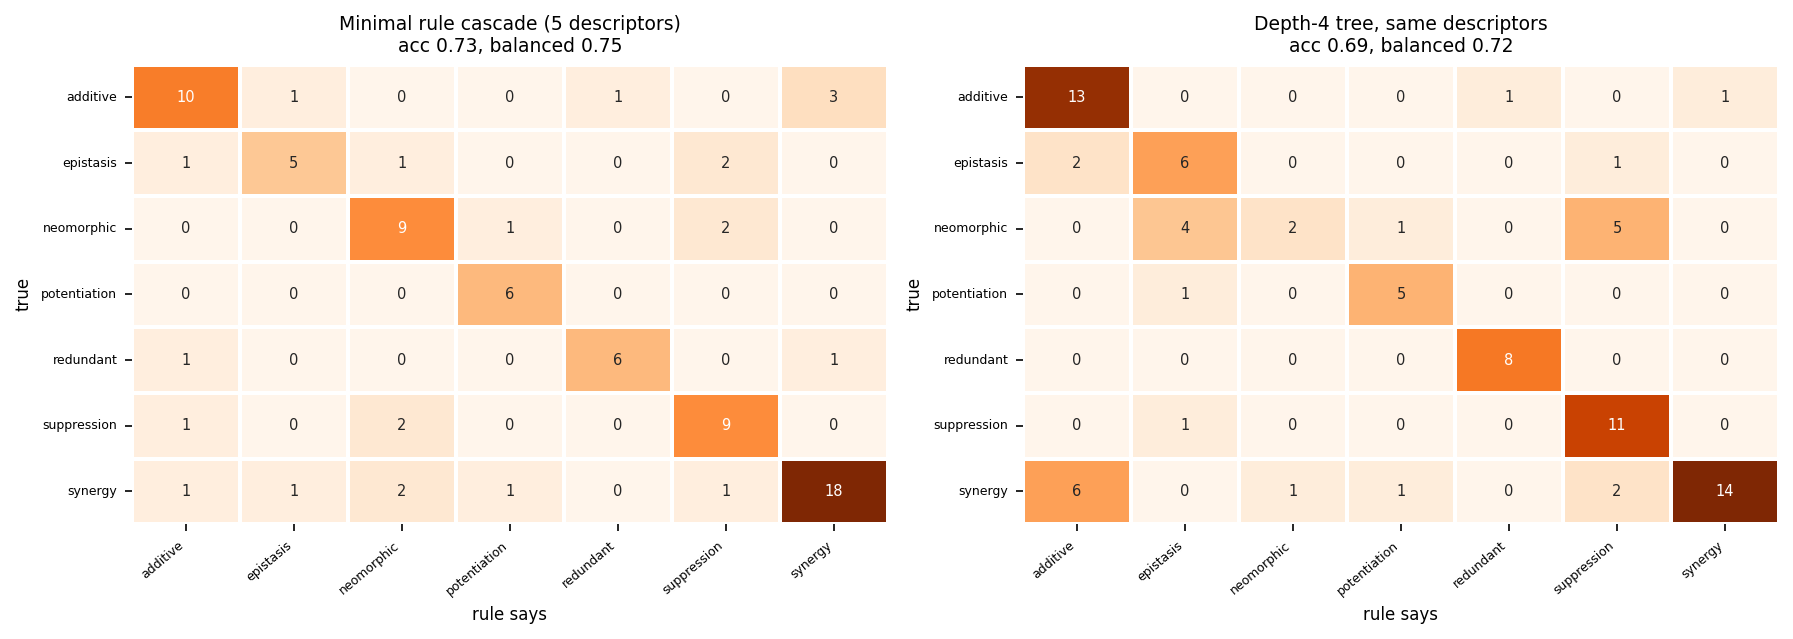

In [57]:
# Start from the best configuration WITHOUT pcorr if one clears 0.7, else the best overall,
# then drop features one at a time while accuracy stays above 0.7.
cand = grid[(grid['accuracy'] > 0.7) & ~grid['pcorr']]
start = (cand if len(cand) else grid).iloc[0]
pool = CORE + (['pcorr'] if start['pcorr'] else []) + start['dominance'].split(', ') + start['neomorphism'].split(', ')
acc_cur, bal_cur, *_ = mine_cascade(pool)
prune_log = [{'removed': '(start)', 'n_features': len(pool), 'accuracy': acc_cur, 'balanced accuracy': bal_cur}]
while len(pool) > 2:
    trials = []
    for f in pool:
        a_, b_, *_ = mine_cascade([g for g in pool if g != f])
        trials.append((a_, b_, f))
    a_, b_, f = max(trials)
    if a_ <= 0.7:
        break
    pool = [g for g in pool if g != f]
    prune_log.append({'removed': f, 'n_features': len(pool), 'accuracy': a_, 'balanced accuracy': b_})
MINIMAL = pool
print(pd.DataFrame(prune_log).round(3).to_string(index=False))

acc_m, bal_m, pred_m, rules_m, order_m = mine_cascade(MINIMAL)
print(f'\nMinimal set ({len(MINIMAL)} descriptors): {MINIMAL}')
print(f'Rule cascade: accuracy {acc_m:.3f}, balanced {bal_m:.3f}')
print('per-class recall:', {short[c]: round(float((pred_m[y_min == c] == c).mean()), 2) for c in GI_ORDER})
print('\nRules, applied in this order:')
for c in order_m:
    r = rules_m[c]
    body = '  AND  '.join(f'{f} {op} {thr:.3g} (q{q:.2f})' for f, op, q, thr in r['terms'])
    print(f"  {short[c]:12s}: {body}   [precision {r['precision']:.2f}, covers {r['support']}]")

tree_m = DecisionTreeClassifier(max_depth=4, class_weight='balanced', min_samples_leaf=3, random_state=0)
pt_m = tree_m.fit(gt_min[MINIMAL].values, y_min).predict(gt_min[MINIMAL].values)
print(f'\nDepth-4 tree on the same {len(MINIMAL)} descriptors: accuracy {np.mean(pt_m == y_min):.3f}, '
      f'balanced {balanced_accuracy_score(y_min, pt_m):.3f}, {tree_m.get_n_leaves()} leaves')
print(export_text(tree_m, feature_names=MINIMAL, decimals=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, pred, title in [(axes[0], pred_m, f'Minimal rule cascade ({len(MINIMAL)} descriptors)\n'
                                          f'acc {acc_m:.2f}, balanced {bal_m:.2f}'),
                        (axes[1], pt_m, f'Depth-4 tree, same descriptors\nacc {np.mean(pt_m == y_min):.2f}, '
                                        f'balanced {balanced_accuracy_score(y_min, pt_m):.2f}')]:
    cm = confusion_matrix(y_min, pred, labels=GI_ORDER)
    sns.heatmap(cm, cmap='Oranges', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1,
                linecolor='white', xticklabels=[short[c] for c in GI_ORDER],
                yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=ax)
    ax.set_xlabel('rule says'); ax.set_ylabel('true'); ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

### 11h. Minimal set with an explicit dominance and neomorphism measure

Pruning alone drops the dominance and neomorphism descriptors, because the cascade can reach 0.7
without them — but then its epistasis and neomorphic rules degenerate into a magnitude band and a
catch-all. Here exactly **one dominance** and **one neomorphism** descriptor are added back to the
five-descriptor core, and a combination is preferred when the epistasis rule actually uses the
dominance term and the neomorphic rule actually uses the neomorphism term.

          dominance      neomorphism  n_features  accuracy  balanced accuracy  epistasis rule uses it  neomorphic rule uses it  neomorphic precision  epistasis precision  both used
            dom_gap syn_offgate_frac           7     0.709              0.728                    True                    False                 0.500                0.700      False
   parent_coef_asym syn_offgate_frac           7     0.698              0.724                    True                    False                 0.367                0.500      False
            dom_gap combo_novel_frac           7     0.698              0.714                    True                    False                 0.500                0.700      False
            c_ratio      syn_cos_add           7     0.698              0.711                    True                    False                 0.367                0.462      False
   parent_coef_asym      syn_cos_add           7     0.686              0.702                  

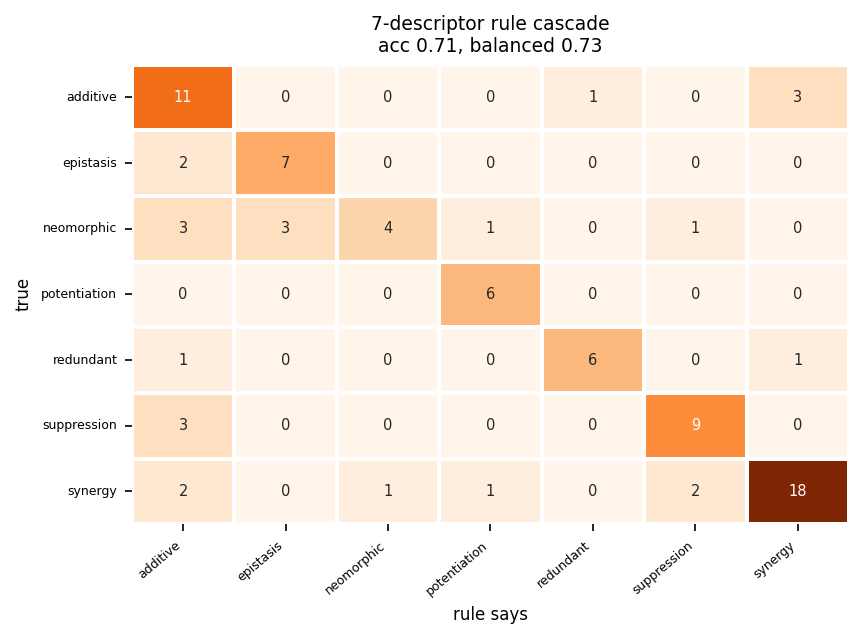

In [58]:
DOM_ALL = ['dom_gap', 'dominant_parent_fit', 'parent_coef_asym', 'c_ratio']
NEO_ALL = ['combo_novel_frac', 'syn_offgate_frac', 'syn_cos_add']
rows_h, store = [], {}
for d_ in DOM_ALL:
    for n_ in NEO_ALL:
        pool_h = [f for f in MINIMAL if f not in (d_, n_)] + [d_, n_]
        a_, b_, p_, r_, o_ = mine_cascade(pool_h)
        uses_dom = any(t[0] == d_ for t in r_['epistasis']['terms'])
        uses_neo = any(t[0] == n_ for t in r_['neomorphic']['terms'])
        rows_h.append({'dominance': d_, 'neomorphism': n_, 'n_features': len(pool_h), 'accuracy': a_,
                       'balanced accuracy': b_, 'epistasis rule uses it': uses_dom,
                       'neomorphic rule uses it': uses_neo,
                       'neomorphic precision': r_['neomorphic']['precision'],
                       'epistasis precision': r_['epistasis']['precision']})
        store[(d_, n_)] = (pool_h, a_, b_, p_, r_, o_)
hdf = pd.DataFrame(rows_h)
hdf['both used'] = hdf['epistasis rule uses it'] & hdf['neomorphic rule uses it']
hdf = hdf.sort_values(['both used', 'epistasis rule uses it', 'accuracy', 'balanced accuracy'], ascending=False)
print(hdf.round(3).to_string(index=False))
print(f"\nNo combination makes the neomorphic rule use a neomorphism descriptor "
      f"({hdf['neomorphic rule uses it'].sum()} of {len(hdf)}): neomorphic is picked out by exclusion.")

# Prefer a set whose epistasis rule genuinely uses the dominance term and still clears 0.7
ok = hdf[hdf['epistasis rule uses it'] & (hdf['accuracy'] > 0.7)]
pick = (ok if len(ok) else hdf).iloc[0]
pool_f, acc_f, bal_f, pred_f, rules_f, order_f = store[(pick['dominance'], pick['neomorphism'])]
FINAL_SET = pool_f
print(f'\nFinal interpretable set ({len(FINAL_SET)} descriptors): {FINAL_SET}')
print(f'Rule cascade: accuracy {acc_f:.3f}, balanced {bal_f:.3f}')
print('per-class recall:', {short[c]: round(float((pred_f[y_min == c] == c).mean()), 2) for c in GI_ORDER})
print('\nRules, applied in this order:')
for c in order_f:
    r = rules_f[c]
    body = '  AND  '.join(f'{f} {op} {thr:.3g} (q{q:.2f})' for f, op, q, thr in r['terms'])
    print(f"  {short[c]:12s}: {body}   [precision {r['precision']:.2f}, covers {r['support']}]")

fig, ax = plt.subplots(figsize=(5.8, 4.3))
cm = confusion_matrix(y_min, pred_f, labels=GI_ORDER)
sns.heatmap(cm, cmap='Oranges', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=ax)
ax.set_xlabel('rule says'); ax.set_ylabel('true')
ax.set_title(f'{len(FINAL_SET)}-descriptor rule cascade\nacc {acc_f:.2f}, balanced {bal_f:.2f}')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

### 11i. Neomorphism through the synergy term

In this architecture the combined latent state is c_a·S_a + c_b·S_b + syn, and the decoder is close to
additive across factors, so a genuinely new pathway can only come from **syn**. Two hypotheses:

- **H1 — syn creates a meaningful novel direction once decoded.** Decode what syn *adds* on top of the
  scaled parents: Δ_syn = g(u + c_a S_a + c_b S_b + syn) − g(u + c_a S_a + c_b S_b). If neomorphism lives
  here, Δ_syn should be large *and* point outside the gene-space span of the two parents' own effects.
- **H2 — syn explains a different axis than W.** The part of syn on factors that **neither** parent
  gates is decoded separately; if syn opens axes the gates do not, that part should carry real signal,
  and syn's novelty should be largely independent of the gate descriptors.

Metrics (all relative to the additive effect ‖D_a + D_b‖):

| Metric | Meaning |
|---|---|
| `syn_dec_rel` | ‖Δ_syn‖ — how much syn changes the decoded state |
| `syn_dec_orth` | fraction of Δ_syn outside span(D_a, D_b) — a new direction, not a re-weighting |
| `syn_novel_axis` | ‖component of Δ_syn outside the parents' span‖ — meaningful **and** novel |
| `syn_novel_genes` | ‖Δ_syn on genes neither parent moves‖ |
| `syn_offgate_dec` | ‖decoded effect of syn restricted to factors neither parent gates‖ |

In [59]:
N_BG_SYN = 128
_d = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
_d.X = _d.layers['counts'].copy()
slk.pp.slk_prepare_data(_d, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
_lab = _d.obs[slk.configs.get_config('pert_key')].astype(str).values
_d = _d[:, (np.asarray(_d.X.mean(0)).ravel() > 0.5) | _d.var_names.isin(set(genes))].copy()
_i = np.random.default_rng(2).choice(np.where(_lab == slk.configs.get_config('ntc_label'))[0], N_BG_SYN, replace=False)
x_syn = torch.tensor(_d.X[_i].toarray(), dtype=torch.float32, device=DEVICE)
del _d

SYN_NEO = ['syn_dec_rel', 'syn_dec_orth', 'syn_novel_axis', 'syn_novel_genes', 'syn_offgate_dec']
syn_neo_runs = []
for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(MODEL_DIR / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        sh = m._get_all_pert_shifts(DEVICE)[1:]
        S_, W_, q_ = sh[:, 0], sh[:, 1], sh[:, 2]
        u = m._abduct_ntc(x_syn)
        nbg = u.shape[0]

        def _ln_b(shift):
            z = (u[None] + shift[:, None]).reshape(-1, u.shape[-1])
            return torch.log1p(m._decode_to_expr(z, 1.) * 1e4).reshape(shift.shape[0], nbg, -1).mean(1)

        base = torch.log1p(m._decode_to_expr(u, 1.) * 1e4).mean(0)
        Dm = _ln_b(S_) - base
        act_g = Dm.abs() > torch.quantile(Dm.abs(), 0.9, dim=1, keepdim=True)
        out = {k: np.empty(len(IU[0]), dtype=np.float32) for k in SYN_NEO}
        for s in range(0, len(IU[0]), 64):
            A_b = torch.as_tensor(IU[0][s:s + 64], device=DEVICE)
            B_b = torch.as_tensor(IU[1][s:s + 64], device=DEVICE)
            ca, cb = m._parent_scales_from_rho(q_[A_b], q_[B_b])
            syn = m._synergy_shift_from_rho(q_[A_b], q_[B_b])
            lin = ca * S_[A_b] + cb * S_[B_b]
            g_lin = _ln_b(lin)
            d_syn = _ln_b(lin + syn) - g_lin                        # what syn adds, decoded
            off = ~((W_[A_b] > GATE_THR) | (W_[B_b] > GATE_THR))    # factors neither parent gates
            d_off = _ln_b(lin + syn * off) - g_lin
            Xp = torch.stack([Dm[A_b], Dm[B_b]], -1)
            coef = torch.linalg.lstsq(Xp, d_syn.unsqueeze(-1)).solution
            perp = d_syn - (Xp @ coef).squeeze(-1)                  # outside the parents' span
            addn = (Dm[A_b] + Dm[B_b]).norm(dim=1) + 1e-8
            novel = ~(act_g[A_b] | act_g[B_b])
            sl = slice(s, s + len(A_b))
            out['syn_dec_rel'][sl] = (d_syn.norm(dim=1) / addn).cpu().numpy()
            out['syn_dec_orth'][sl] = (perp.norm(dim=1) / (d_syn.norm(dim=1) + 1e-8)).cpu().numpy()
            out['syn_novel_axis'][sl] = (perp.norm(dim=1) / addn).cpu().numpy()
            out['syn_novel_genes'][sl] = ((d_syn * novel).norm(dim=1) / addn).cpu().numpy()
            out['syn_offgate_dec'][sl] = (d_off.norm(dim=1) / addn).cpu().numpy()
        syn_neo_runs.append(pd.DataFrame(out))
    del m
    torch.cuda.empty_cache()
del x_syn

syn_neo = sum(syn_neo_runs) / len(syn_neo_runs)
for k in SYN_NEO:
    gp[k] = syn_neo[k].values
print('cross-run stability:',
      {k: round(np.mean([spearmanr(syn_neo_runs[i][k], syn_neo_runs[j][k])[0] for i, j in pairs]), 2) for k in SYN_NEO})

gt_sn = pairs_df[['combination', 'gi']].merge(gp[['combination'] + SYN_NEO], on='combination')
print('\nclass means:')
print(gt_sn.groupby('gi')[SYN_NEO].mean().reindex(GI_ORDER).round(3).to_string())
print('\nAUROC, neomorphic vs every other class (> 0.5 = neomorphic is higher):')
for k in SYN_NEO:
    a_ = gt_sn.loc[gt_sn['gi'] == 'neomorphic', k]
    print(f'  {k:16s}', {short[c]: round(mannwhitneyu(a_, gt_sn.loc[gt_sn['gi'] == c, k]).statistic /
                                         (len(a_) * (gt_sn['gi'] == c).sum()), 2)
                         for c in GI_ORDER if c != 'neomorphic'})

cross-run stability: {'syn_dec_rel': np.float64(0.75), 'syn_dec_orth': np.float64(0.51), 'syn_novel_axis': np.float64(0.7), 'syn_novel_genes': np.float64(0.73), 'syn_offgate_dec': np.float64(0.53)}

class means:
                        syn_dec_rel  syn_dec_orth  syn_novel_axis  syn_novel_genes  syn_offgate_dec
gi                                                                                                 
approximately additive        0.304         0.686           0.204            0.208            0.093
epistasis                     0.451         0.586           0.245            0.262            0.141
neomorphic                    0.432         0.647           0.277            0.278            0.166
potentiation                  0.634         0.627           0.385            0.403            0.199
redundant                     0.337         0.613           0.195            0.217            0.099
suppression                   0.404         0.614           0.250            0.267      

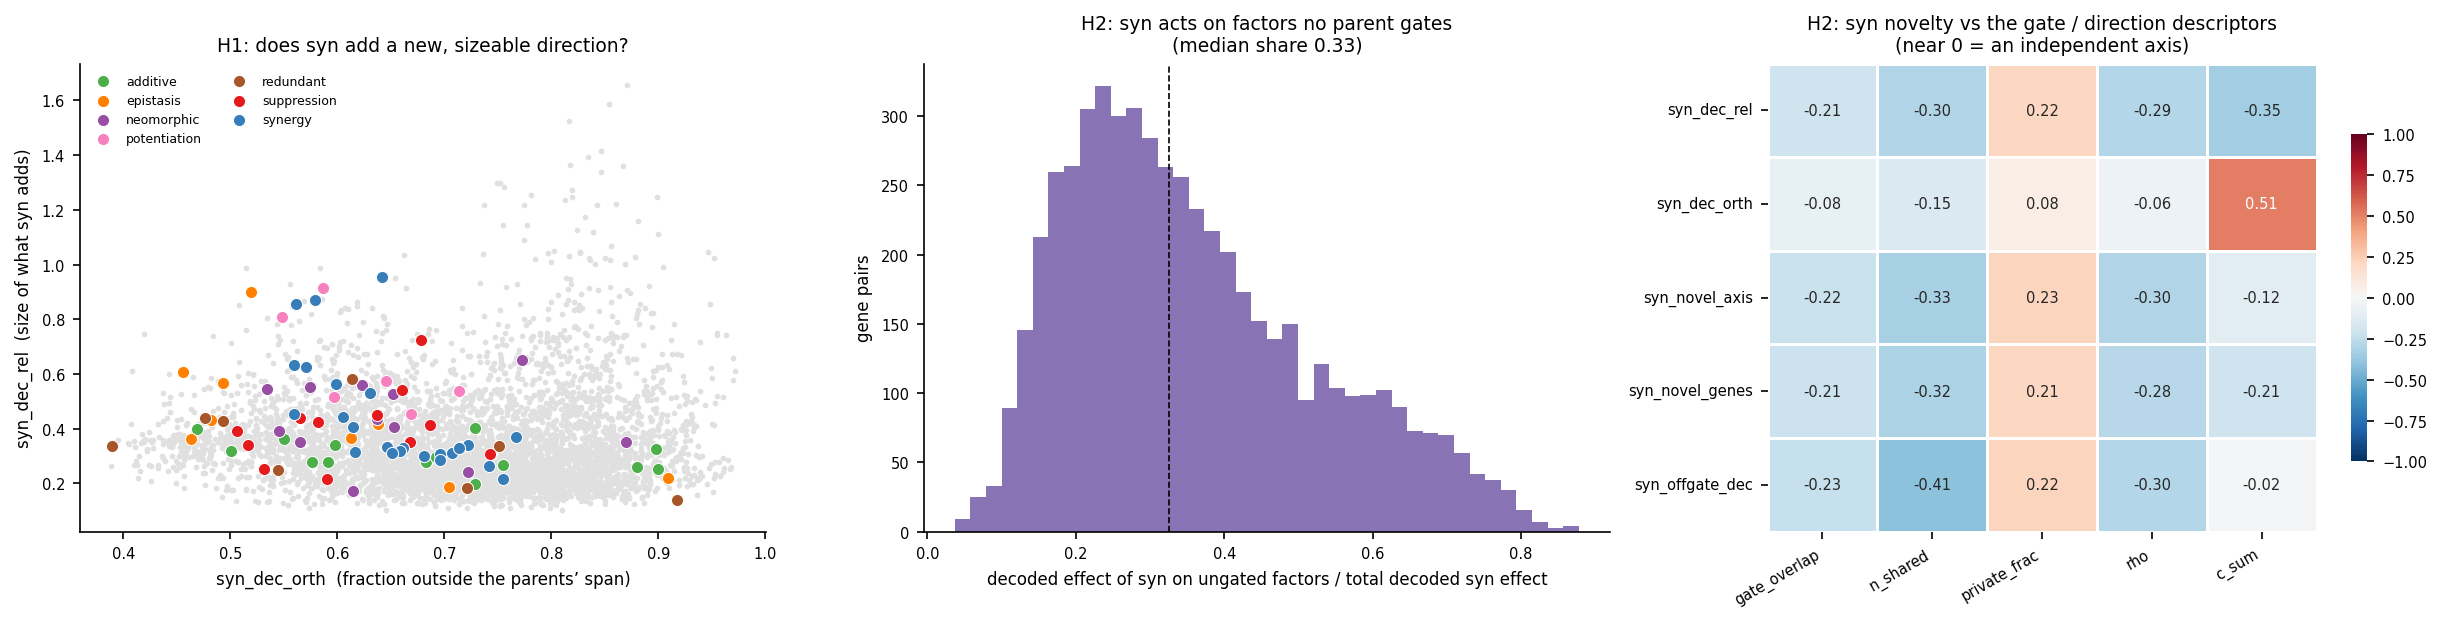

In [60]:
# H1: is the decoded synergy direction genuinely new?  H2: is it a different axis from W?
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.2))

ax = axes[0]
for c in GI_ORDER:
    sub = gt_sn[gt_sn['gi'] == c]
    ax.scatter(sub['syn_dec_orth'], sub['syn_dec_rel'], s=34, color=PALETTE_GI[c], edgecolor='white', lw=0.5,
               label=short[c], zorder=3)
ax.scatter(gp['syn_dec_orth'], gp['syn_dec_rel'], s=3, color='0.88', zorder=1, rasterized=True)
ax.set_xlabel('syn_dec_orth  (fraction outside the parents’ span)')
ax.set_ylabel('syn_dec_rel  (size of what syn adds)')
ax.set_title('H1: does syn add a new, sizeable direction?')
ax.legend(frameon=False, fontsize=6, ncol=2)

ax = axes[1]
syn_off_share = (gp['syn_offgate_dec'] / (gp['syn_dec_rel'] + 1e-8)).clip(0, 3)
ax.hist(syn_off_share, bins=40, color='#6a51a3', alpha=0.8)
ax.axvline(syn_off_share.median(), color='k', ls='--', lw=0.8)
ax.set_xlabel('decoded effect of syn on ungated factors / total decoded syn effect')
ax.set_ylabel('gene pairs')
ax.set_title(f'H2: syn acts on factors no parent gates\n(median share {syn_off_share.median():.2f})')

ax = axes[2]
w_desc = ['gate_overlap', 'n_shared', 'private_frac', 'rho', 'c_sum']
corr_h2 = gp[SYN_NEO + w_desc].corr(method='spearman').loc[SYN_NEO, w_desc]
sns.heatmap(corr_h2, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'fontsize': 7},
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('H2: syn novelty vs the gate / direction descriptors\n(near 0 = an independent axis)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

In [61]:
# Which synergy metric improves the rule set, and does the neomorphic rule use it in the expected direction?
ALL_MIN3 = list(dict.fromkeys(ALL_MIN + ['dom_gap', 'c_ratio'] + SYN_NEO))
gt_min = pairs_df[['combination', 'gi']].merge(gp[['combination'] + ALL_MIN3], on='combination')
y_min = gt_min['gi'].values
CORE6 = ['rho', 'private_frac', 'c_sum', 'syn_rel', 'joint_over_add', 'dom_gap']
base_acc, base_bal, base_pred, *_ = mine_cascade(CORE6)
rows_s = [{'added metric': '(none)', 'accuracy': base_acc, 'balanced accuracy': base_bal,
           'neomorphic rule term': '', 'neomorphic precision': np.nan,
           'neomorphic recall': float((base_pred[y_min == 'neomorphic'] == 'neomorphic').mean())}]
store_s = {}
for k in SYN_NEO:
    a_, b_, p_, r_, o_ = mine_cascade(CORE6 + [k])
    terms = [f'{f} {op} q{q:.2f}' for f, op, q, _ in r_['neomorphic']['terms'] if f == k]
    rows_s.append({'added metric': k, 'accuracy': a_, 'balanced accuracy': b_,
                   'neomorphic rule term': '; '.join(terms),
                   'neomorphic precision': r_['neomorphic']['precision'],
                   'neomorphic recall': float((p_[y_min == 'neomorphic'] == 'neomorphic').mean())})
    store_s[k] = (a_, b_, p_, r_, o_)
sdf = pd.DataFrame(rows_s)
print(sdf.round(3).to_string(index=False))

# Choose: the neomorphic rule must use the metric with a '>' (more novelty), then highest accuracy
good = sdf[sdf['neomorphic rule term'].str.contains('>', regex=False)]
choice = (good if len(good) else sdf.iloc[1:]).sort_values(['accuracy', 'neomorphic recall'], ascending=False).iloc[0]
k = choice['added metric']
a_, b_, p_, r_, o_ = store_s[k]
FINAL7 = CORE6 + [k]
print(f'\nChosen neomorphism metric: {k}')
print(f'Final set ({len(FINAL7)}): {FINAL7}')
print(f'Rule cascade: accuracy {a_:.3f}, balanced {b_:.3f}')
print('per-class recall:', {short[c]: round(float((p_[y_min == c] == c).mean()), 2) for c in GI_ORDER})
for c in o_:
    r = r_[c]
    body = '  AND  '.join(f'{f} {op} {thr:.3g} (q{q:.2f})' for f, op, q, thr in r['terms'])
    print(f"  {short[c]:12s}: {body}   [precision {r['precision']:.2f}, covers {r['support']}]")

   added metric  accuracy  balanced accuracy neomorphic rule term  neomorphic precision  neomorphic recall
         (none)     0.709              0.728                                        NaN              0.333
    syn_dec_rel     0.709              0.728                                        0.5              0.333
   syn_dec_orth     0.709              0.728                                        0.5              0.333
 syn_novel_axis     0.709              0.728                                        0.5              0.333
syn_novel_genes     0.674              0.699                                        0.5              0.333
syn_offgate_dec     0.709              0.728                                        0.5              0.333

Chosen neomorphism metric: syn_dec_rel
Final set (7): ['rho', 'private_frac', 'c_sum', 'syn_rel', 'joint_over_add', 'dom_gap', 'syn_dec_rel']
Rule cascade: accuracy 0.709, balanced 0.728
per-class recall: {'additive': 0.73, 'epistasis': 0.78, 'neomor

### 11j. A decision list: each rule mined on what is still unclaimed

The cascade above mined every class's rule over *all* pairs, so a novelty cut for neomorphic is always
swamped by potentiation — which scores highest on every synergy-novelty metric — even though the
potentiation rule has already claimed those pairs. A **decision list** fixes this: at each step, the
best rule is searched only among pairs no earlier rule has claimed, the most precise rule is kept, its
pairs are removed, and the search repeats. This is how the rules are actually applied, so it is the
right way to mine them.

                           descriptor set  accuracy  balanced accuracy  neomorphic recall neomorphic rule uses
                                   core 6     0.767              0.781              0.417                     
                     core 6 + syn_dec_rel     0.767              0.781              0.417                     
                    core 6 + syn_dec_orth     0.767              0.781              0.417                     
                  core 6 + syn_novel_axis     0.767              0.781              0.417                     
                 core 6 + syn_offgate_dec     0.767              0.781              0.417                     
core 6 + syn_novel_axis + syn_offgate_dec     0.767              0.781              0.417                     
                 core 6 + syn_novel_genes     0.767              0.779              0.333                     

Chosen: core 6  ->  accuracy 0.767, balanced 0.781
per-class recall: {'additive': 0.73, 'epistasis': 0.78, 'neo

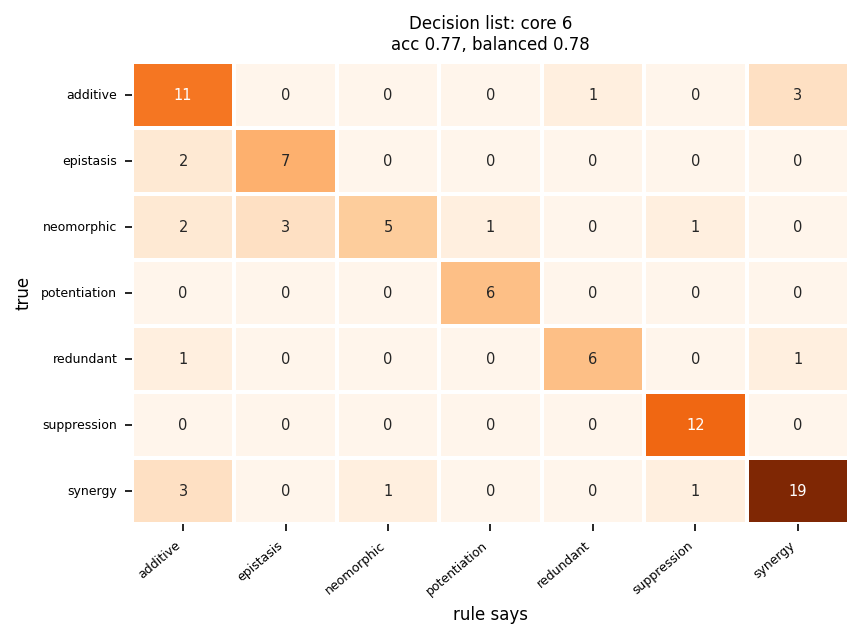

In [62]:
def _atoms_for(pool, qs=np.arange(0.15, 0.90, 0.05)):
    X = gt_min[pool].values
    A_, T_ = [], []
    for fi, f in enumerate(pool):
        for q in qs:
            thr = gp[f].quantile(q)
            A_.append(X[:, fi] > thr); T_.append((f, '>', q, thr))
            A_.append(X[:, fi] <= thr); T_.append((f, '<=', q, thr))
    return np.array(A_), T_

def mine_decision_list(pool, min_support=3, fallback='approximately additive'):
    A_, T_ = _atoms_for(pool)
    n = len(y_min)
    remaining = np.ones(n, bool)
    pred = np.array([fallback] * n, dtype=object)
    left = list(GI_ORDER)
    dlist = []
    while left:
        cands = []
        Ar = A_[:, remaining]
        for cls in left:
            y = (y_min[remaining] == cls).astype(float)
            npos = y.sum()
            if npos == 0:
                continue
            best = (0.0, 0, 0)
            for i in range(len(Ar)):
                if Ar[i].sum() < min_support:
                    continue
                both = Ar[i:] & Ar[i]
                tp = both @ y; sup = both.sum(1)
                f1 = np.where(sup >= min_support, 2 * tp / np.maximum(sup + npos, 1e-9), 0)
                j = int(np.argmax(f1))
                if f1[j] > best[0]:
                    best = (float(f1[j]), i, i + j)
            f1, i, j = best
            if f1 == 0:
                continue
            m = A_[i] & A_[j] & remaining
            prec = float((y_min[m] == cls).mean())
            cands.append((prec, f1, cls, i, j, m))
        if not cands:
            break
        prec, f1, cls, i, j, m = max(cands, key=lambda t: (t[0], t[1]))
        pred[m] = cls
        remaining &= ~m
        left.remove(cls)
        terms = (T_[i], T_[j]) if i != j else (T_[i],)
        dlist.append({'class': cls, 'terms': terms, 'precision': prec, 'covers': int(m.sum())})
    return float(np.mean(pred == y_min)), float(balanced_accuracy_score(y_min, pred)), pred, dlist

def _print_dlist(dlist):
    for r in dlist:
        body = '  AND  '.join(f'{f} {op} {thr:.3g} (q{q:.2f})' for f, op, q, thr in r['terms'])
        print(f"  {short[r['class']]:12s}: {body}   [precision {r['precision']:.2f}, claims {r['covers']}]")

rows_dl, store_dl = [], {}
variants_dl = {'core 6': CORE6}
variants_dl.update({f'core 6 + {k}': CORE6 + [k] for k in SYN_NEO})
variants_dl['core 6 + syn_novel_axis + syn_offgate_dec'] = CORE6 + ['syn_novel_axis', 'syn_offgate_dec']
for nm, pool_ in variants_dl.items():
    a_, b_, p_, dl_ = mine_decision_list(pool_)
    neo_rule = [r for r in dl_ if r['class'] == 'neomorphic']
    syn_terms = [f'{f} {op}' for r in neo_rule for f, op, _, _ in r['terms'] if f in SYN_NEO]
    rows_dl.append({'descriptor set': nm, 'accuracy': a_, 'balanced accuracy': b_,
                    'neomorphic recall': float((p_[y_min == 'neomorphic'] == 'neomorphic').mean()),
                    'neomorphic rule uses': ', '.join(syn_terms)})
    store_dl[nm] = (a_, b_, p_, dl_)
dldf = pd.DataFrame(rows_dl).sort_values(['accuracy', 'neomorphic recall'], ascending=False)
print(dldf.round(3).to_string(index=False))

# Prefer the best set whose neomorphic rule uses a synergy-novelty term with '>' (more novelty)
uses_up = dldf[dldf['neomorphic rule uses'].str.contains('>', regex=False)]
pick_nm = (uses_up if len(uses_up) else dldf).iloc[0]['descriptor set']
a_, b_, p_, dl_ = store_dl[pick_nm]
FINAL_DL = variants_dl[pick_nm]
print(f'\nChosen: {pick_nm}  ->  accuracy {a_:.3f}, balanced {b_:.3f}')
print('per-class recall:', {short[c]: round(float((p_[y_min == c] == c).mean()), 2) for c in GI_ORDER})
print('Decision list (applied top to bottom; unclaimed pairs -> additive):')
_print_dlist(dl_)

fig, ax = plt.subplots(figsize=(5.8, 4.3))
cm = confusion_matrix(y_min, p_, labels=GI_ORDER)
sns.heatmap(cm, cmap='Oranges', annot=True, fmt='d', annot_kws={'fontsize': 7}, linewidths=1, linecolor='white',
            xticklabels=[short[c] for c in GI_ORDER], yticklabels=[short[c] for c in GI_ORDER], cbar=False, ax=ax)
ax.set_xlabel('rule says'); ax.set_ylabel('true')
ax.set_title(f'Decision list: {pick_nm}\nacc {a_:.2f}, balanced {b_:.2f}', fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

### 11k. Forcing the neomorphic rule to be a statement about syn

The decision list reaches the same neomorphic performance with or without the synergy metrics — once
the other classes are claimed, `c_sum`/`dom_gap` separates the leftovers as well as a synergy term
does, and ties go to whichever descriptor is listed first. To test the hypothesis directly, the
neomorphic rule is now **required to contain one synergy-novelty condition** (the other condition is
free). If accuracy holds, the synergy reading costs nothing and is the one to report.

In [63]:
def mine_decision_list_req(pool, require, min_support=3, fallback='approximately additive'):
    # like mine_decision_list, but classes in `require` must use >= 1 atom from the listed features
    A_, T_ = _atoms_for(pool)
    req_idx = {cls: np.array([k for k, t in enumerate(T_) if t[0] in feats]) for cls, feats in require.items()}
    n = len(y_min)
    remaining = np.ones(n, bool)
    pred = np.array([fallback] * n, dtype=object)
    left = list(GI_ORDER)
    dlist = []
    while left:
        cands = []
        Ar = A_[:, remaining]
        for cls in left:
            y = (y_min[remaining] == cls).astype(float); npos = y.sum()
            if npos == 0:
                continue
            first = req_idx.get(cls, np.arange(len(Ar)))
            best = (0.0, 0, 0)
            for i in first:
                if Ar[i].sum() < min_support:
                    continue
                both = Ar & Ar[i]
                tp = both @ y; sup = both.sum(1)
                f1 = np.where(sup >= min_support, 2 * tp / np.maximum(sup + npos, 1e-9), 0)
                j = int(np.argmax(f1))
                if f1[j] > best[0]:
                    best = (float(f1[j]), int(i), j)
            f1, i, j = best
            if f1 == 0:
                continue
            m = A_[i] & A_[j] & remaining
            cands.append((float((y_min[m] == cls).mean()), f1, cls, i, j, m))
        if not cands:
            break
        prec, f1, cls, i, j, m = max(cands, key=lambda t: (t[0], t[1]))
        pred[m] = cls; remaining &= ~m; left.remove(cls)
        dlist.append({'class': cls, 'terms': (T_[i], T_[j]) if i != j else (T_[i],),
                      'precision': prec, 'covers': int(m.sum())})
    return float(np.mean(pred == y_min)), float(balanced_accuracy_score(y_min, pred)), pred, dlist

rows_k, store_k = [], {}
base_a, base_b, base_p, _ = store_dl['core 6']
rows_k.append({'neomorphic rule must use': '(nothing required)', 'accuracy': base_a, 'balanced accuracy': base_b,
               'neomorphic precision': float((y_min[base_p == 'neomorphic'] == 'neomorphic').mean()),
               'neomorphic recall': float((base_p[y_min == 'neomorphic'] == 'neomorphic').mean()),
               'syn condition': ''})
for k in SYN_NEO:
    a_, b_, p_, dl_ = mine_decision_list_req(CORE6 + [k], {'neomorphic': [k]})
    neo = [r for r in dl_ if r['class'] == 'neomorphic']
    cond = '; '.join(f'{f} {op} q{q:.2f}' for r in neo for f, op, q, _ in r['terms'] if f == k)
    rows_k.append({'neomorphic rule must use': k, 'accuracy': a_, 'balanced accuracy': b_,
                   'neomorphic precision': float((y_min[p_ == 'neomorphic'] == 'neomorphic').mean()) if (p_ == 'neomorphic').any() else np.nan,
                   'neomorphic recall': float((p_[y_min == 'neomorphic'] == 'neomorphic').mean()),
                   'syn condition': cond})
    store_k[k] = (a_, b_, p_, dl_)
kdf = pd.DataFrame(rows_k)
print(kdf.round(3).to_string(index=False))

# Only conditions in the hypothesised direction ('>' = more synergy novelty) are eligible; ties on
# accuracy and recall are broken by neomorphic precision.
cand_k = kdf[kdf['syn condition'].str.contains('>', regex=False)].sort_values(
    ['accuracy', 'neomorphic recall', 'neomorphic precision'], ascending=False)
if len(cand_k):
    kk = cand_k.iloc[0]['neomorphic rule must use']
    a_, b_, p_, dl_ = store_k[kk]
    FINAL_NEO = CORE6 + [kk]
    print(f'\nFinal descriptor set ({len(FINAL_NEO)}): {FINAL_NEO}')
    print(f'Decision list: accuracy {a_:.3f}, balanced {b_:.3f}')
    print('per-class recall:', {short[c]: round(float((p_[y_min == c] == c).mean()), 2) for c in GI_ORDER})
    _print_dlist(dl_)
else:
    print('\nNo synergy metric enters the neomorphic rule with a ">" (more novelty) condition.')

neomorphic rule must use  accuracy  balanced accuracy  neomorphic precision  neomorphic recall            syn condition
      (nothing required)     0.767              0.781                 0.833              0.417                         
             syn_dec_rel     0.756              0.769                 0.714              0.417      syn_dec_rel > q0.60
            syn_dec_orth     0.767              0.781                 0.600              0.500    syn_dec_orth <= q0.70
          syn_novel_axis     0.767              0.781                 0.600              0.500   syn_novel_axis > q0.15
         syn_novel_genes     0.767              0.779                 0.800              0.333 syn_novel_genes <= q0.80
         syn_offgate_dec     0.767              0.781                 0.750              0.500  syn_offgate_dec > q0.30

Final descriptor set (7): ['rho', 'private_frac', 'c_sum', 'syn_rel', 'joint_over_add', 'dom_gap', 'syn_offgate_dec']
Decision list: accuracy 0.767, balanced 0

### 11l. Parameter card for the final set

For each of the final seven descriptors: its mean in every interaction class, and how well it ranks each
class against the rest (AUROC; > 0.5 means the class sits *higher* on that descriptor).

Class means (all 5460 gene pairs in the last row):
                          rho  private_frac  c_sum  syn_rel  joint_over_add  dom_gap  syn_offgate_dec
gi                                                                                                   
approximately additive  0.546         0.143  1.642    0.206           1.097    0.068            0.093
epistasis              -0.001         0.240  1.346    0.356           0.974    0.930            0.141
neomorphic             -0.025         0.200  1.516    0.354           1.029    0.582            0.166
potentiation            0.129         0.445  1.759    0.419           1.437    0.370            0.199
redundant               0.758         0.074  1.300    0.260           0.918    0.045            0.099
suppression            -0.126         0.205  1.292    0.399           0.915    0.323            0.136
synergy                 0.499         0.168  1.723    0.327           1.283    0.070            0.108
(all gene pairs)        0.118  

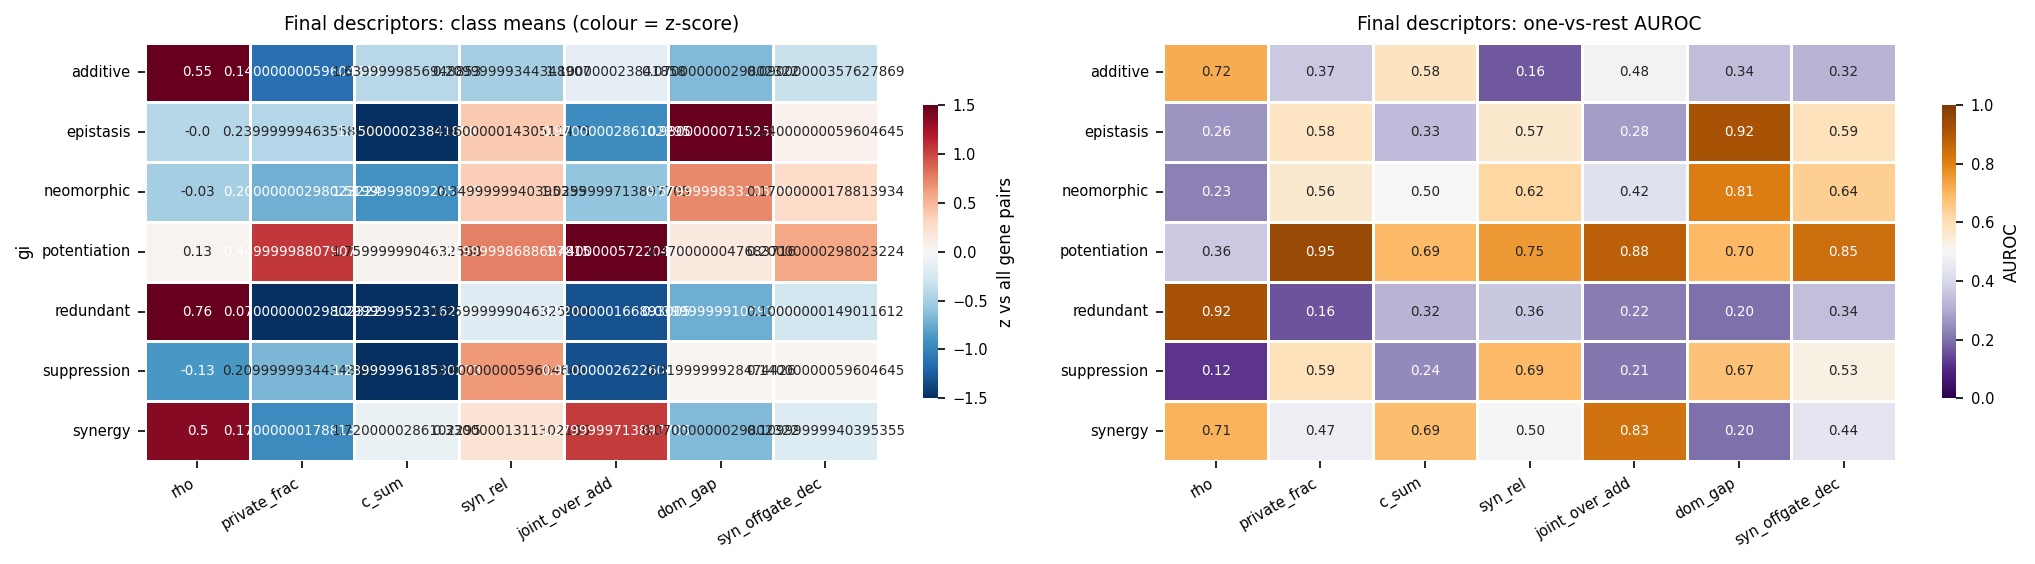

In [64]:
card_cols = FINAL_NEO
card_df = pairs_df[['combination', 'gi']].merge(gp[['combination'] + card_cols], on='combination')
card_means = card_df.groupby('gi')[card_cols].mean().reindex(GI_ORDER)
card_auc = pd.DataFrame({f: {c: mannwhitneyu(card_df.loc[card_df['gi'] == c, f],
                                             card_df.loc[card_df['gi'] != c, f]).statistic /
                                ((card_df['gi'] == c).sum() * (card_df['gi'] != c).sum())
                             for c in GI_ORDER} for f in card_cols}).reindex(GI_ORDER)
print('Class means (all 5460 gene pairs in the last row):')
cm_tab = card_means.copy()
cm_tab.loc['(all gene pairs)'] = gp[card_cols].mean()
print(cm_tab.round(3).to_string())
print('\nOne-vs-rest AUROC:')
print(card_auc.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
zc = (card_means - gp[card_cols].mean()) / gp[card_cols].std()
sns.heatmap(zc, cmap='RdBu_r', center=0, vmin=-1.5, vmax=1.5, annot=card_means.round(2), fmt='',
            annot_kws={'fontsize': 6.5}, linewidths=0.5, linecolor='white', ax=axes[0],
            yticklabels=[short[c] for c in GI_ORDER], cbar_kws={'label': 'z vs all gene pairs', 'shrink': 0.7})
axes[0].set_title('Final descriptors: class means (colour = z-score)')
sns.heatmap(card_auc, cmap='PuOr_r', center=0.5, vmin=0, vmax=1, annot=True, fmt='.2f',
            annot_kws={'fontsize': 6.5}, linewidths=0.5, linecolor='white', ax=axes[1],
            yticklabels=[short[c] for c in GI_ORDER], cbar_kws={'label': 'AUROC', 'shrink': 0.7})
axes[1].set_title('Final descriptors: one-vs-rest AUROC')
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 12. Summary

In [65]:
print(f'Consensus modules: K = {K_FINAL}; mean ARI with individual runs = '
      f"{sel_df.set_index('k').loc[K_FINAL, 'ARI_vs_runs']:.3f} "
      f"(run–run ARI at same k = {ari_scan.set_index('k').loc[K_FINAL, 'pairwise_ARI']:.3f})")
print(f"Same-module rate: GT pairs {pairs_df['same_module'].mean():.2f} vs all gene pairs {bg['same_module']:.2f}")
print(f"Module-pair × class association: free p = {assoc['p_free']:.4f}, "
      f"stratified p = {assoc['p_stratified']:.4f}, random gene modules p = {assoc['p_gene_shuffle']:.4f}")
print(f'\nLabel-free regimes ({N_REGIMES}) vs GT class (counts):')
print(ct.to_string())
print('\nPer-class summary:')
print(tests_wide.join(cmp_df).join(tab[['n', 'rho_mean', 'coassign_mean']]).round(3).to_string())

Consensus modules: K = 12; mean ARI with individual runs = 0.387 (run–run ARI at same k = 0.193)
Same-module rate: GT pairs 0.27 vs all gene pairs 0.10
Module-pair × class association: free p = 0.0002, stratified p = 0.0002, random gene modules p = 0.0020

Label-free regimes (5) vs GT class (counts):
regime                  R1  R2  R3  R4  R5
gi                                        
approximately additive   0   8   2   1   4
epistasis                0   0   2   2   5
neomorphic               2   3   1   2   4
potentiation             2   2   0   1   1
redundant                0   6   1   1   0
suppression              0   5   1   6   0
synergy                  0  21   3   0   0

Per-class summary:
                        AUROC_coassign  AUROC_rho  q_coassign  q_rho  frac_same  OR_same_module  q_same_module  AUROC observed corr  AUROC model rho  AUROC rho residual     n  rho_mean  coassign_mean
gi                                                                                         